In [1]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 600}")

# 1.8 $G_0$, 15 GHz stripline

## Unirradiated experimental trace

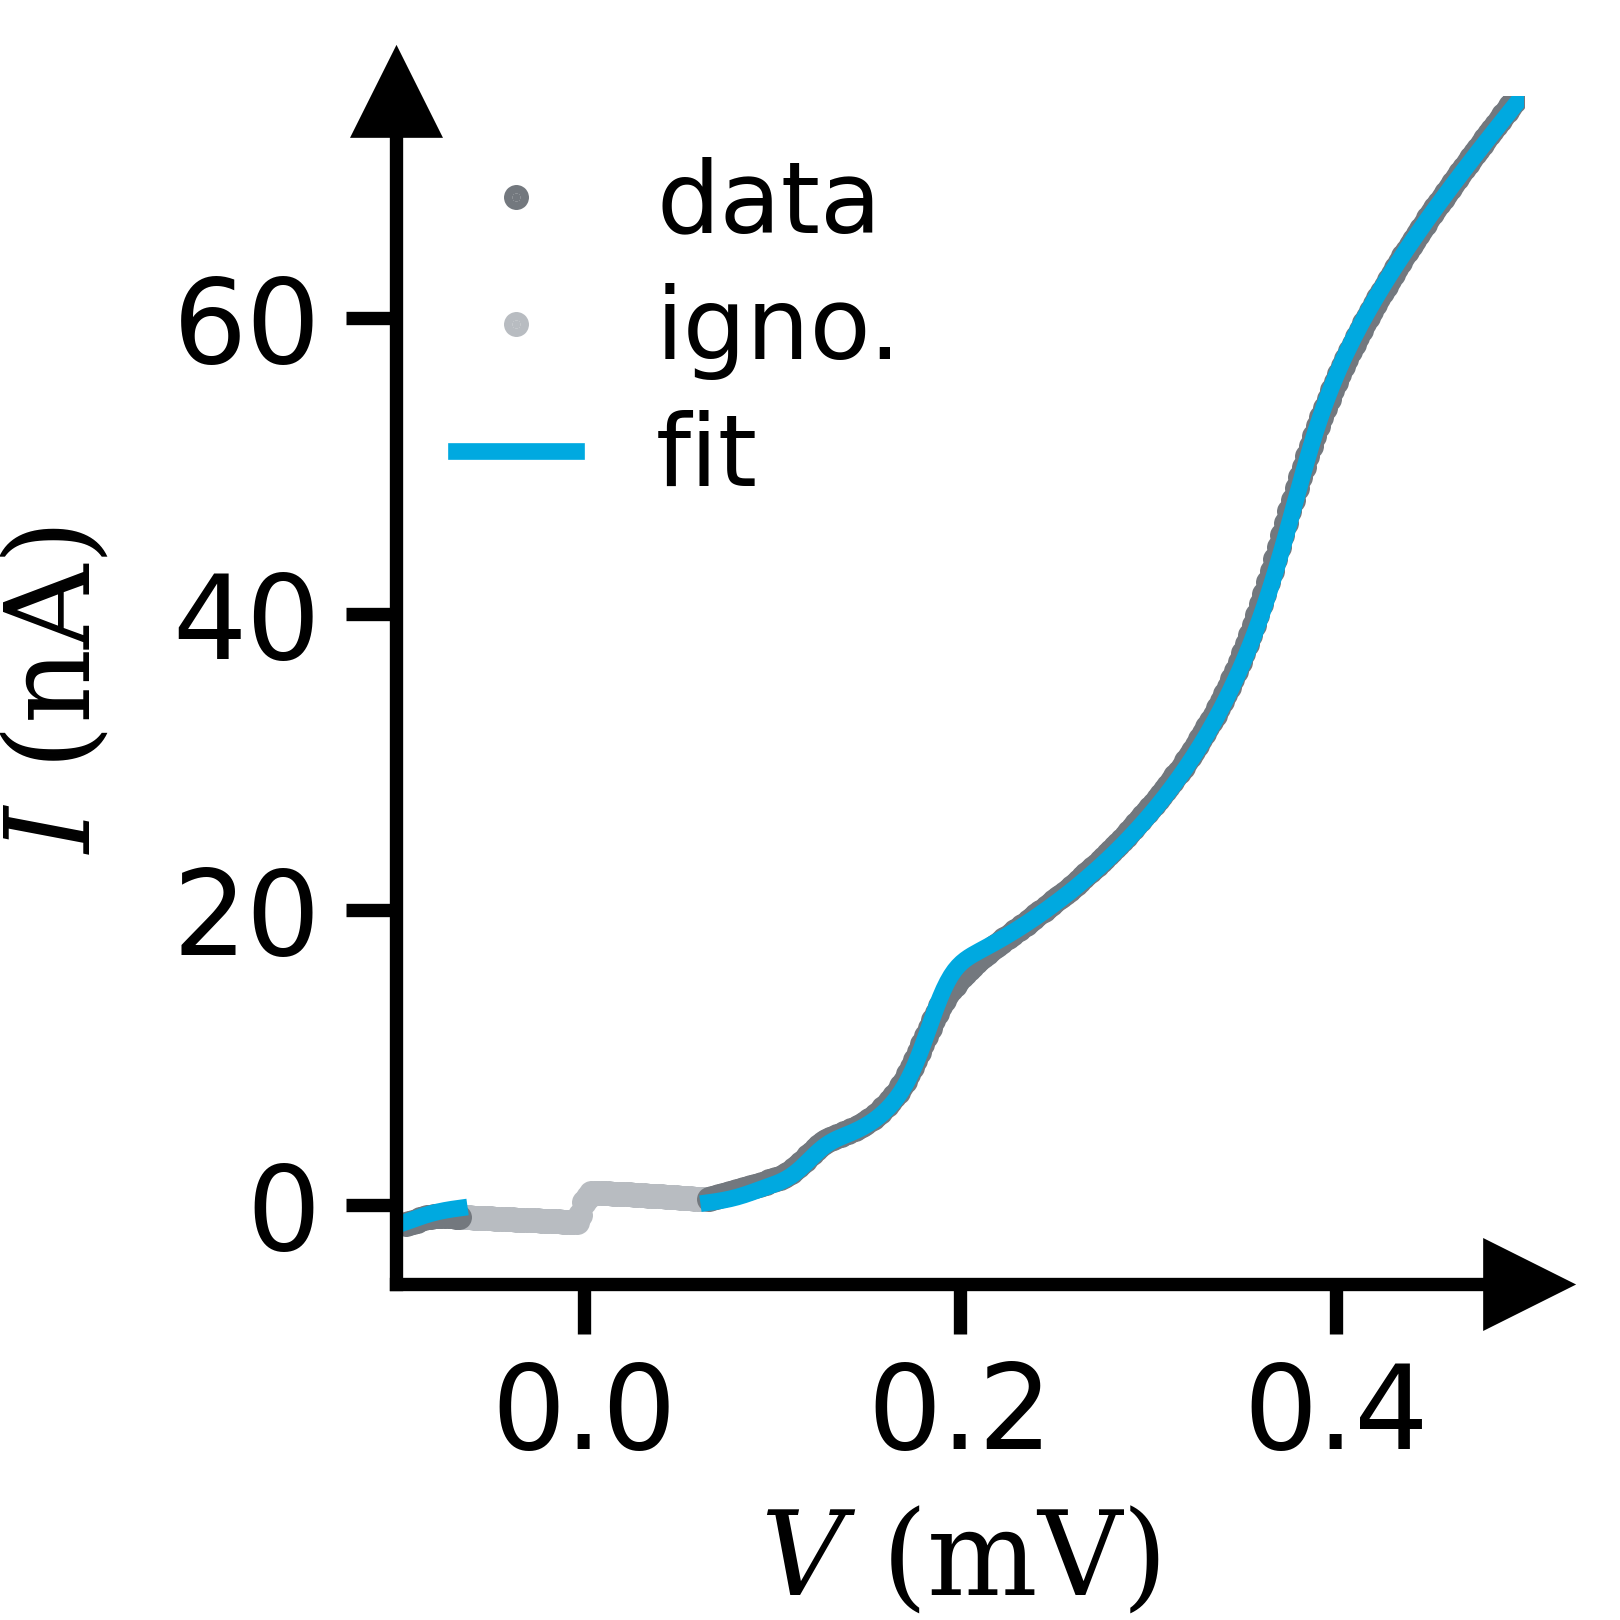

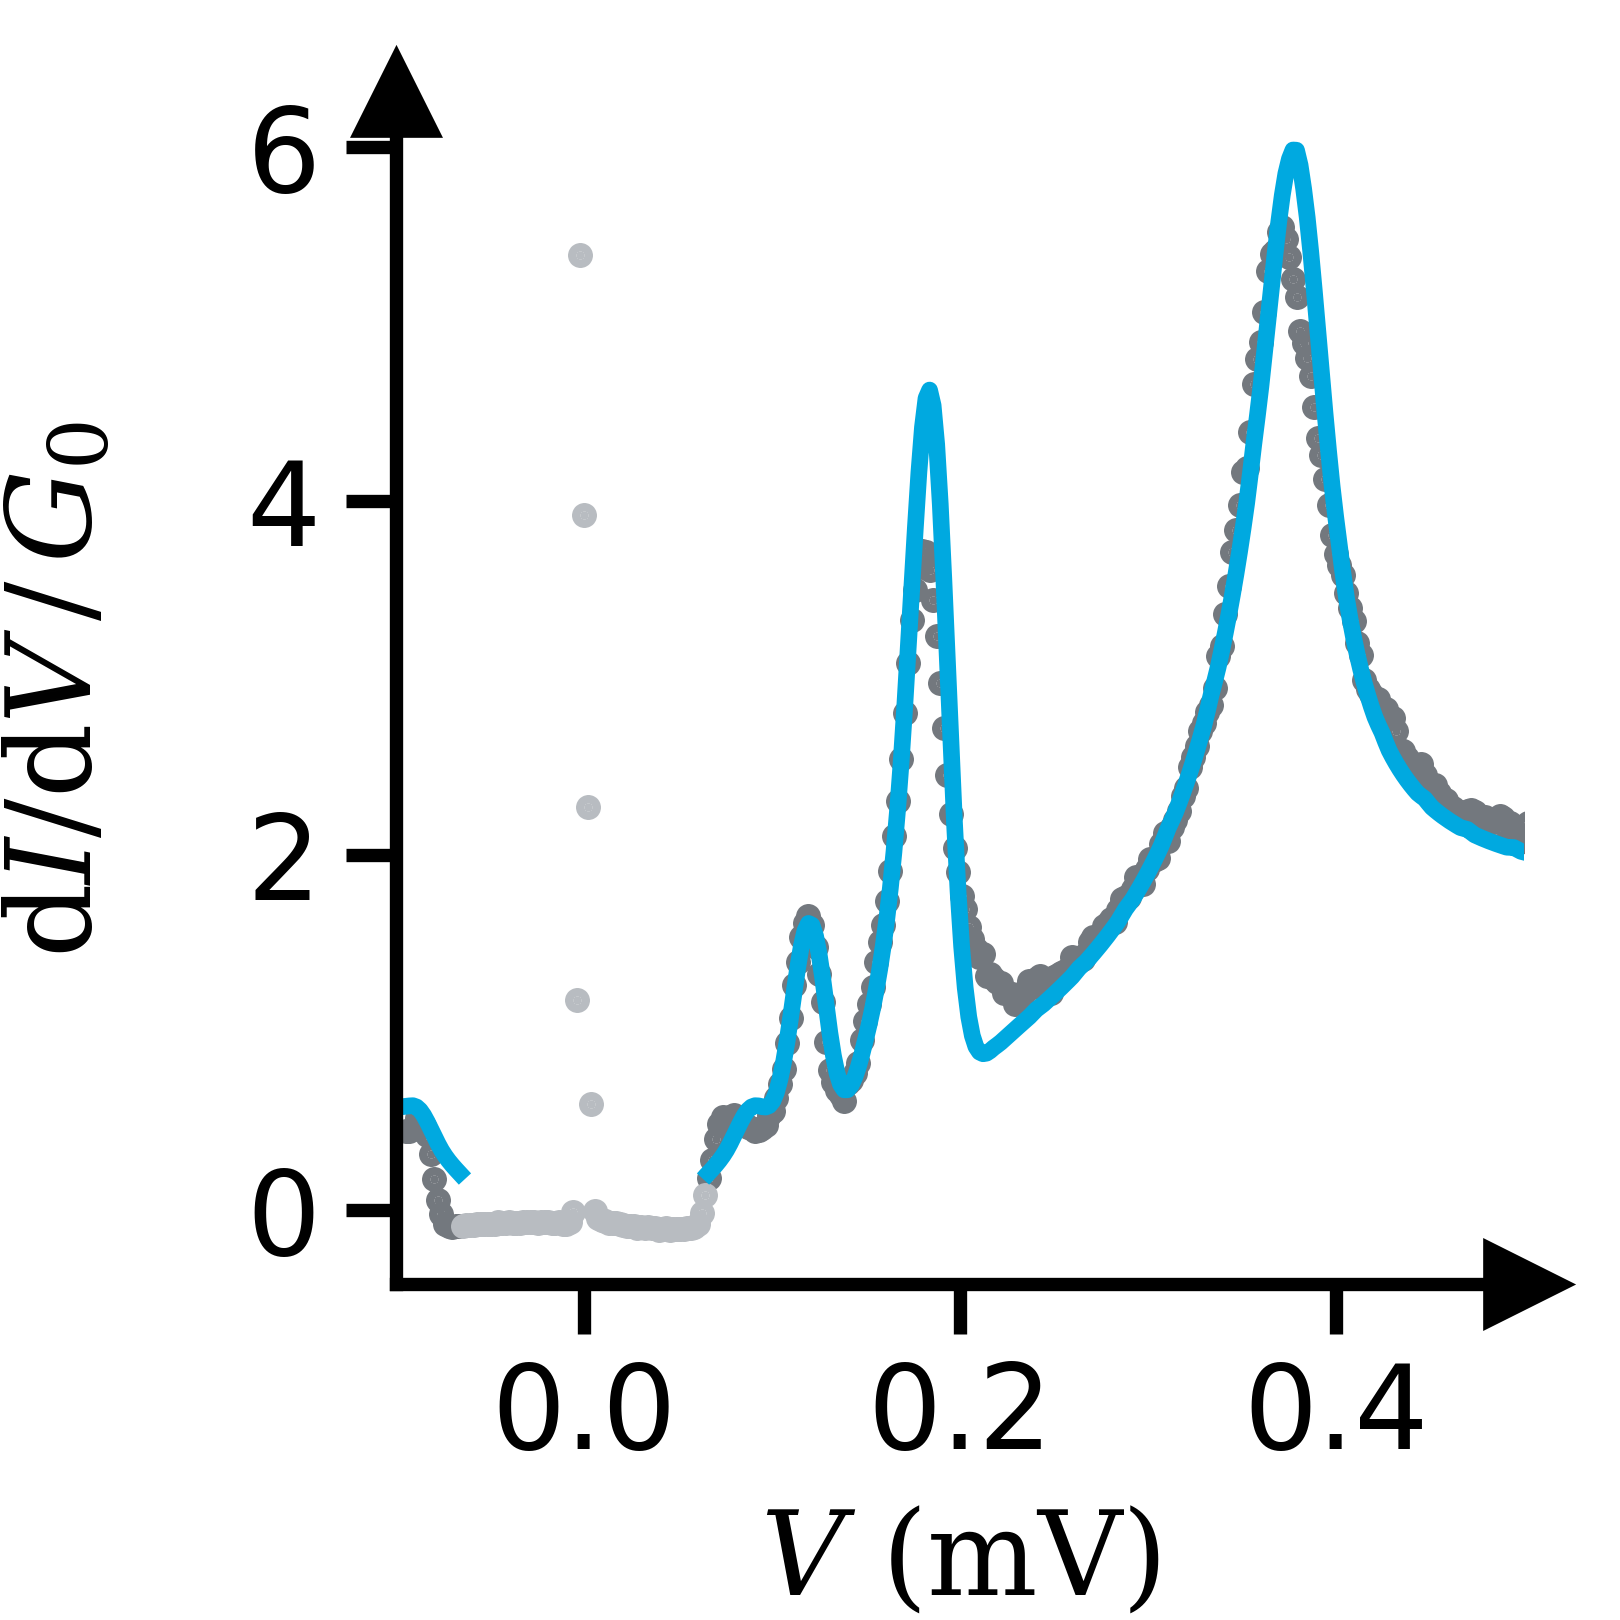

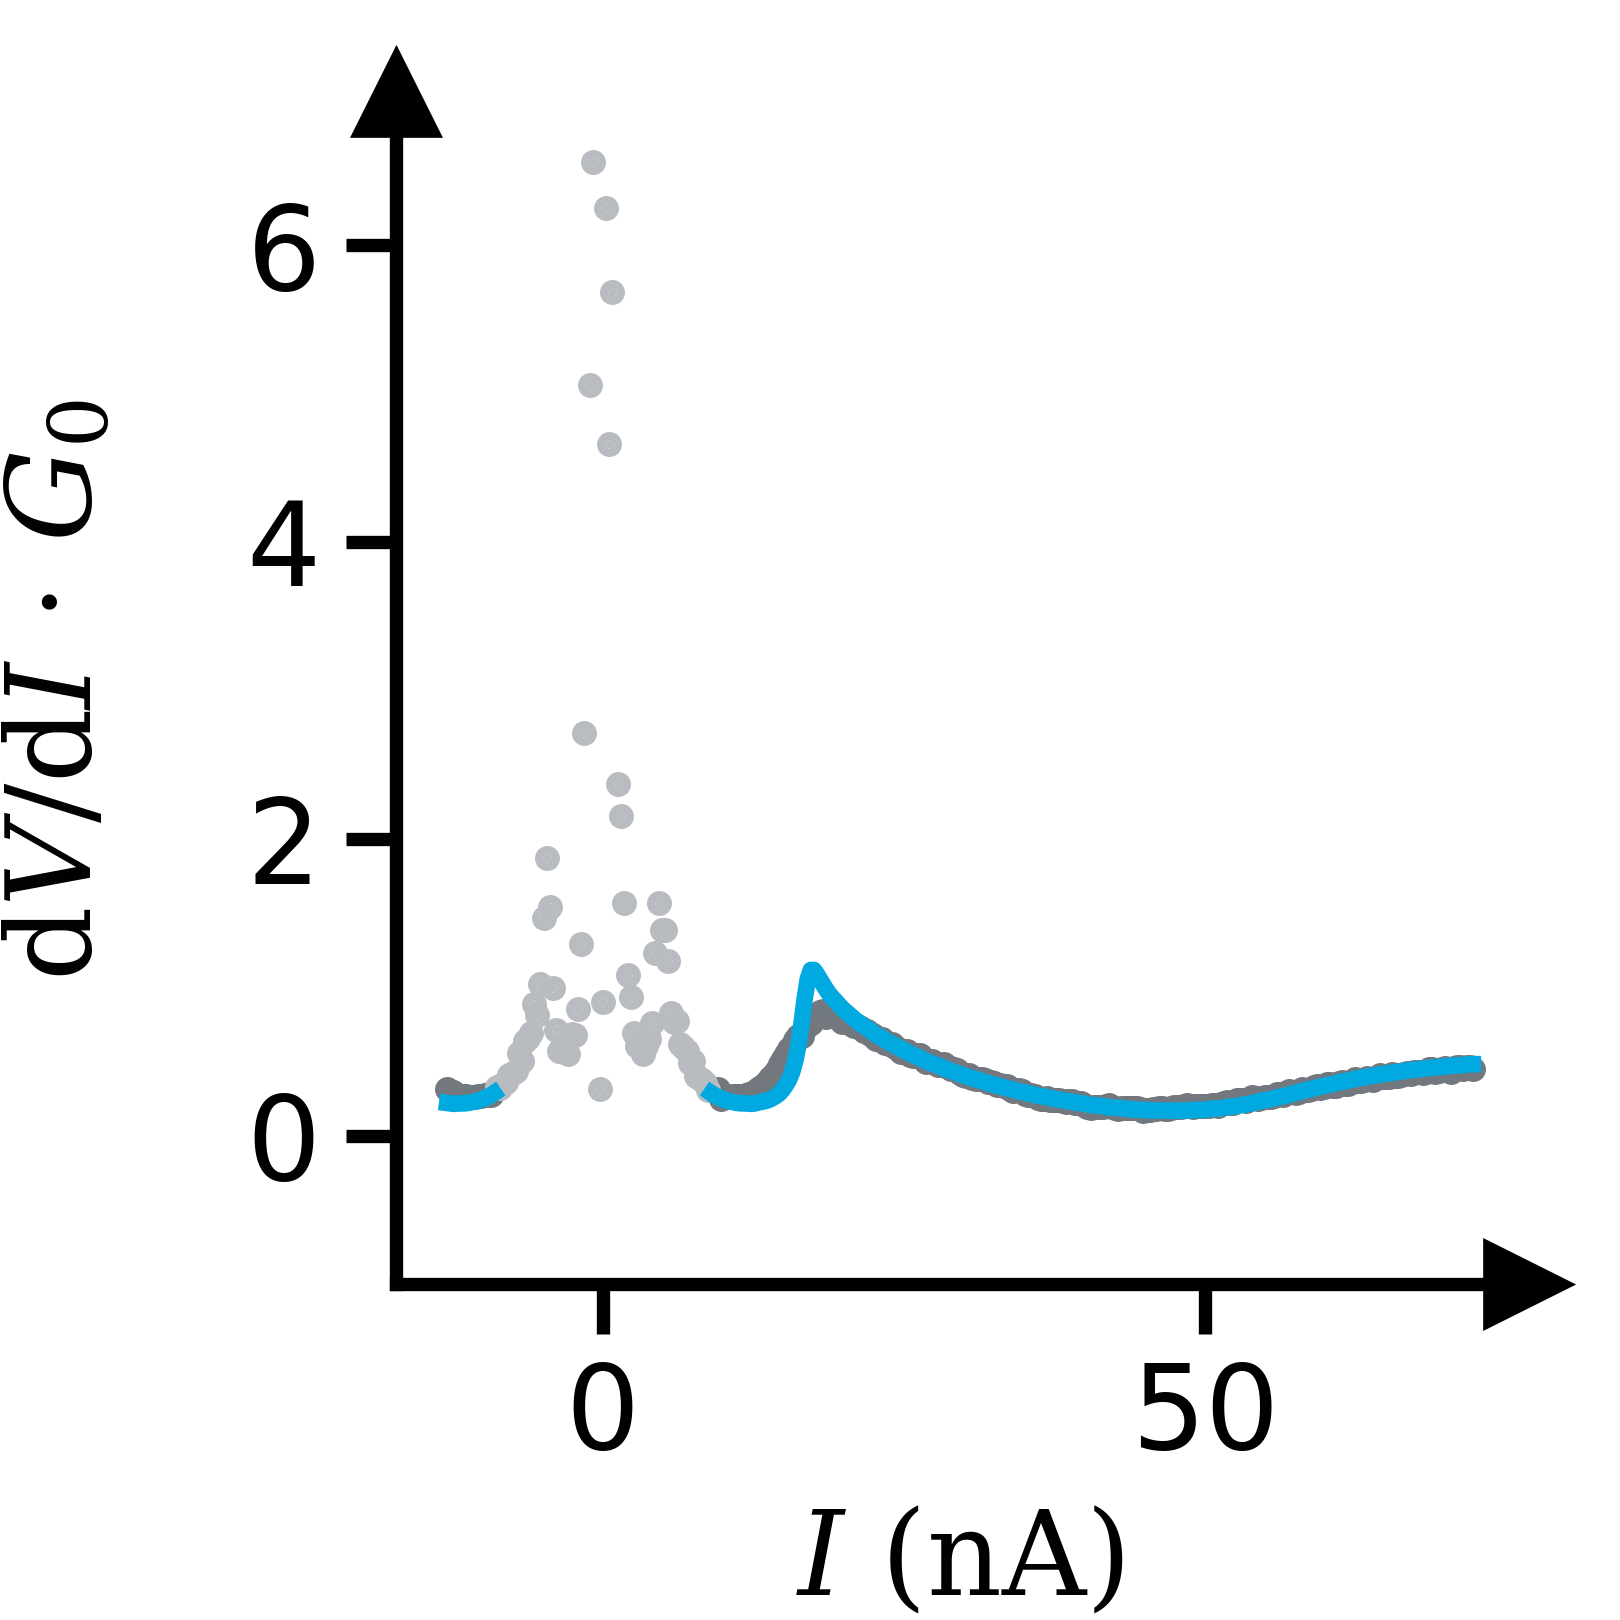

In [107]:
# fit mar
from superconductivity.utilities.functions.upsampling import upsample

path = "1.8G0/15.0GHz_stripline"
# data_exp = np.load(f"{path}/eva.npz")

# Vbias_mV = data_exp["Vbias_mV"]
# Ibias_nA = data_exp["Ibias_nA"]
# Iexp_nA = data_exp["Iexp_nA"][0, :]
# dGexp_G0 = data_exp["dGexp_G0"][0, :]
# dRexp_R0 = data_exp["dRexp_R0"][0, :]

# data_mar = np.load(f"{path}/mar_data.npz")
# Vbiasmar_mV = data_mar["V_mV"]
# Imar_nA = data_mar["Ifit_nA"]

# data_sc = np.load(f"{path}/sc_data.npz")
# Vbiassc_mV = data_sc["Vbias_mV"]
# Isc_nA = data_sc["Ifit_nA"]


data_sim = np.load(f"{path}/sim.npz")
Delta_meV = data_sim["Delta_meV"]
GN_G0 = data_sim["GN_G0"]

Vbias_mV = data_sim["Vbias"] * Delta_meV
Ibias_nA = data_sim["Vbias"] * Delta_meV * GN_G0 * sc.G0_muS

Iexp_nA = data_sim["Iexp"][0, :] * Delta_meV * GN_G0 * sc.G0_muS
Ipamar_nA = data_sim["Ipamar"][0, :] * Delta_meV * GN_G0 * sc.G0_muS
Iicpt_nA = data_sim["Iicpt"][0, :] * Delta_meV * GN_G0 * sc.G0_muS
Isim_nA = data_sim["Isim"][0, :] * Delta_meV * GN_G0 * sc.G0_muS

dGexp_G0 = data_sim["dGexp"][0, :] * GN_G0
dGpamar_G0 = data_sim["dGpamar"][0, :] * GN_G0
dGicpt_G0 = data_sim["dGicpt"][0, :] * GN_G0
dGsim_G0 = data_sim["dGsim"][0, :] * GN_G0

dRexp_R0 = data_sim["dRexp"][0, :] / GN_G0
dRpamar_R0 = data_sim["dRpamar"][0, :] / GN_G0
dRicpt_R0 = data_sim["dRicpt"][0, :] / GN_G0
dRsim_R0 = data_sim["dRsim"][0, :] / GN_G0

Vexp_mV = data_sim["Vexp"][0, :] * Delta_meV
Vpamar_mV = data_sim["Vpamar"][0, :] * Delta_meV
Vicpt_mV = data_sim["Vicpt"][0, :] * Delta_meV
Vsim_mV = data_sim["Vsim"][0, :] * Delta_meV

Vnan_mV = (-0.065, 0.065)
mask1 = np.select(
    [
        np.logical_and(Vbias_mV >= Vnan_mV[0], Vbias_mV <= Vnan_mV[1]),
        np.abs(Vbias_mV) >= 0.54,
    ],
    [np.nan, np.nan],
    np.full_like(Vbias_mV, 1.0),
)
mask2 = np.where(np.isnan(mask1), 1, np.nan)

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV * mask1,
    Iexp_nA * mask1,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
ax.plot(
    Vbias_mV * mask2,
    Iexp_nA * mask2,
    ".",
    color=sc.seegrau35,
    label="igno.",
    zorder=-2,
)
ax.plot(
    Vbias_mV * mask1, Ipamar_nA * mask1, "-", color=sc.seeblau100, label="fit", zorder=0
)
ax.set_yticks([0, 20, 40, 60])
ax.set_ylim(None, 75)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.5)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/mar_fit/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias_mV * mask1, dGexp_G0 * mask1, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vbias_mV * mask2, dGexp_G0 * mask2, ".", color=sc.seegrau35, ms=1.0)
ax.plot(Vbias_mV * mask1, dGpamar_G0 * mask1, "-", color=sc.seeblau100)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.5)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/mar_fit/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Ibias_nA * mask1, dRexp_R0 * mask1, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Ibias_nA * mask2, dRexp_R0 * mask2, ".", color=sc.seegrau35, ms=1.0)
ax.plot(Ibias_nA * mask1, dRpamar_R0 * mask1, "-", color=sc.seeblau100)
ax.set_ylim(-1, 7)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/mar_fit/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()

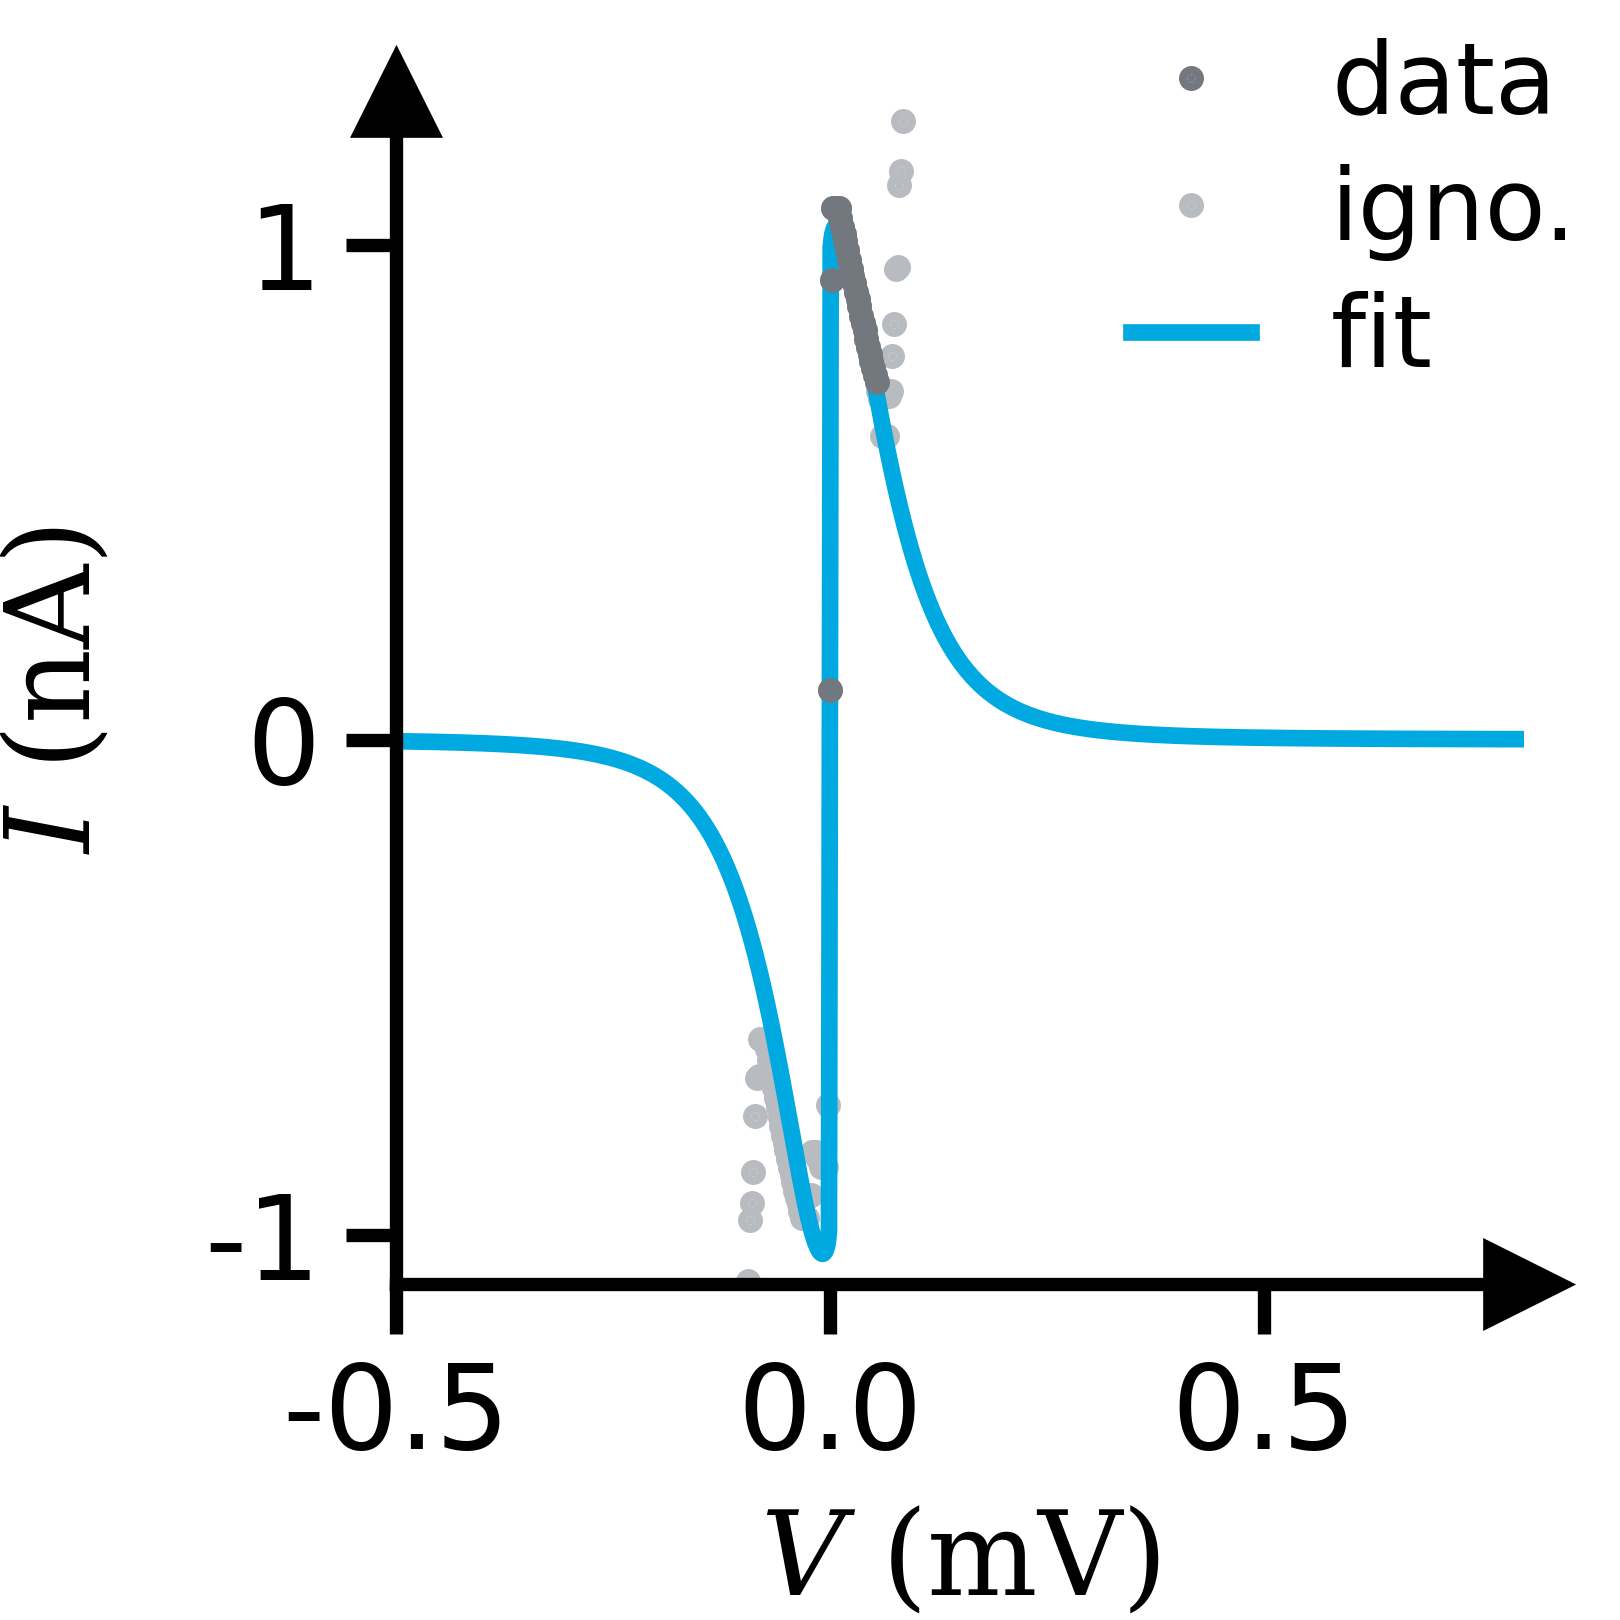

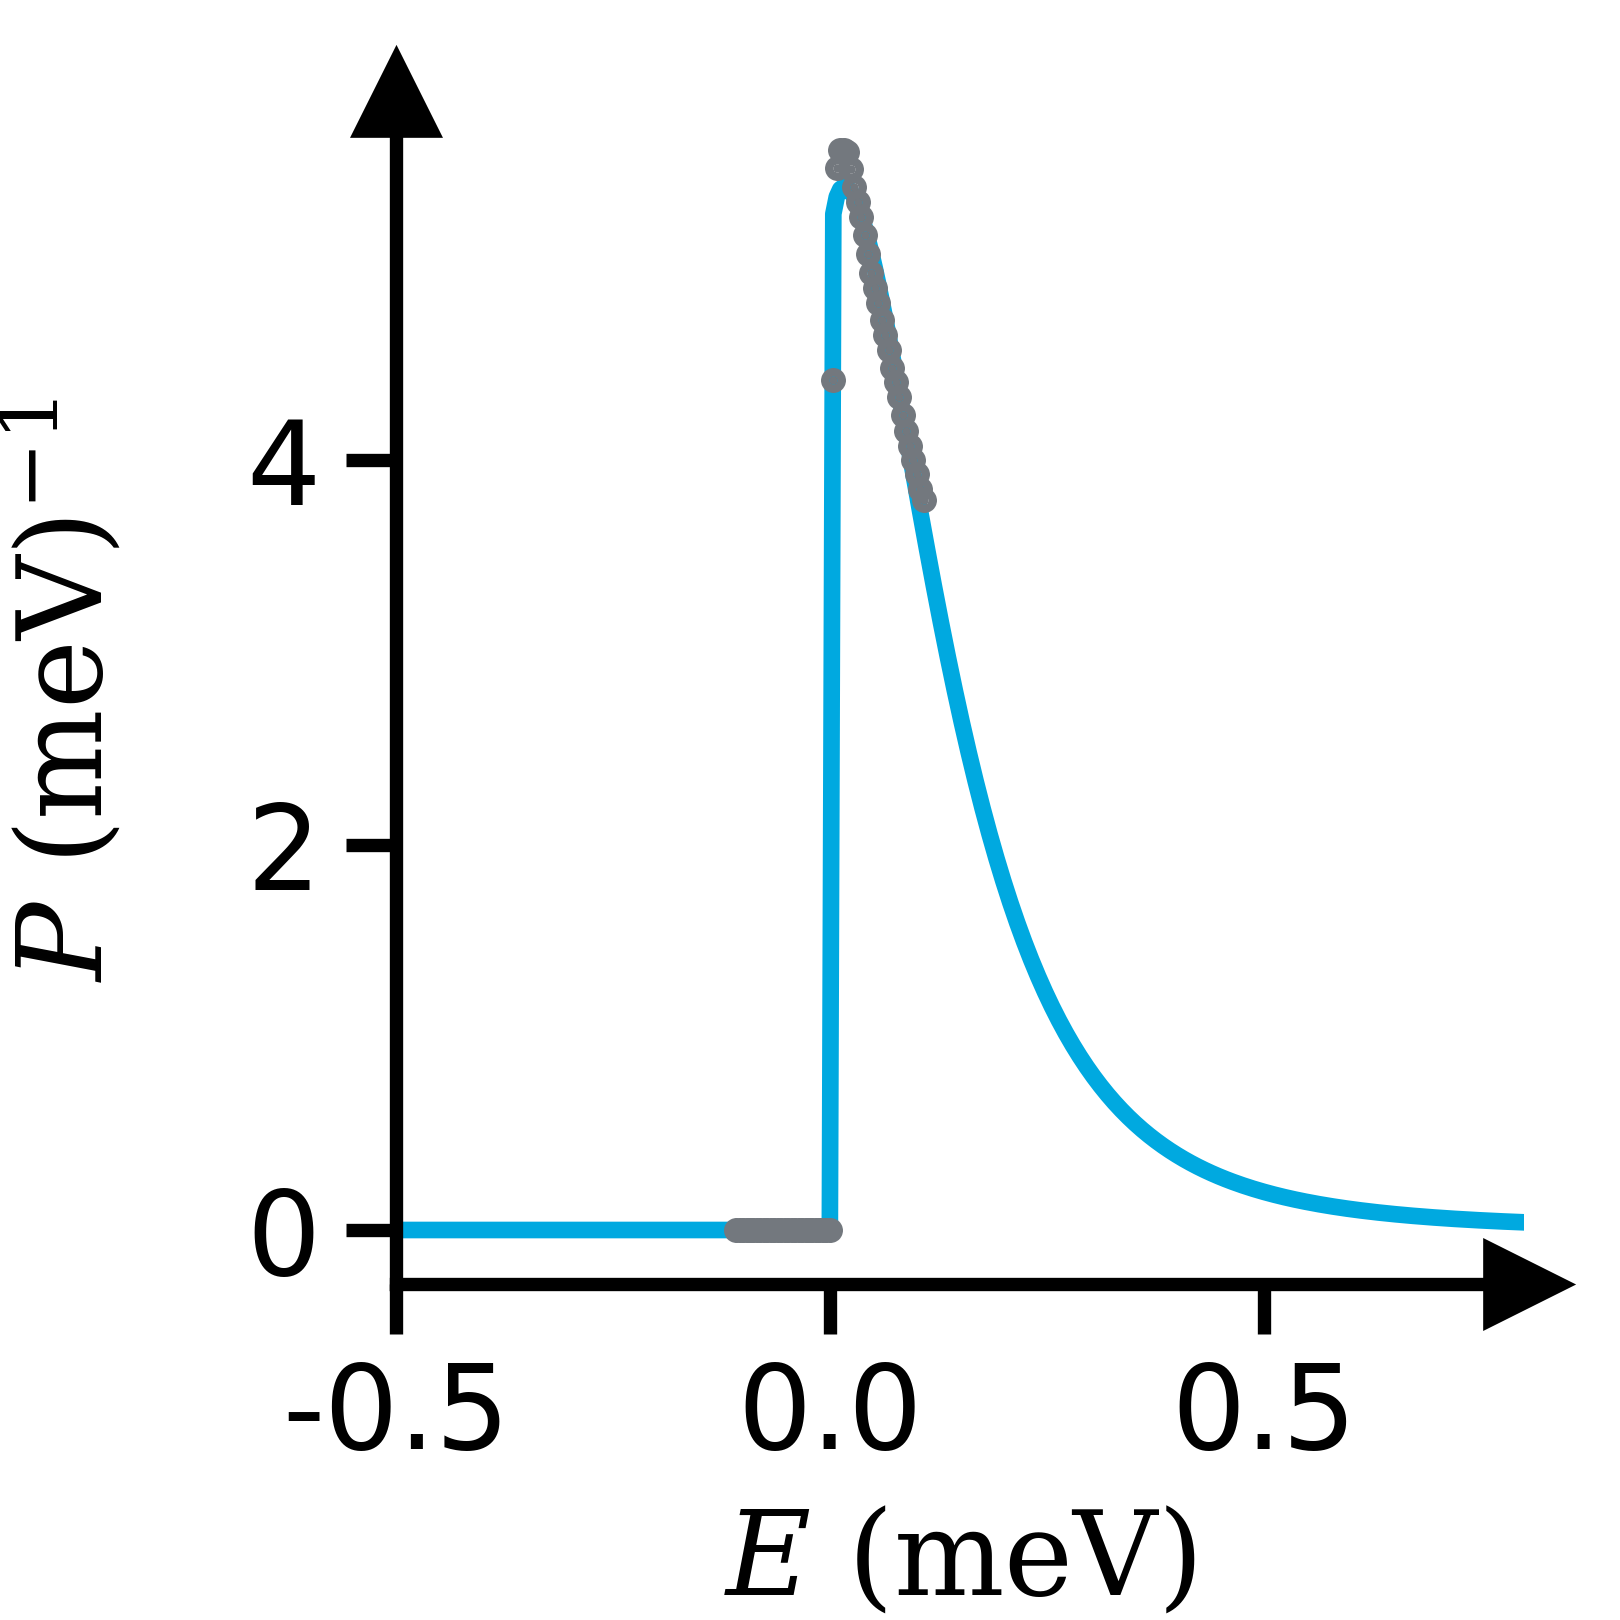

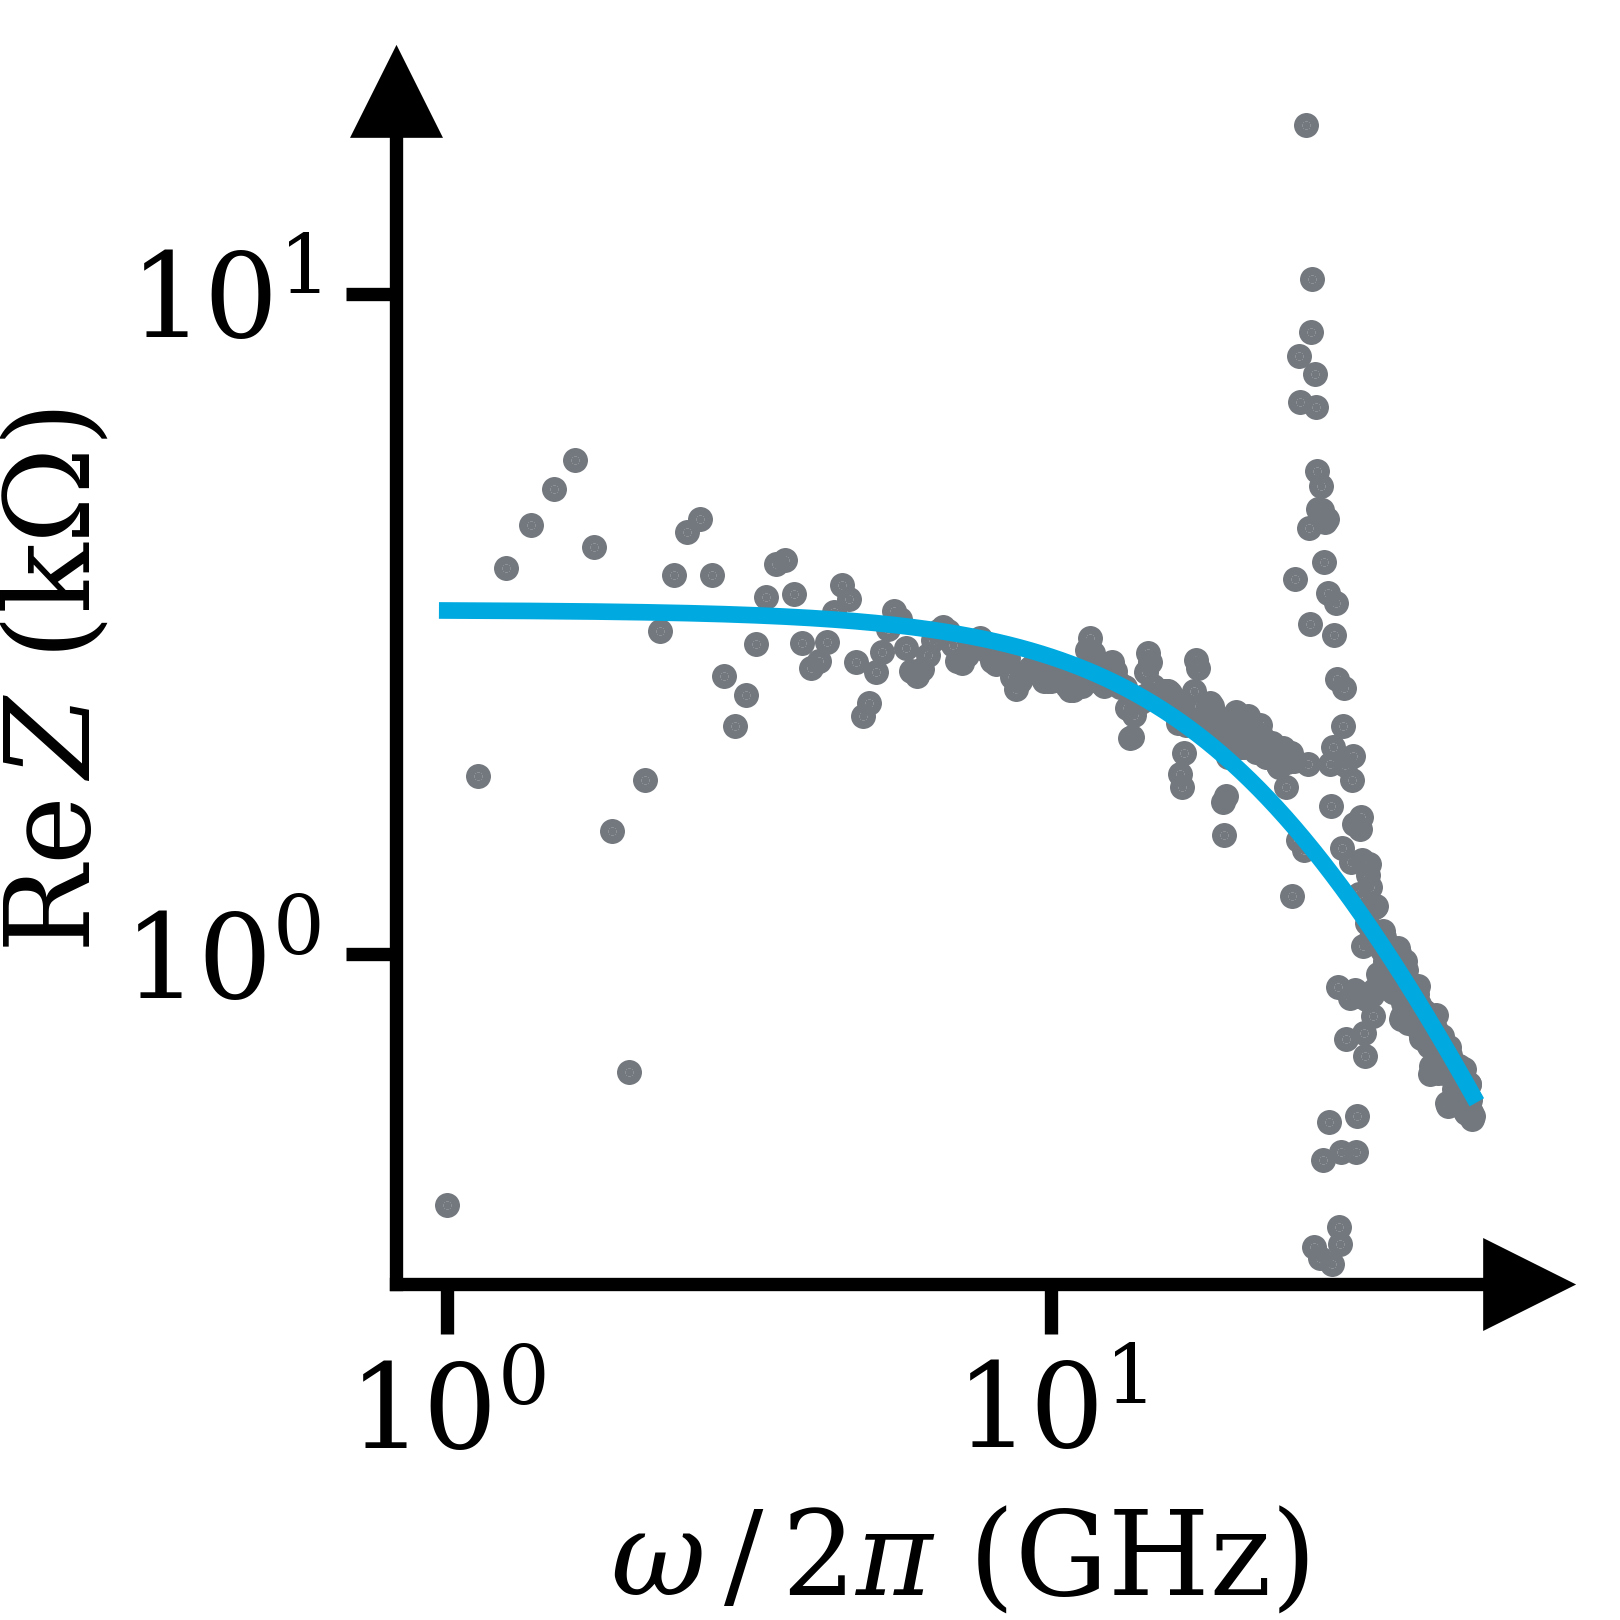

In [16]:
# fit sc
path = "1.8G0/15.0GHz_stripline"
data = np.load(f"{path}/sc_data.npz")
Vexp_mV = data["Vexp_mV"]
Iexp_nA = data["Iexp_nA"]
Vexp0_mV = data["Vexp0_mV"]
Iexp0_nA = data["Iexp0_nA"]
Vfit_mV = data["Vfit_mV"]
Ifit_nA = data["Ifit_nA"]
mask = data["mask"]
Reff_kOhm = data["Reff_kOhm"]
uReff_kOhm = data["uReff_kOhm"]
Ceff_fF = data["Ceff_fF"]
uCeff_fF = data["uCeff_fF"]
Ic_nA = data["Ic_nA"]
uIc_nA = data["uIc_nA"]
Eexp_ueV = data["Eexp_ueV"]
Pexp__ueV = data["Pexp__ueV"]
Efit_ueV = data["Efit_ueV"]
Pfit__ueV = data["Pfit__ueV"]
nu_GHz = data["nu_GHz"]
Zexp_kOhm = data["Zexp_kOhm"]
Zfit_kOhm = data["Zfit_kOhm"]

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vexp_mV, Iexp_nA, ".", color=sc.seegrau100, ms=1.0, label="data", zorder=0)
ax.plot(Vexp0_mV, Iexp0_nA, ".", color=sc.seegrau35, ms=1.0, label="igno.", zorder=-2)
ax.plot(Vfit_mV, Ifit_nA, "-", color=sc.seeblau100, label="fit", zorder=-1)
ax.set_xlim(-0.5, 0.8)
ax.set_ylim(-1.1, 1.3)
ax.set_yticks([-1, 0, 1])
# ax.set_ylim(-2.1, 2.3)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.08, 0.08)
ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/sc_fit/iv",
    "$V\\ (\\mathrm{mV})$",
    "$I\\ (\\mathrm{nA})$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Efit_ueV * 1e-3, Pfit__ueV * 1e3, "-", color=sc.seeblau100)
ax.plot(Eexp_ueV * 1e-3, Pexp__ueV * 1e3, ".", color=sc.seegrau100, ms=1.0)
ax.set_xlim(-0.5, 0.8)
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/sc_fit/pe",
    "$E\\ (\\mathrm{meV})$",
    "$P\\ (\\mathrm{meV})^{-1}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
mask = (nu_GHz >= 0.9) & (nu_GHz <= 50.0)
ax.plot(
    np.log10(nu_GHz[mask]),
    np.log10(np.abs(np.real(Zexp_kOhm[mask]))),
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(
    np.log10(nu_GHz[mask]), np.log10(np.real(Zfit_kOhm[mask])), "-", color=sc.seeblau100
)
# ax.plot(Efit_ueV, Pfit__ueV, "-", color=sc.seeblau100)
ax.set_ylim(-0.5, 1.3)
ax.set_yticks([0, 1], labels=["$10^0$", "$10^1$"])
ax.set_xticks([0, 1], labels=["$10^0$", "$10^1$"])
sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/sc_fit/zv",
    "$\\omega\\,/\\,2\\pi\\ \\mathrm{(GHz)}$",
    "$\\,\\mathrm{Re}\,Z\\ \\mathrm{(k\\Omega)}$",
)
plt.show()

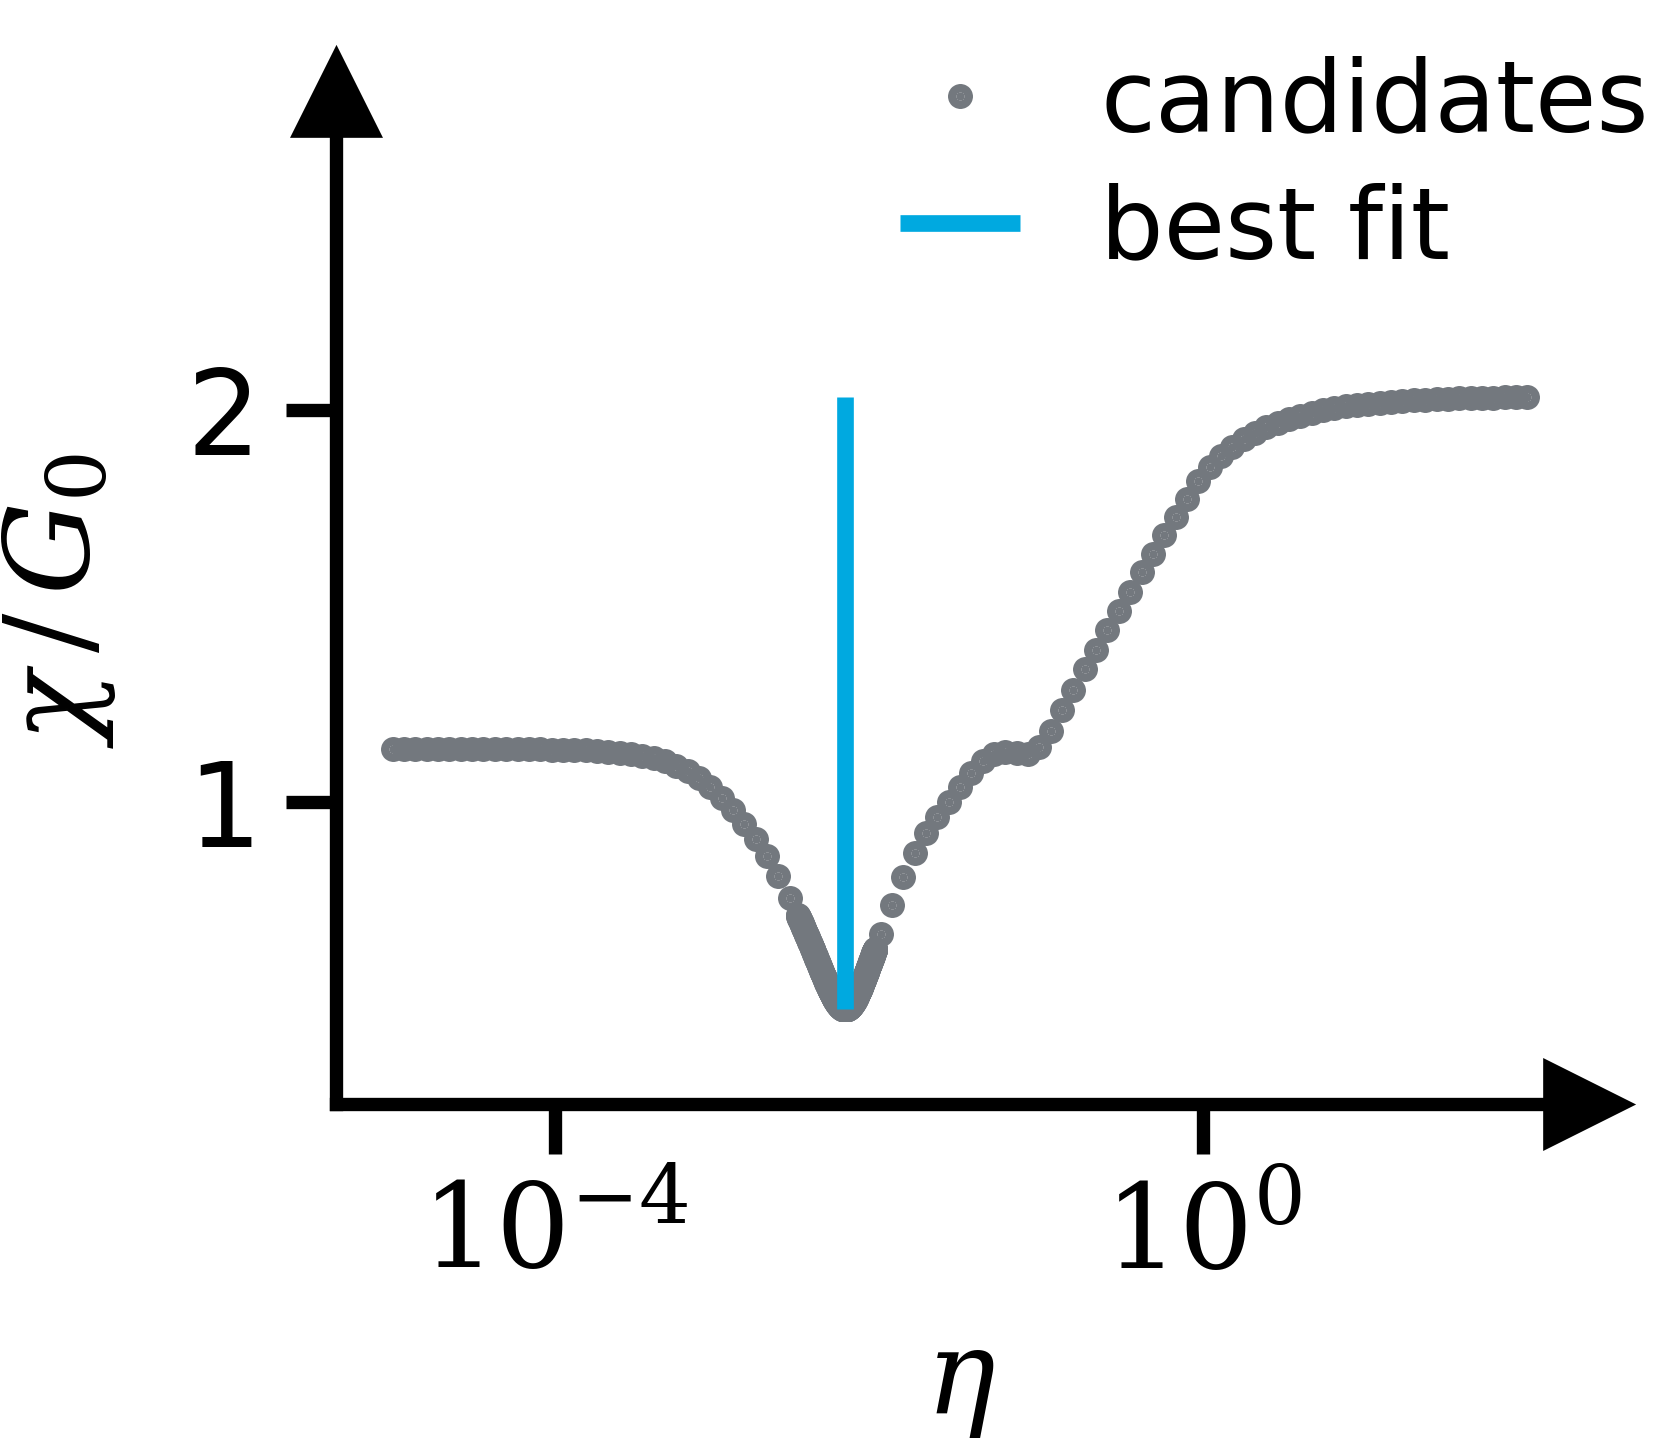

In [25]:
# fit eta
path = "1.8G0/15.0GHz_stripline"
data = np.load(f"{path}/eta_data.npz")
eta = data["eta"]
etas = data["etas"]
chi = data["chi"]
chis = np.sqrt(data["chis"])

fig, ax = sc.get_figure(figsize=(1.4, 1.2), padding=(0.2, 0.2))
ax.plot(np.log10(etas), chis, ".", color=sc.seegrau100, ms=1.0, label="candidates")
ax.vlines(
    np.log10(eta), np.min(chis), np.max(chis), color=sc.seeblau100, label="best fit"
)
ax.set_xticks([-4, 0], labels=["$10^{-4}$", "$10^{0}$"])
ax.set_yticks([1, 2])
ax.set_ylim(0.23, 2.8)


ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper right",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.1, 1.1),
)

sc.theory_layout(
    fig,
    ax,
    f"atomic_contact/{path}/eta_fit",
    "$\\eta$",
    "$\\chi\\,/\\,G_0$",
)
plt.show()

## Calibrated transport landscape

The axes are normalized by $G_N\Delta$, $h\nu$, and the fitted line attenuation $\eta$.

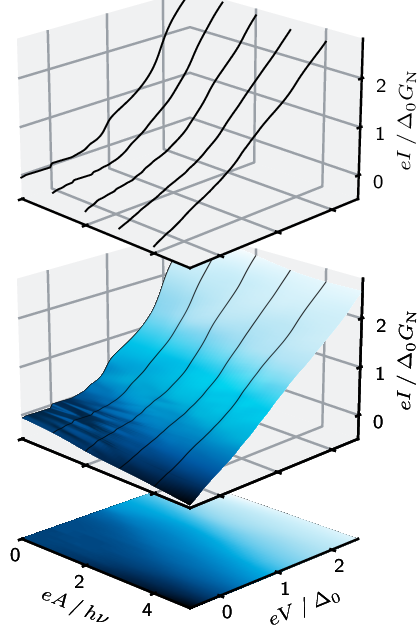

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/1.8G0/15.0GHz_stripline/cal_iv/main.png

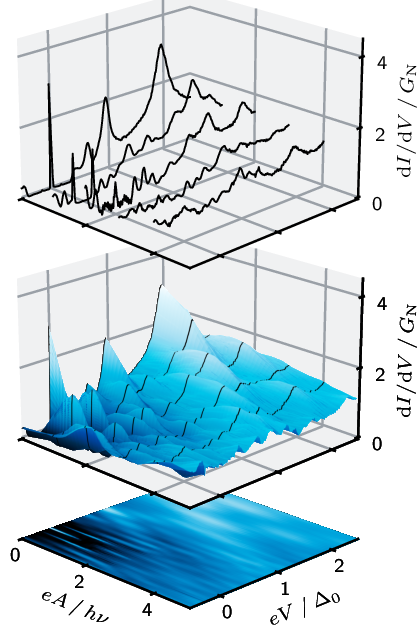

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/1.8G0/15.0GHz_stripline/cal_didv/main.png

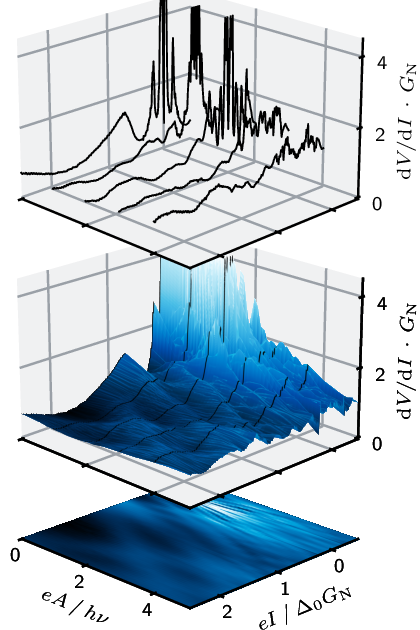

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/1.8G0/15.0GHz_stripline/cal_dvdi/main.png

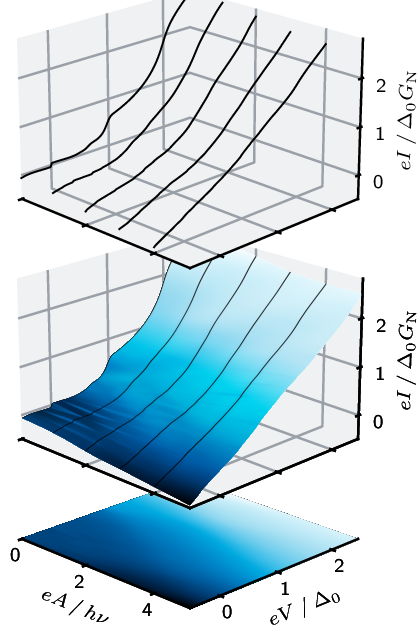

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/1.8G0/15.0GHz_stripline/sim_iv/main.png

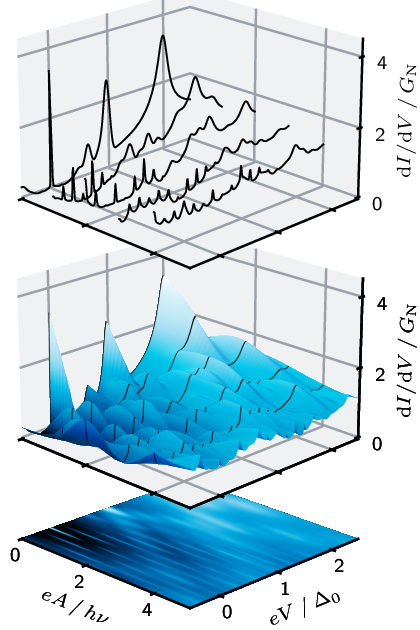

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/1.8G0/15.0GHz_stripline/sim_didv/main.png

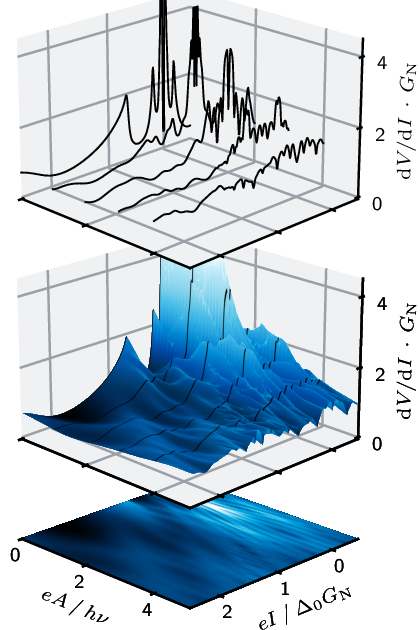

/Users/oliver/Documents/cryolab/dissertation-figures/atomic_contact/1.8G0/15.0GHz_stripline/sim_dvdi/main.png

In [90]:
# 1.8G0, 15Ghz, stripline, cal + sim
path = "1.8G0/15.0GHz_stripline"
data_eva = np.load(f"{path}/eva.npz")
data_mar = np.load(f"{path}/mar_data.npz")
data_eta = np.load(f"{path}/eta_data.npz")
data_sim = np.load(f"{path}/sim.npz")

GN_G0 = float(data_mar["GN_G0"])
Delta_meV = float(data_mar["Delta_meV"])
nu_GHz = float(data_eta["nu_GHz"])
eta = float(data_eta["eta"])

Vbias = data_sim["Vbias"]
Ibias = data_sim["Ibias"]
Abias = data_sim["Abins"]

Iexp = data_sim["Iexp1"]
dGexp = data_sim["dGexp1"]
dRexp = data_sim["dRexp1"]

Isim = data_sim["Isim1"]
dGsim = data_sim["dGsim1"]
dRsim = data_sim["dRsim1"]

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    waterfall_traces=[0, 1, 2, 3, 4],
    Vbiaslim=(-0.5, 2.5),
    Ibiaslim=(-0.5, 2.5),
    Abiaslim=(0, 5.0),
    Ilim=(-0.5, 2.8),
    Vbiasticks=[0, 1, 2],
    Ibiasticks=[0, 1, 2],
    Abiasticks=[0, 2, 4],
    Iticks=[0, 1, 2],
    surface_x_oversample=10,
    name="cal",
    sub_dir=f"atomic_contact/{path}/",
)
exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Isim,
    dGexp=dGsim,
    dRexp=dRsim,
    waterfall_traces=[0, 1, 2, 3, 4],
    Vbiaslim=(-0.5, 2.5),
    Ibiaslim=(-0.5, 2.5),
    Abiaslim=(0, 5.0),
    Ilim=(-0.5, 2.8),
    Vbiasticks=[0, 1, 2],
    Ibiasticks=[0, 1, 2],
    Abiasticks=[0, 2, 4],
    Iticks=[0, 1, 2],
    surface_x_oversample=10,
    name="sim",
    sub_dir=f"atomic_contact/{path}/",
)

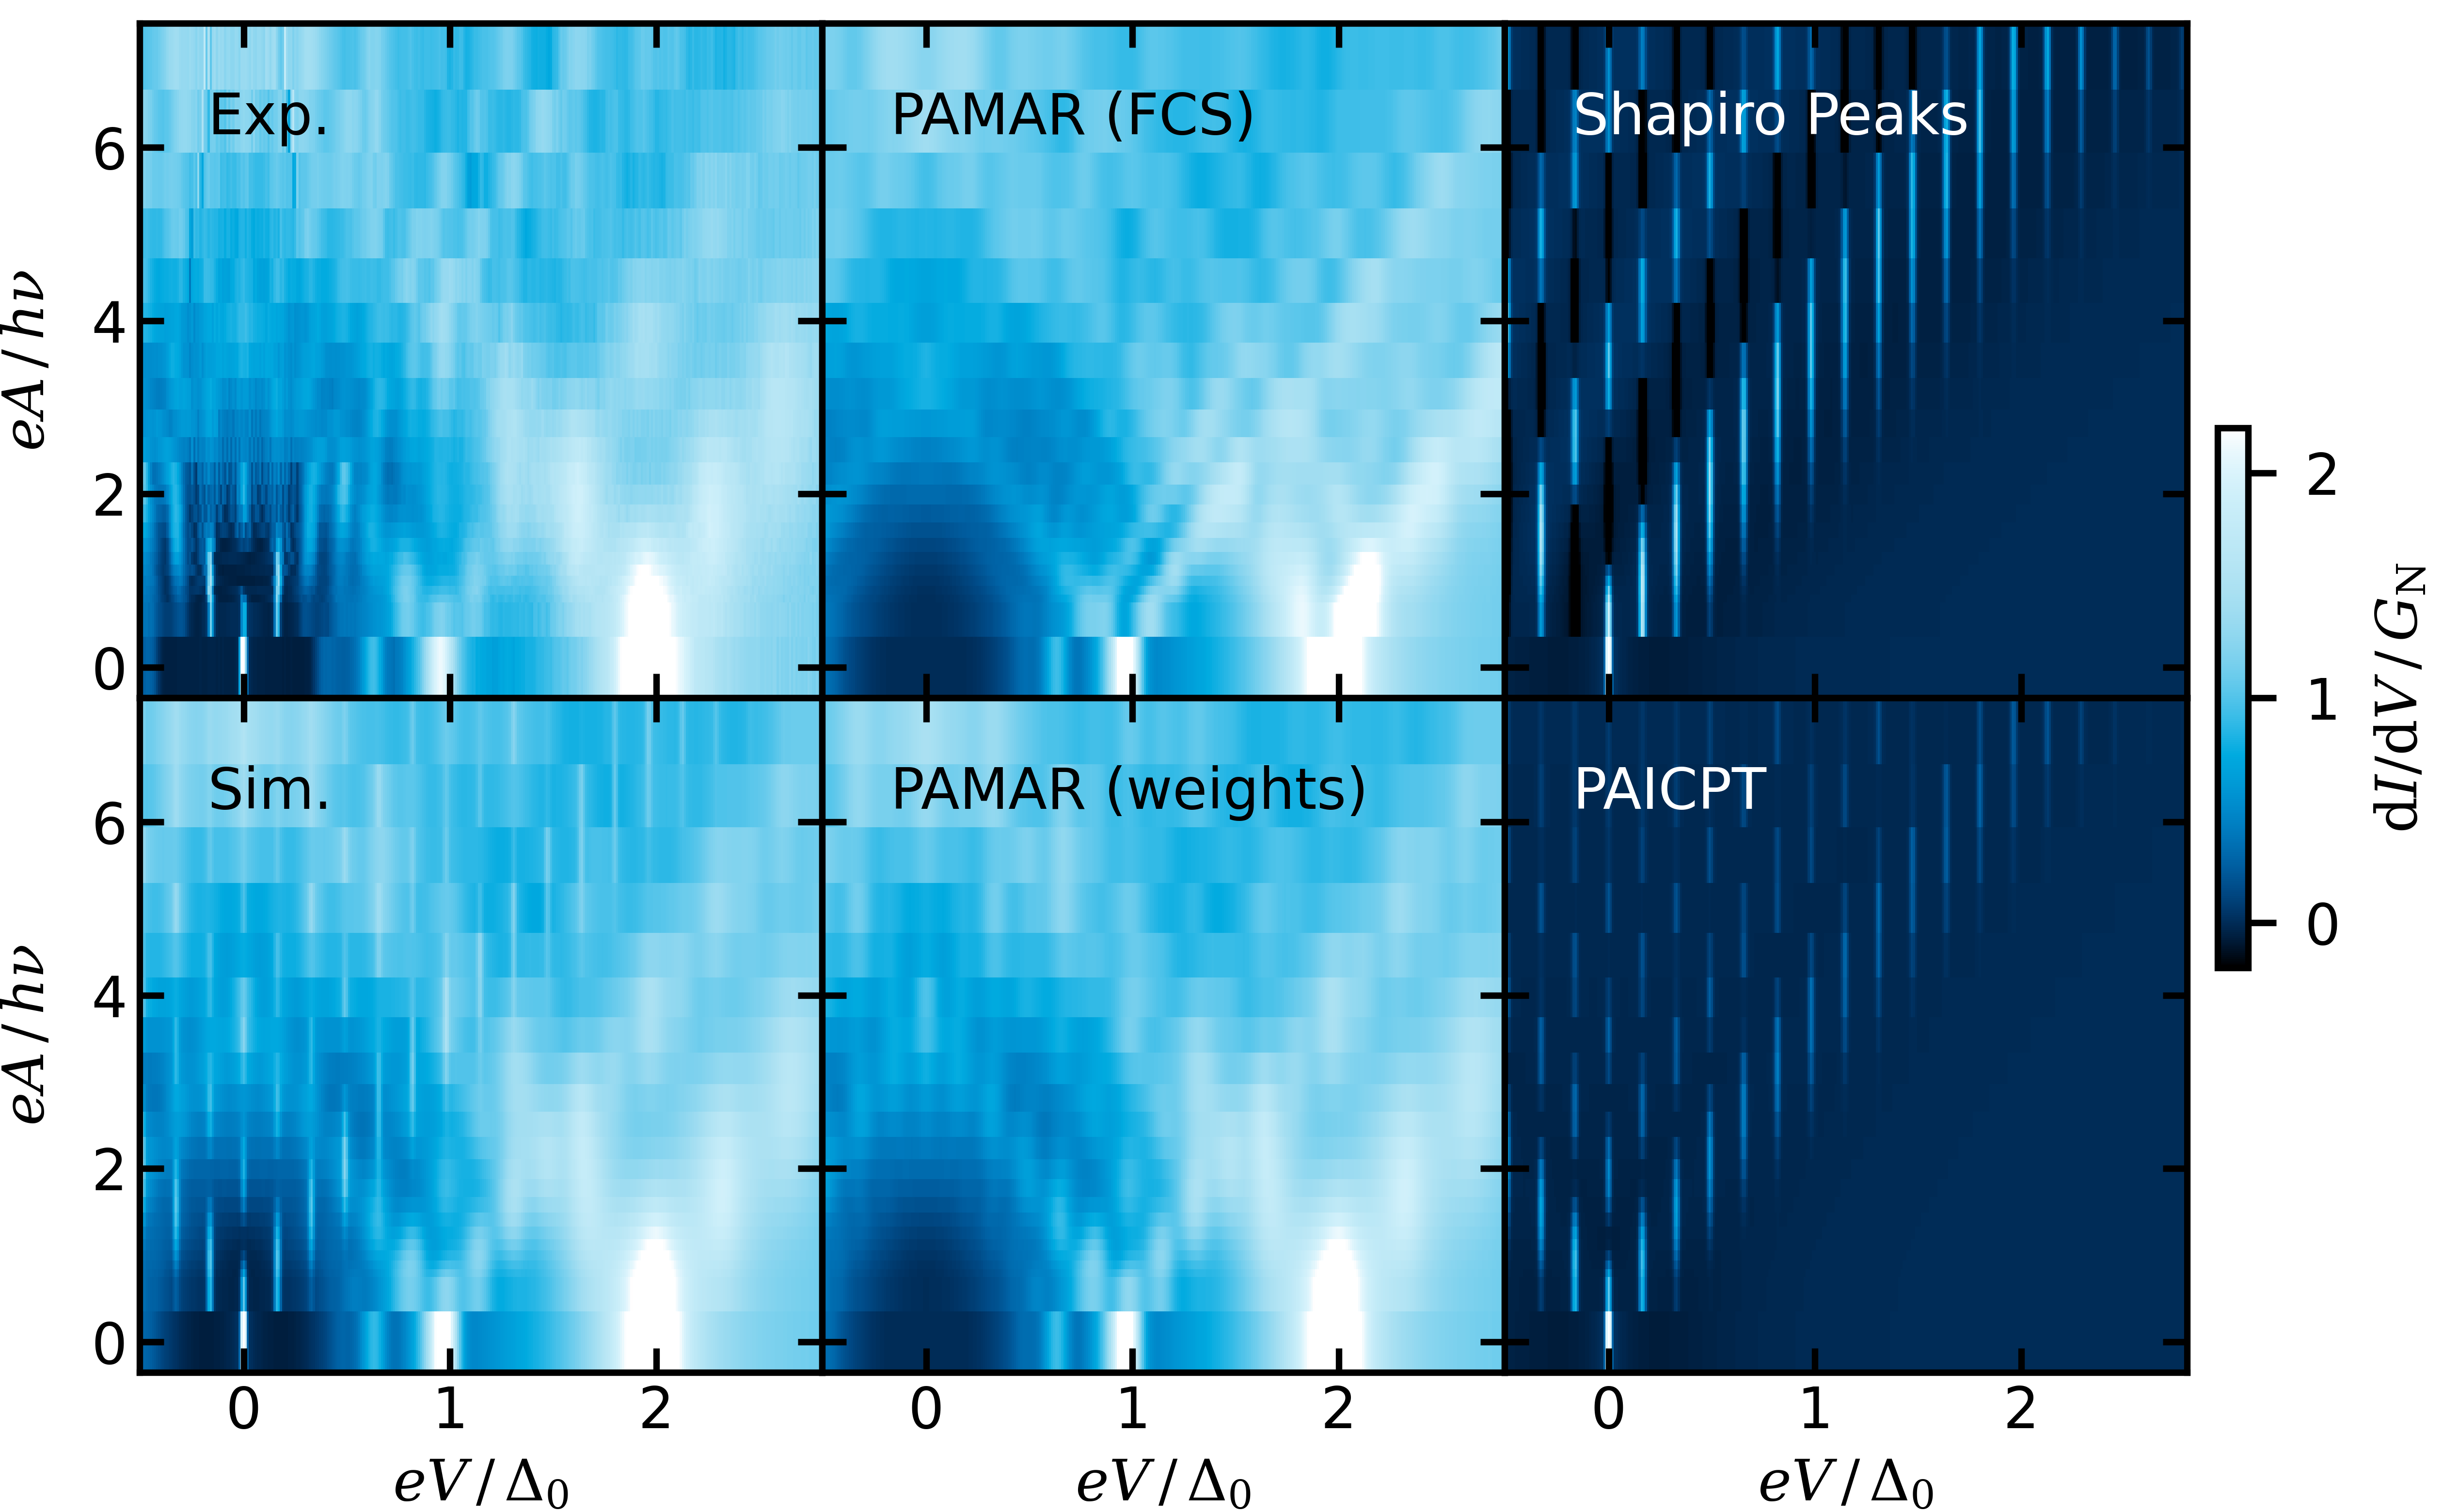

In [396]:
# 1.8G0, 15GHz, stripline, dIdVs

from superconductivity.style.thesislayout import save_figure

path = "1.8G0/15.0GHz_stripline"
data_sim = np.load(f"{path}/sim.npz")

Vbias = data_sim["Vbias"]
Ibias = data_sim["Ibias"]
Abias = data_sim["Abias"]

figsize = (4.2, 2.6)
padding = (0.2, 0.2, 0.4, 0.0)

dGlim = (-0.2, 2.2)

fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=2, ncols=3)

labels = ["Exp.", "PAMAR (FCS)", "Shapiro Peaks", "Sim.", "PAMAR (weights)", "PAICPT"]
for i, string in enumerate(["exp", "fcspamar", "sp", "sim", "pamar", "icpt"]):

    img = axes[i].pcolormesh(
        Vbias,
        Abias,
        data_sim[f"dG{string}"],
        cmap=sc.get_cmap(bad="grey", inverse=False),
        clim=dGlim,
        rasterized=True,
    )
    axes[i].text(
        0.1,
        0.9,
        labels[i],
        transform=axes[i].transAxes,
        ha="left",
        va="top",
        size=7,
        color=[1, 1, 1, 1] if i % 3 == 2 else [0, 0, 0, 1],
    )

sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$eA\\,/\\,h\\nu$",
)

right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.4
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.0125, new_bottom, 0.0125, new_height])

cbar = fig.colorbar(
    img,
    cax=cax,
    ticks=[0, 1, 2],
)
cbar.set_label("$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$", fontsize=7)
cbar.ax.tick_params(labelsize=7)

title = f"atomic_contact/{path}/didv-img/didvs"
from superconductivity.style.thesislayout import save_figure

save_figure(fig, title)
plt.show()

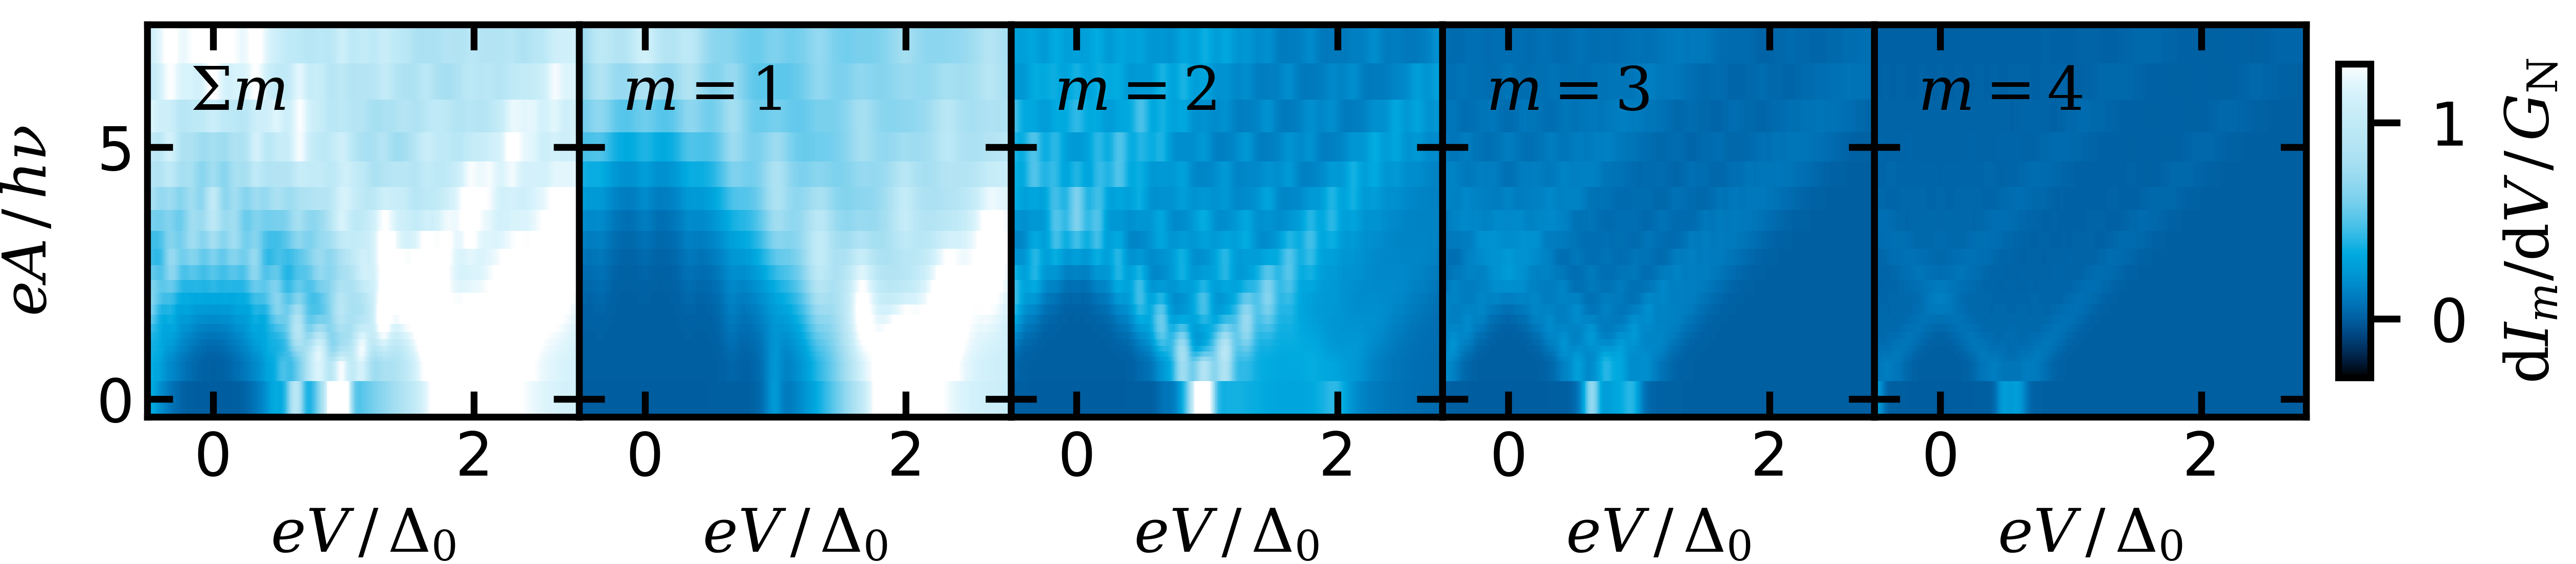

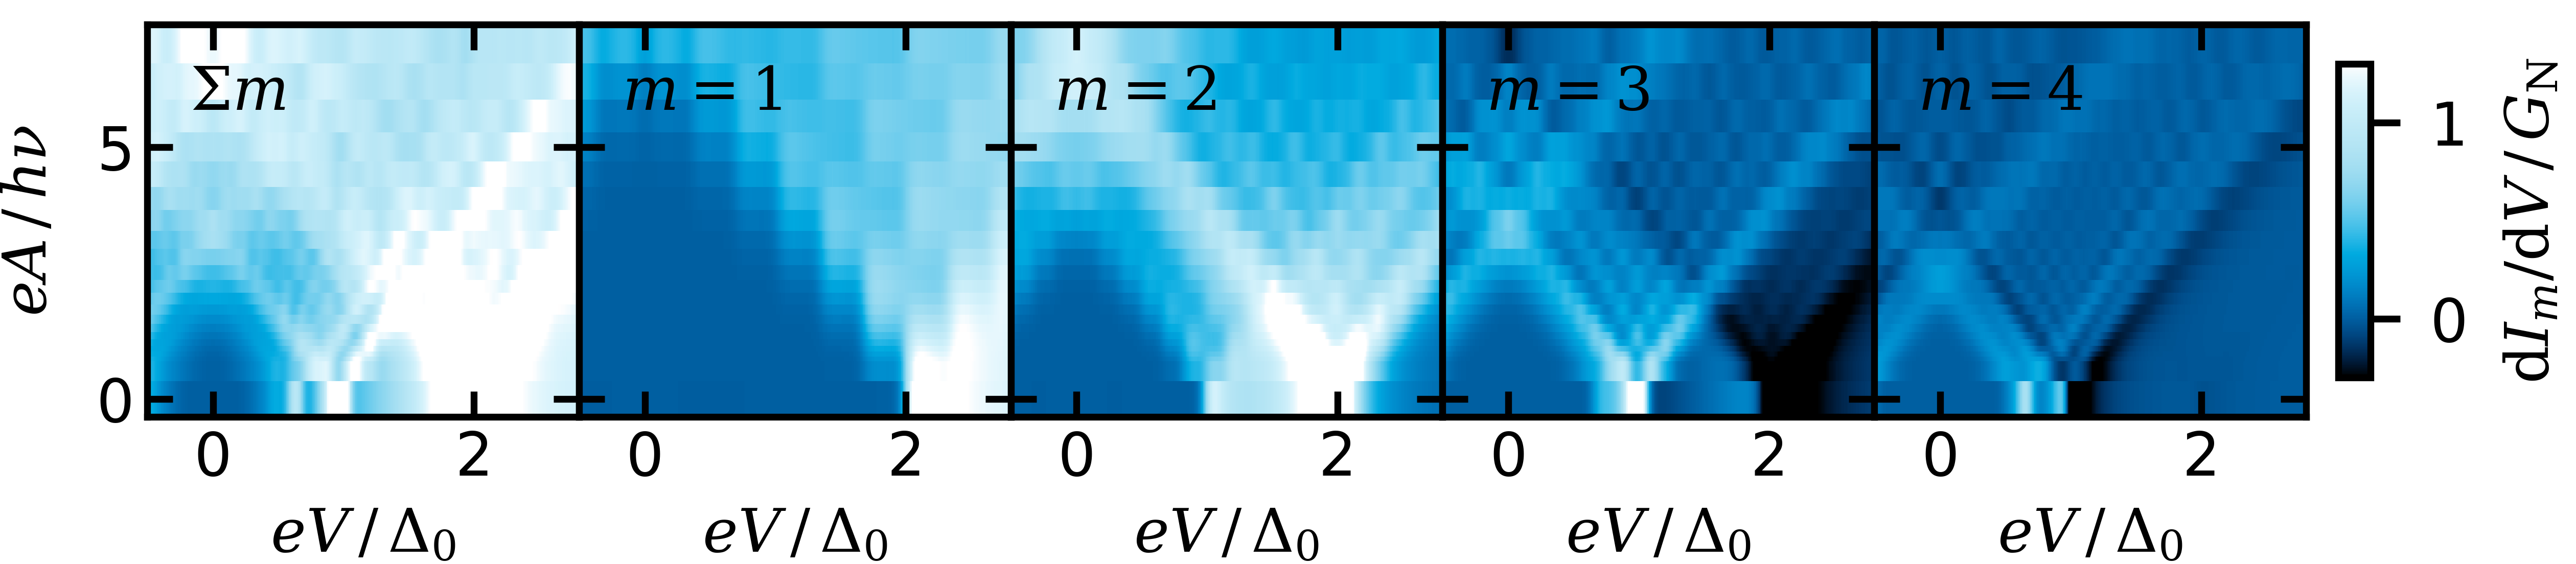

In [397]:
# 1.8G0, 15GHz, stripline, dIdV_m

from superconductivity.style.thesislayout import save_figure

path = "1.8G0/15.0GHz_stripline"
data_sim = np.load(f"{path}/sim.npz")

Vbias = data_sim["Vbias"]
Ibias = data_sim["Ibias"]
Abias = data_sim["Abias"]

dGfcsm = data_sim[f"dGfcspamarm"]
dGfcs = data_sim[f"dGfcspamar"]
dGpamarm = data_sim[f"dGpamarm"]
dGpamar = data_sim[f"dGpamar"]

figsize = (4.2, 0.92)
padding = (0.2, 0.2, 0.4, 0.0)
nrows = 1
ncols = 5

dGlimpamar = (-0.3, 1.3)
dGlimfcs = (-0.3, 1.3)

# region plots
# fig pamarm
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=nrows, ncols=ncols)
axes[0].pcolormesh(
    Vbias,
    Abias,
    dGpamar,
    cmap=sc.get_cmap(bad="grey"),
    clim=dGlimpamar,
    rasterized=True,
)
axes[0].text(
    0.1, 0.9, f"$\Sigma m$", transform=axes[0].transAxes, ha="left", va="top", size=7
)
for i in range(4):
    img = axes[i + 1].pcolormesh(
        Vbias,
        Abias,
        dGpamarm[i, :, :],
        cmap=sc.get_cmap(bad="grey"),
        clim=dGlimpamar,
        rasterized=True,
    )
    axes[i + 1].text(
        0.1,
        0.9,
        f"$m={i+1}$",
        transform=axes[i + 1].transAxes,
        ha="left",
        va="top",
        size=7,
    )

sc.daumenkino_layout(
    fig, axes, xlabel="$eV\\,/\\,\\Delta_0$", ylabel="$eA\\,/\\,h\\nu$"
)

right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.0125, new_bottom, 0.0125, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=(0, 1))
cbar.set_label("$\\mathrm{d}I_m/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$", fontsize=7)
cbar.ax.tick_params(labelsize=7)

title = f"atomic_contact/{path}/didv-img/pamarm"

save_figure(fig, title)
plt.show()

# fig fcs pamar m
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=nrows, ncols=ncols)
axes[0].pcolormesh(
    Vbias,
    Abias,
    dGfcs,
    cmap=sc.get_cmap(bad="grey"),
    clim=dGlimfcs,
    rasterized=True,
)
axes[0].text(
    0.1, 0.9, f"$\Sigma m$", transform=axes[0].transAxes, ha="left", va="top", size=7
)
for i in range(4):
    img = axes[i + 1].pcolormesh(
        Vbias,
        Abias,
        dGfcsm[i, :, :],
        cmap=sc.get_cmap(bad="grey"),
        clim=dGlimfcs,
        rasterized=True,
    )
    axes[i + 1].text(
        0.1,
        0.9,
        f"$m={i+1}$",
        transform=axes[i + 1].transAxes,
        ha="left",
        va="top",
        size=7,
    )

sc.daumenkino_layout(
    fig, axes, xlabel="$eV\\,/\\,\\Delta_0$", ylabel="$eA\\,/\\,h\\nu$"
)

right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.0125, new_bottom, 0.0125, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=(0, 1))
cbar.set_label("$\\mathrm{d}I_m/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$", fontsize=7)
cbar.ax.tick_params(labelsize=7)

title = f"atomic_contact/{path}/didv-img/fcsm"

save_figure(fig, title)
plt.show()
# endregion

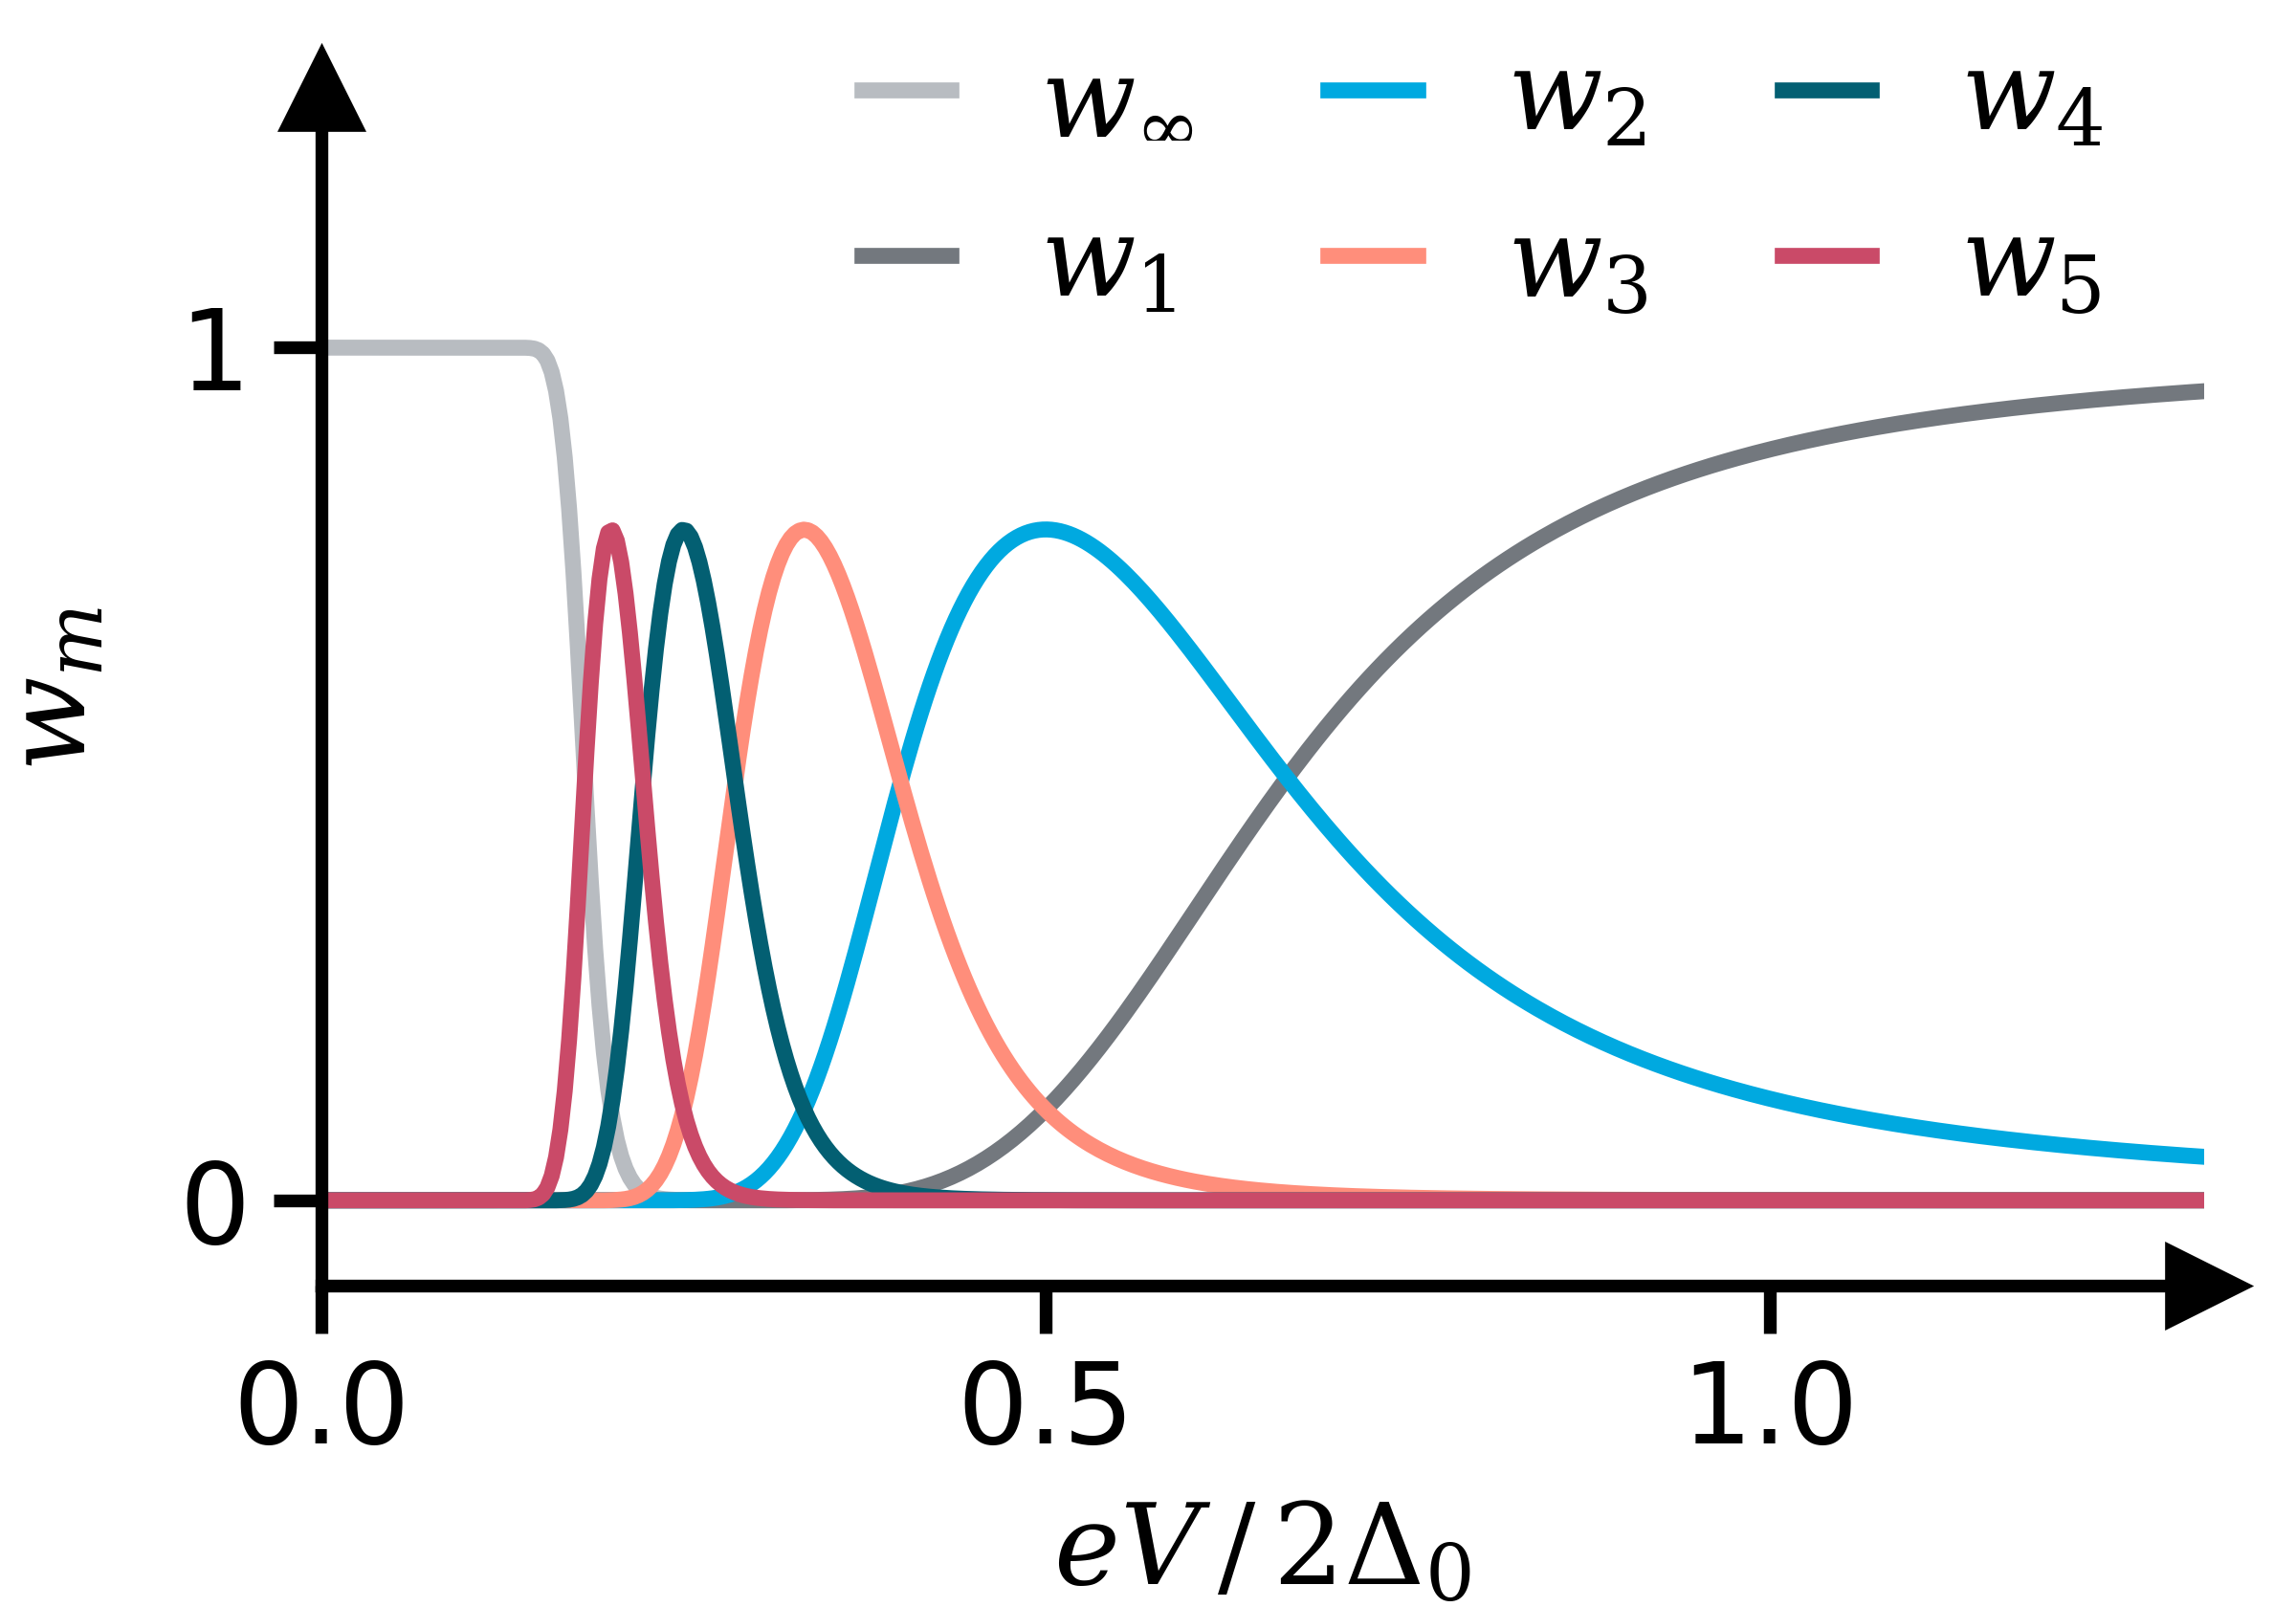

/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_9514/3673696111.py:90: RuntimeWarning: divide by zero encountered in divide
  ax.plot(2 / Vbias, unused, color=sc.seegrau35, zorder=-1 - mmax)


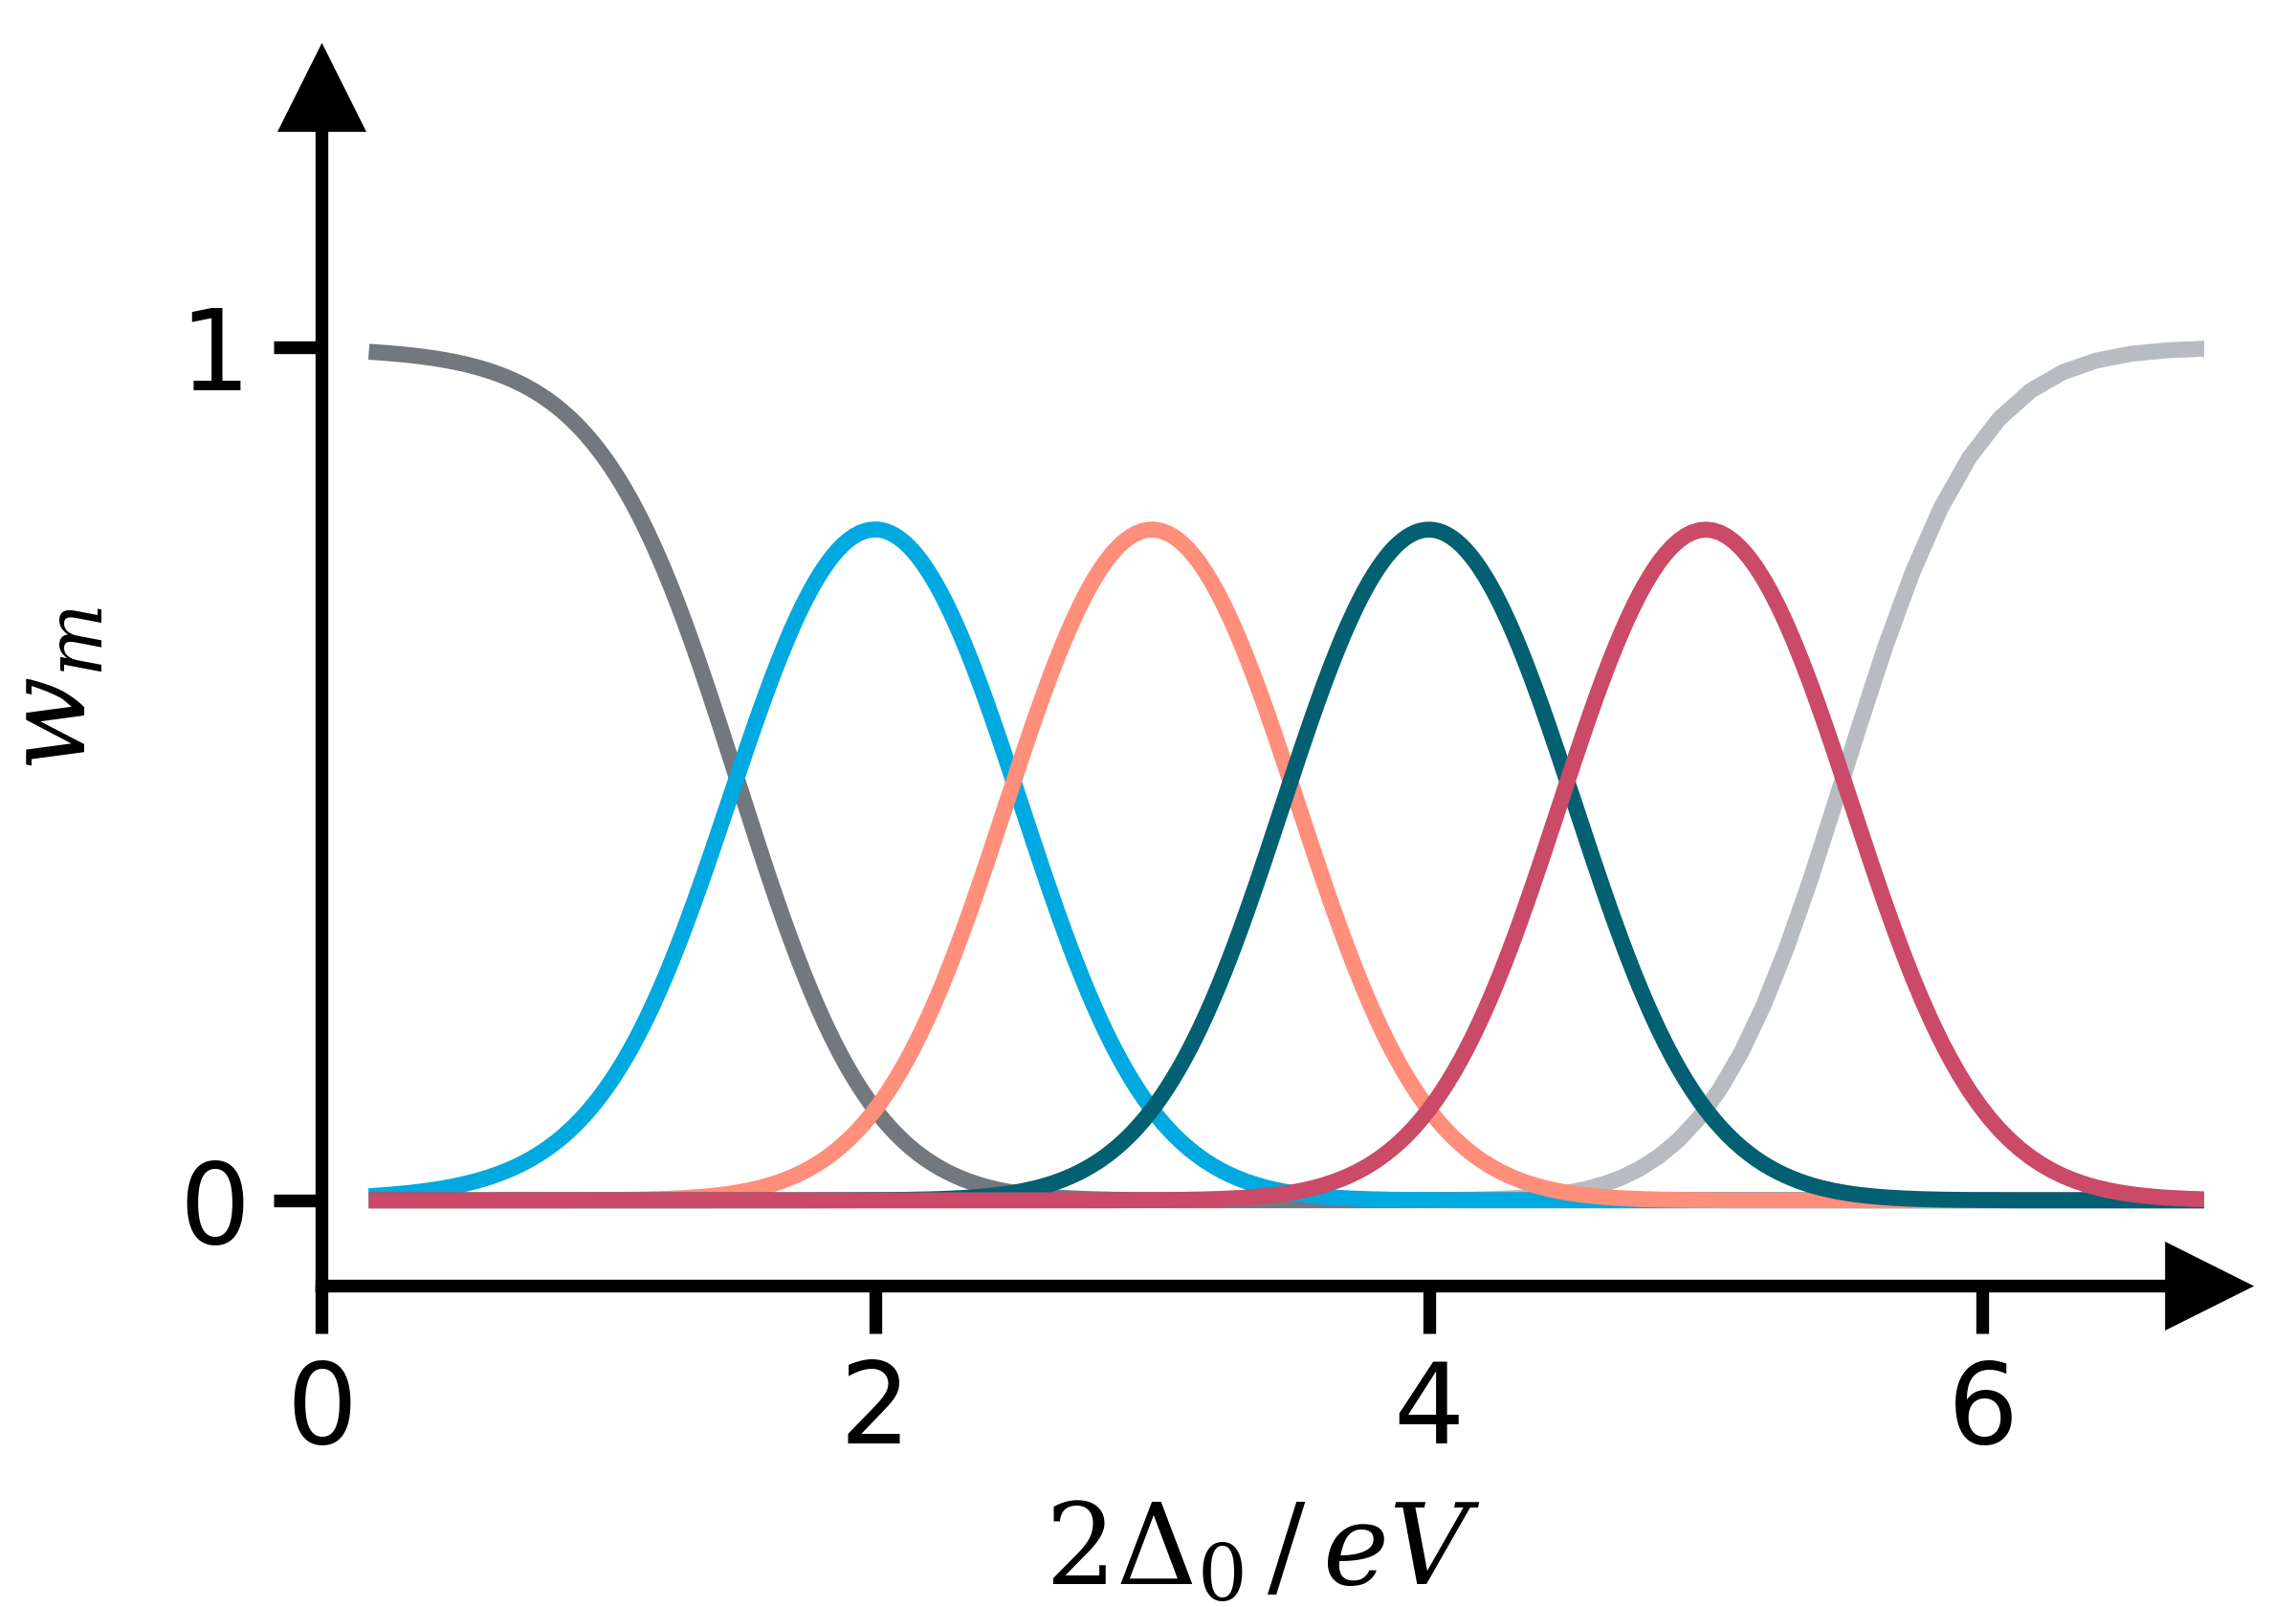

In [399]:
# pamar weights

Vbias1 = np.linspace(0.002, 1.0, 500)
Vbias2 = np.linspace(1.0, 3.5, 251)
Vbias3 = np.linspace(3.6, 10, 65)
Vbias0 = np.concatenate((Vbias1, Vbias2, Vbias3))
from sim_pamar import get_weights

mmax = 5

weights1 = get_weights(Vbias1, mmax=mmax)
weights2 = get_weights(Vbias2, mmax=mmax)
weights3 = get_weights(Vbias3, mmax=mmax)
weights0 = np.concatenate((weights1, weights2, weights3), axis=-1)

Vbias = np.linspace(0, 3, 501)
weights, unused = get_weights(Vbias, mmax=mmax, return_unused=True)

color_strings = [
    "seegrau",
    "seeblau",
    "peach",
    "petrol",
    "pinky",
    "seegruen",
    "karpfenblau",
    "bordeaux",
    "seeblau",
]
figsize = (2.0, 1.4)

fig, ax = sc.get_figure(figsize=figsize)

for i in range(mmax):
    ax.plot(
        Vbias / 2,
        weights[i],
        color=sc.get_color(palette=color_strings[i], shade=0),
        zorder=i - mmax,
        label=f"{i+1}",
    )
ax.plot(Vbias / 2, unused, color=sc.seegrau35, zorder=-1 - mmax)
ax.set_xlim(0, 1.3)
ax.set_ylim(-0.1, 1.3)
ax.set_yticks([0, 1])

xlabel = "$eV\\,/\\,2\\Delta_0$"
ylabel = "$w_m$"
title = f"atomic_contact/pamar-weights/V"

handles, labels = [], []
line_handle = Line2D([0], [0], color=sc.seegrau35, linestyle="-")
label = f"$w_\\infty$"
handles.append(line_handle)
labels.append(label)

for i in range(mmax):
    line_handle = Line2D(
        [0], [0], color=sc.get_color(palette=color_strings[i], shade=0), linestyle="-"
    )
    label = f"$w_{i+1}$"
    handles.append(line_handle)
    labels.append(label)

ax.legend(
    handles=handles,
    labels=labels,
    handlelength=0.8,
    loc="upper right",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=3,
    columnspacing=1.2,
    bbox_to_anchor=(1.0, 1.125),
)

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

fig, ax = sc.get_figure(figsize=figsize)

for i in range(mmax):
    ax.plot(
        2 / Vbias0,
        weights0[i],
        color=sc.get_color(palette=color_strings[i], shade=0),
        label=f"{i+1}",
    )
ax.plot(2 / Vbias, unused, color=sc.seegrau35, zorder=-1 - mmax)
ax.set_xlim(0, 6.8)
ax.set_ylim(-0.1, 1.3)
ax.set_yticks([0, 1])

xlabel = "$2\\Delta_0\\,/\\,eV$"
ylabel = "$w_m$"
title = f"atomic_contact/pamar-weights/1_V"

# ax.legend(
#     handles=handles,
#     labels=labels,
#     handlelength=0.8,
#     loc="upper right",
#     frameon=False,
#     fontsize=7,
#     title_fontsize=7,
#     ncols=3,
#     columnspacing=1.2,
#     bbox_to_anchor=(1.0, 1.125),
# )

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

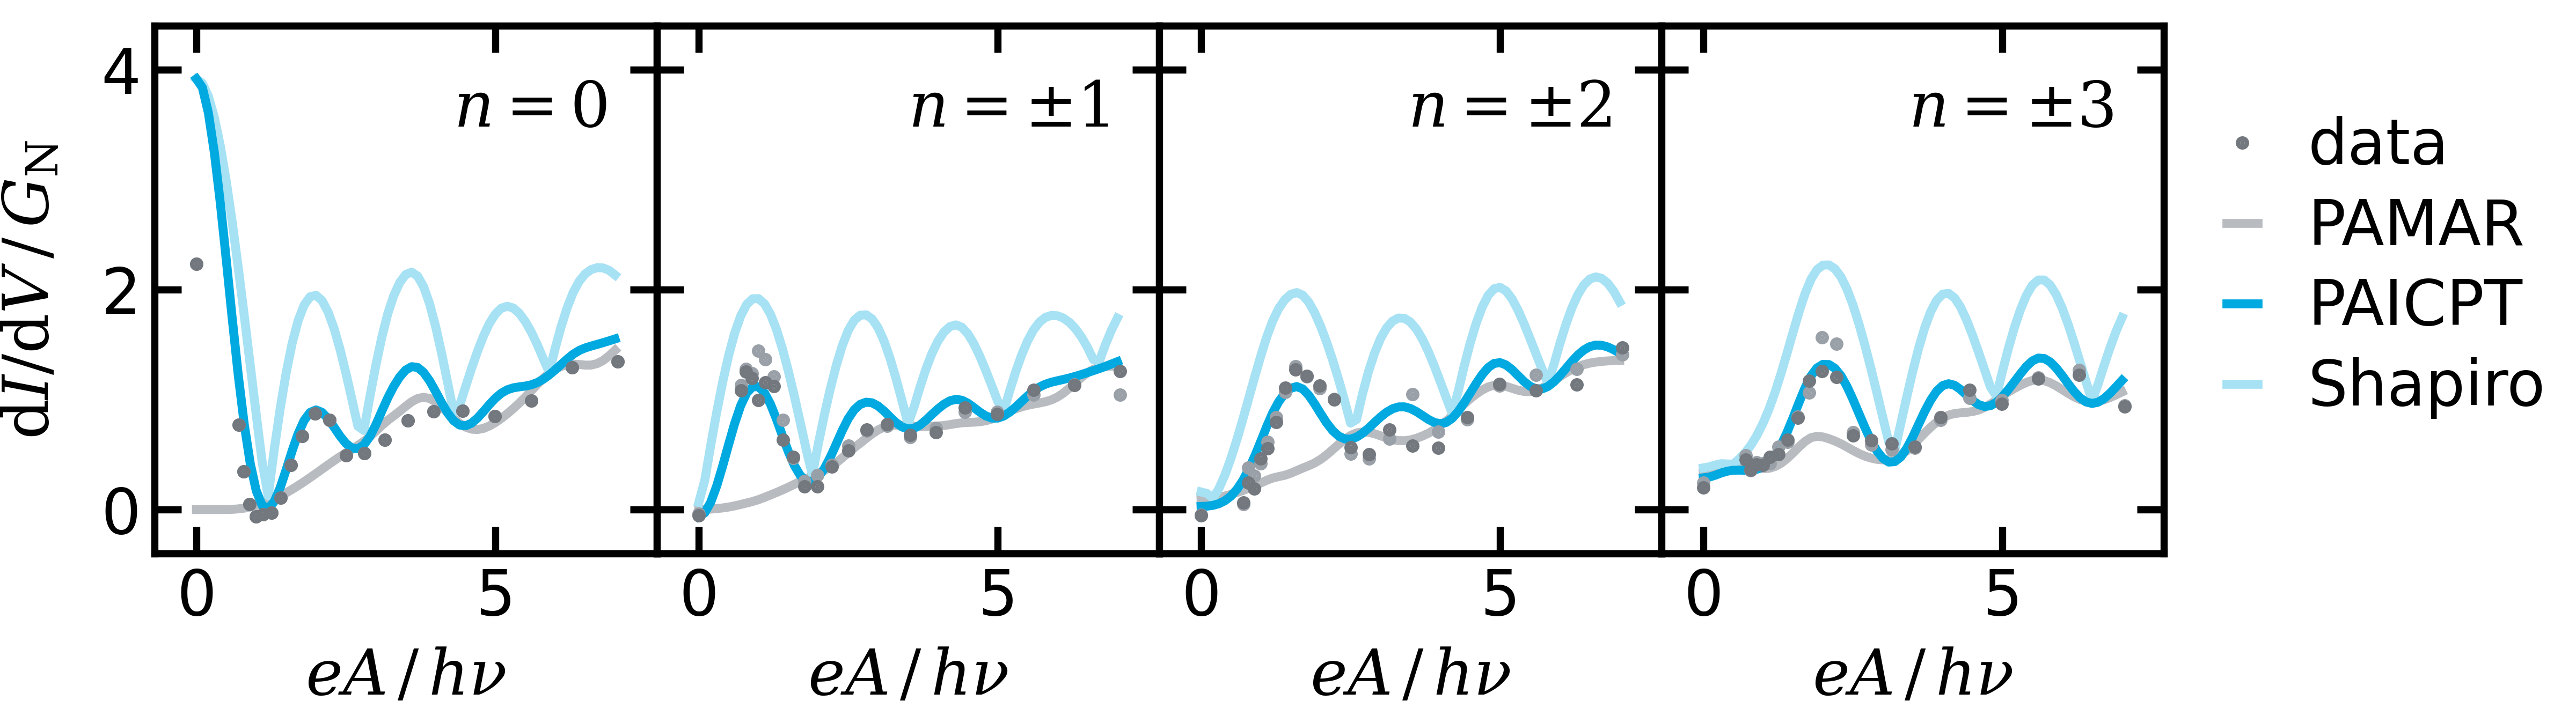

In [400]:
# dIdV(A)
import superconductivity as sc
from tqdm.auto import tqdm
from apply_sigmaV import apply_sigmaV
from sc_fit import simulate_sc_current_nA
from scipy.integrate import cumulative_trapezoid

path = "1.8G0/15.0GHz_stripline"
data_sim = np.load(f"{path}/sim.npz")

Vbias0 = data_sim["Vbias0"]
Abias = data_sim["Abias"]
Abias2 = data_sim["Abias2"]
dGexp0 = data_sim["dGexp0"]

dGpamar20 = data_sim["dGpamar20"]
dGicpt20 = data_sim["dGicpt20"]
dGsp20 = data_sim["dGsp20"]

fig, axes = sc.get_figures(
    figsize=(4.0, 1.1),
    padding=(0.2, 0.2, 0.6, 0.0),
    nrows=1,
    ncols=4,
)
n = np.arange(4)
Vn = n * sc.h_pVs * nu_GHz / (2 * Delta_meV)

for i, vbias in enumerate(Vn):
    index0 = np.argmin(np.abs(Vbias0 - vbias))
    index1 = np.argmin(np.abs(Vbias0 + vbias))
    axes[i].plot(
        Abias, dGexp0[:, index0], ".", color=sc.seegrau100, label="data", zorder=0
    )
    axes[i].plot(Abias, dGexp0[:, index1], ".", color=sc.seegrau65, zorder=-1)
    axes[i].plot(
        Abias2, dGpamar20[:, index0], "-", color=sc.seegrau35, label="PAMAR", zorder=-4
    )
    axes[i].plot(
        Abias2,
        dGpamar20[:, index0] + dGicpt20[:, index0],
        "-",
        color=sc.seeblau100,
        label="PAICPT",
        zorder=-2,
    )
    axes[i].plot(
        Abias2,
        dGpamar20[:, index0] + dGsp20[:, index0],
        "-",
        color=sc.seeblau35,
        label="Shapiro",
        zorder=-3,
    )
    axes[i].text(
        0.9,
        0.9,
        f"$n={i}$" if i == 0 else f"$n=\\pm{i}$",
        transform=axes[i].transAxes,
        ha="right",
        va="top",
        size=7,
    )
    axes[i].set_ylim(-0.4, 4.4)
    axes[i].set_xlim(-0.7, 7.7)

axes[3].legend(
    # title="$eA\\,/\\,h\\nu$",
    handlelength=0.5,
    loc="upper left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.05, 0.9),
)

sc.daumenkino_layout(
    fig,
    axes,
    title=f"atomic_contact/{path}/didv-cuts/amplitude-cuts",
    xlabel="$eA\\,/\\,h\\nu$",
    ylabel="$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
    # xticks=[0, 1, 2],
    # yticks=[0, 1, 2, 3],
)
plt.show()

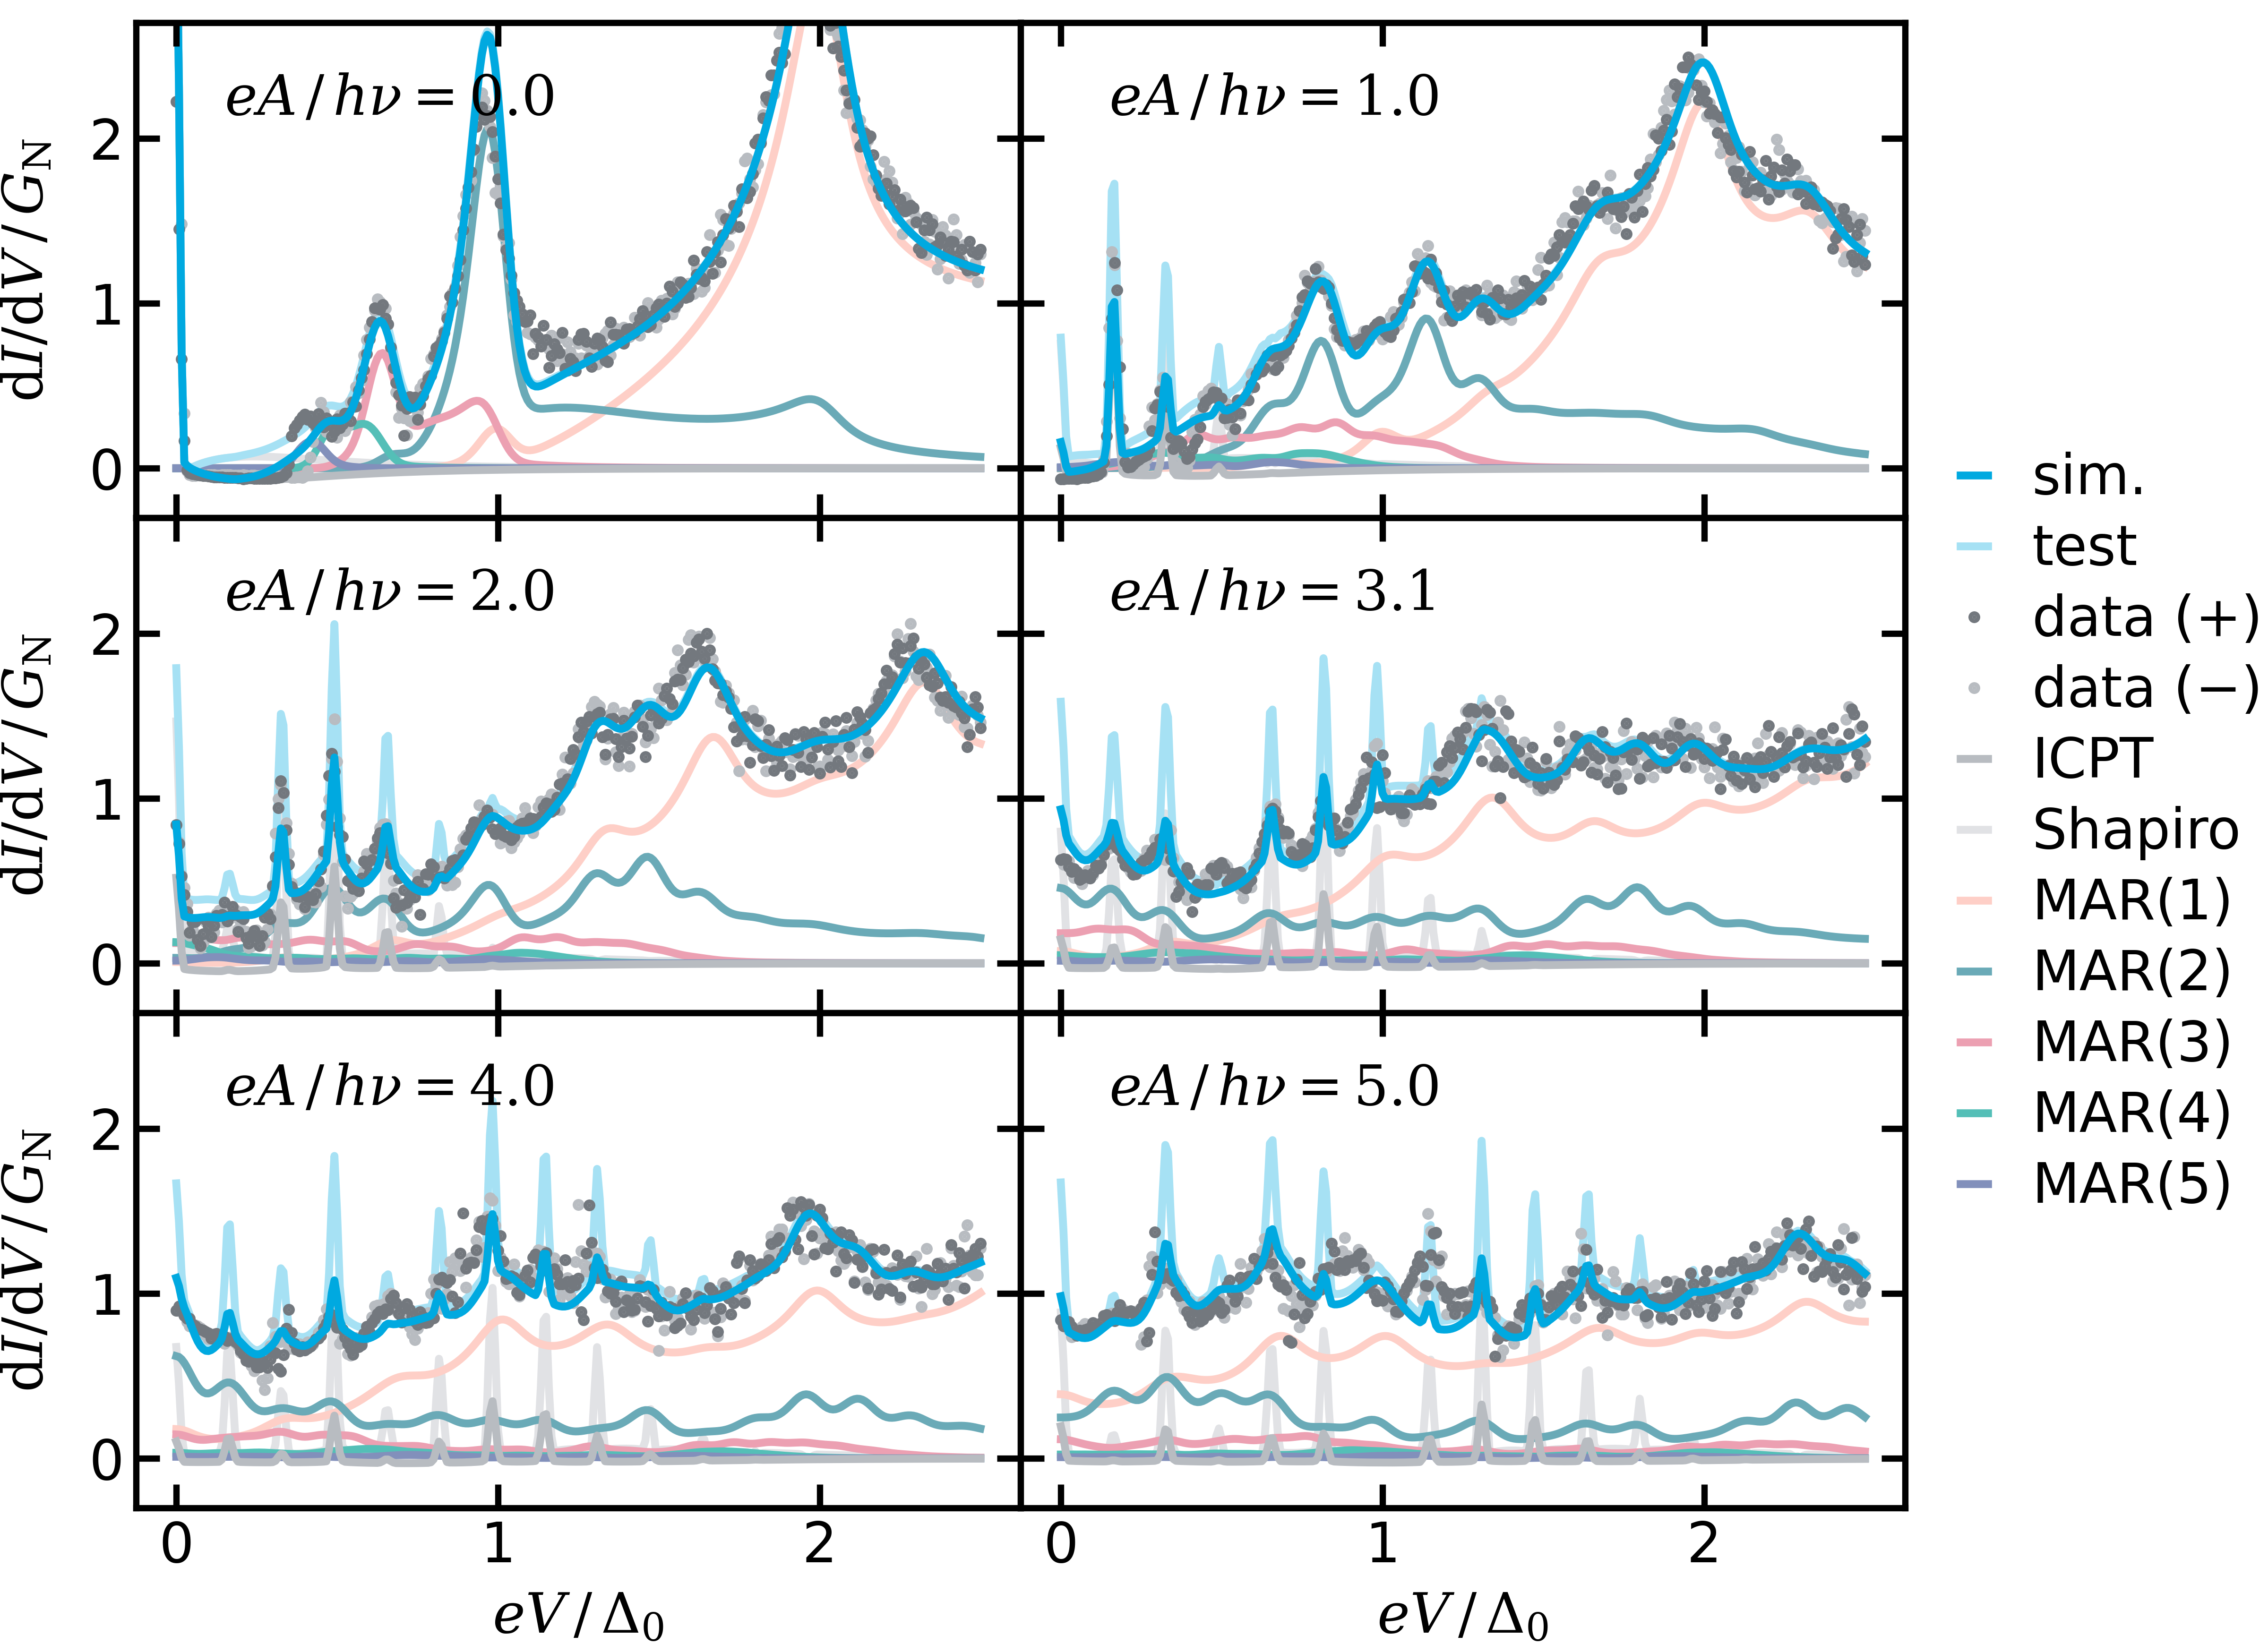

In [401]:
# dIdV(V)
import superconductivity as sc

path = "1.8G0/15.0GHz_stripline"
data_sim = np.load(f"{path}/sim.npz")

Vbias0 = data_sim["Vbias0"]
Abias = data_sim["Abias"]

dGexp0 = data_sim["dGexp0"]
dGpamar0 = data_sim["dGpamar0"]
dGpamarm0 = data_sim["dGpamarm0"]
dGicpt0 = data_sim["dGicpt0"]
dGsp0 = data_sim["dGsp0"]

fig, axes = sc.get_figures(
    figsize=(4.0, 2.9),
    padding=(0.2, 0.2, 0.6, 0.0),
    nrows=3,
    ncols=2,
)

V0 = np.linspace(0, 2.5, 301)
V1 = np.linspace(0, 2.5, 301)

Ainterest = np.arange(6)
m = np.arange(5)

for i, abias in enumerate(Ainterest):
    index = np.argmin(np.abs(Abias - abias))
    mask = np.isfinite(dGexp0[index, :])
    dGexp_pos = sc.bin_y_over_x(
        upsample(dGexp0[index, mask]), upsample(Vbias0[mask]), V0
    )
    dGexp_neg = sc.bin_y_over_x(
        np.flip(upsample(dGexp0[index, mask])), upsample(Vbias0[mask]), V0
    )
    dGpamar = sc.bin_y_over_x(upsample(dGpamar0[index, :]), upsample(Vbias0), V1)
    dGicpt = sc.bin_y_over_x(upsample(dGicpt0[index, :]), upsample(Vbias0), V1)
    dGsp = sc.bin_y_over_x(upsample(dGsp0[index, :]), upsample(Vbias0), V1)
    dGpamarm = sc.bin_y_over_x(upsample(dGpamarm0[:, index, :]), upsample(Vbias0), V1)

    axes[i].plot(V1, dGpamar + dGicpt, "-", color=sc.seeblau100, label="sim.", zorder=1)
    axes[i].plot(V1, dGpamar + dGsp, "-", color=sc.seeblau35, label="test", zorder=-1)
    axes[i].plot(V0, dGexp_pos, ".", color=sc.seegrau100, label="data ($+$)", zorder=0)
    axes[i].plot(V0, dGexp_neg, ".", color=sc.seegrau35, label="data ($-$)", zorder=-1)
    axes[i].plot(
        V1,
        dGicpt,
        "-",
        color=sc.get_color(palette=color_strings[0], shade=3),
        label="ICPT",
        zorder=-2,
    )
    axes[i].plot(
        V1,
        dGsp,
        "-",
        color=sc.get_color(palette=color_strings[0], shade=4),
        label="Shapiro",
        zorder=-7,
    )
    for i_m in m:
        axes[i].plot(
            V1,
            dGpamarm[i_m, :],
            zorder=-5,
            color=sc.get_color(palette=color_strings[i_m + 2], shade=3),
            label=f"MAR({i_m+1})",
        )
    axes[i].text(
        0.1,
        0.9,
        f"$eA\\,/\\,h\\nu ={Abias[index]:.2}$",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
        size=7,
    )
    axes[i].set_ylim(-0.3, 2.7)

axes[3].legend(
    handlelength=0.5,
    loc="upper left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.025, 1.2),
)

sc.daumenkino_layout(
    fig,
    axes,
    title=f"atomic_contact/{path}/didv-cuts/voltage-cuts",
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
    # xticks=[0, 1, 2],
    # yticks=[0, 1, 2, 3],
)
plt.show()

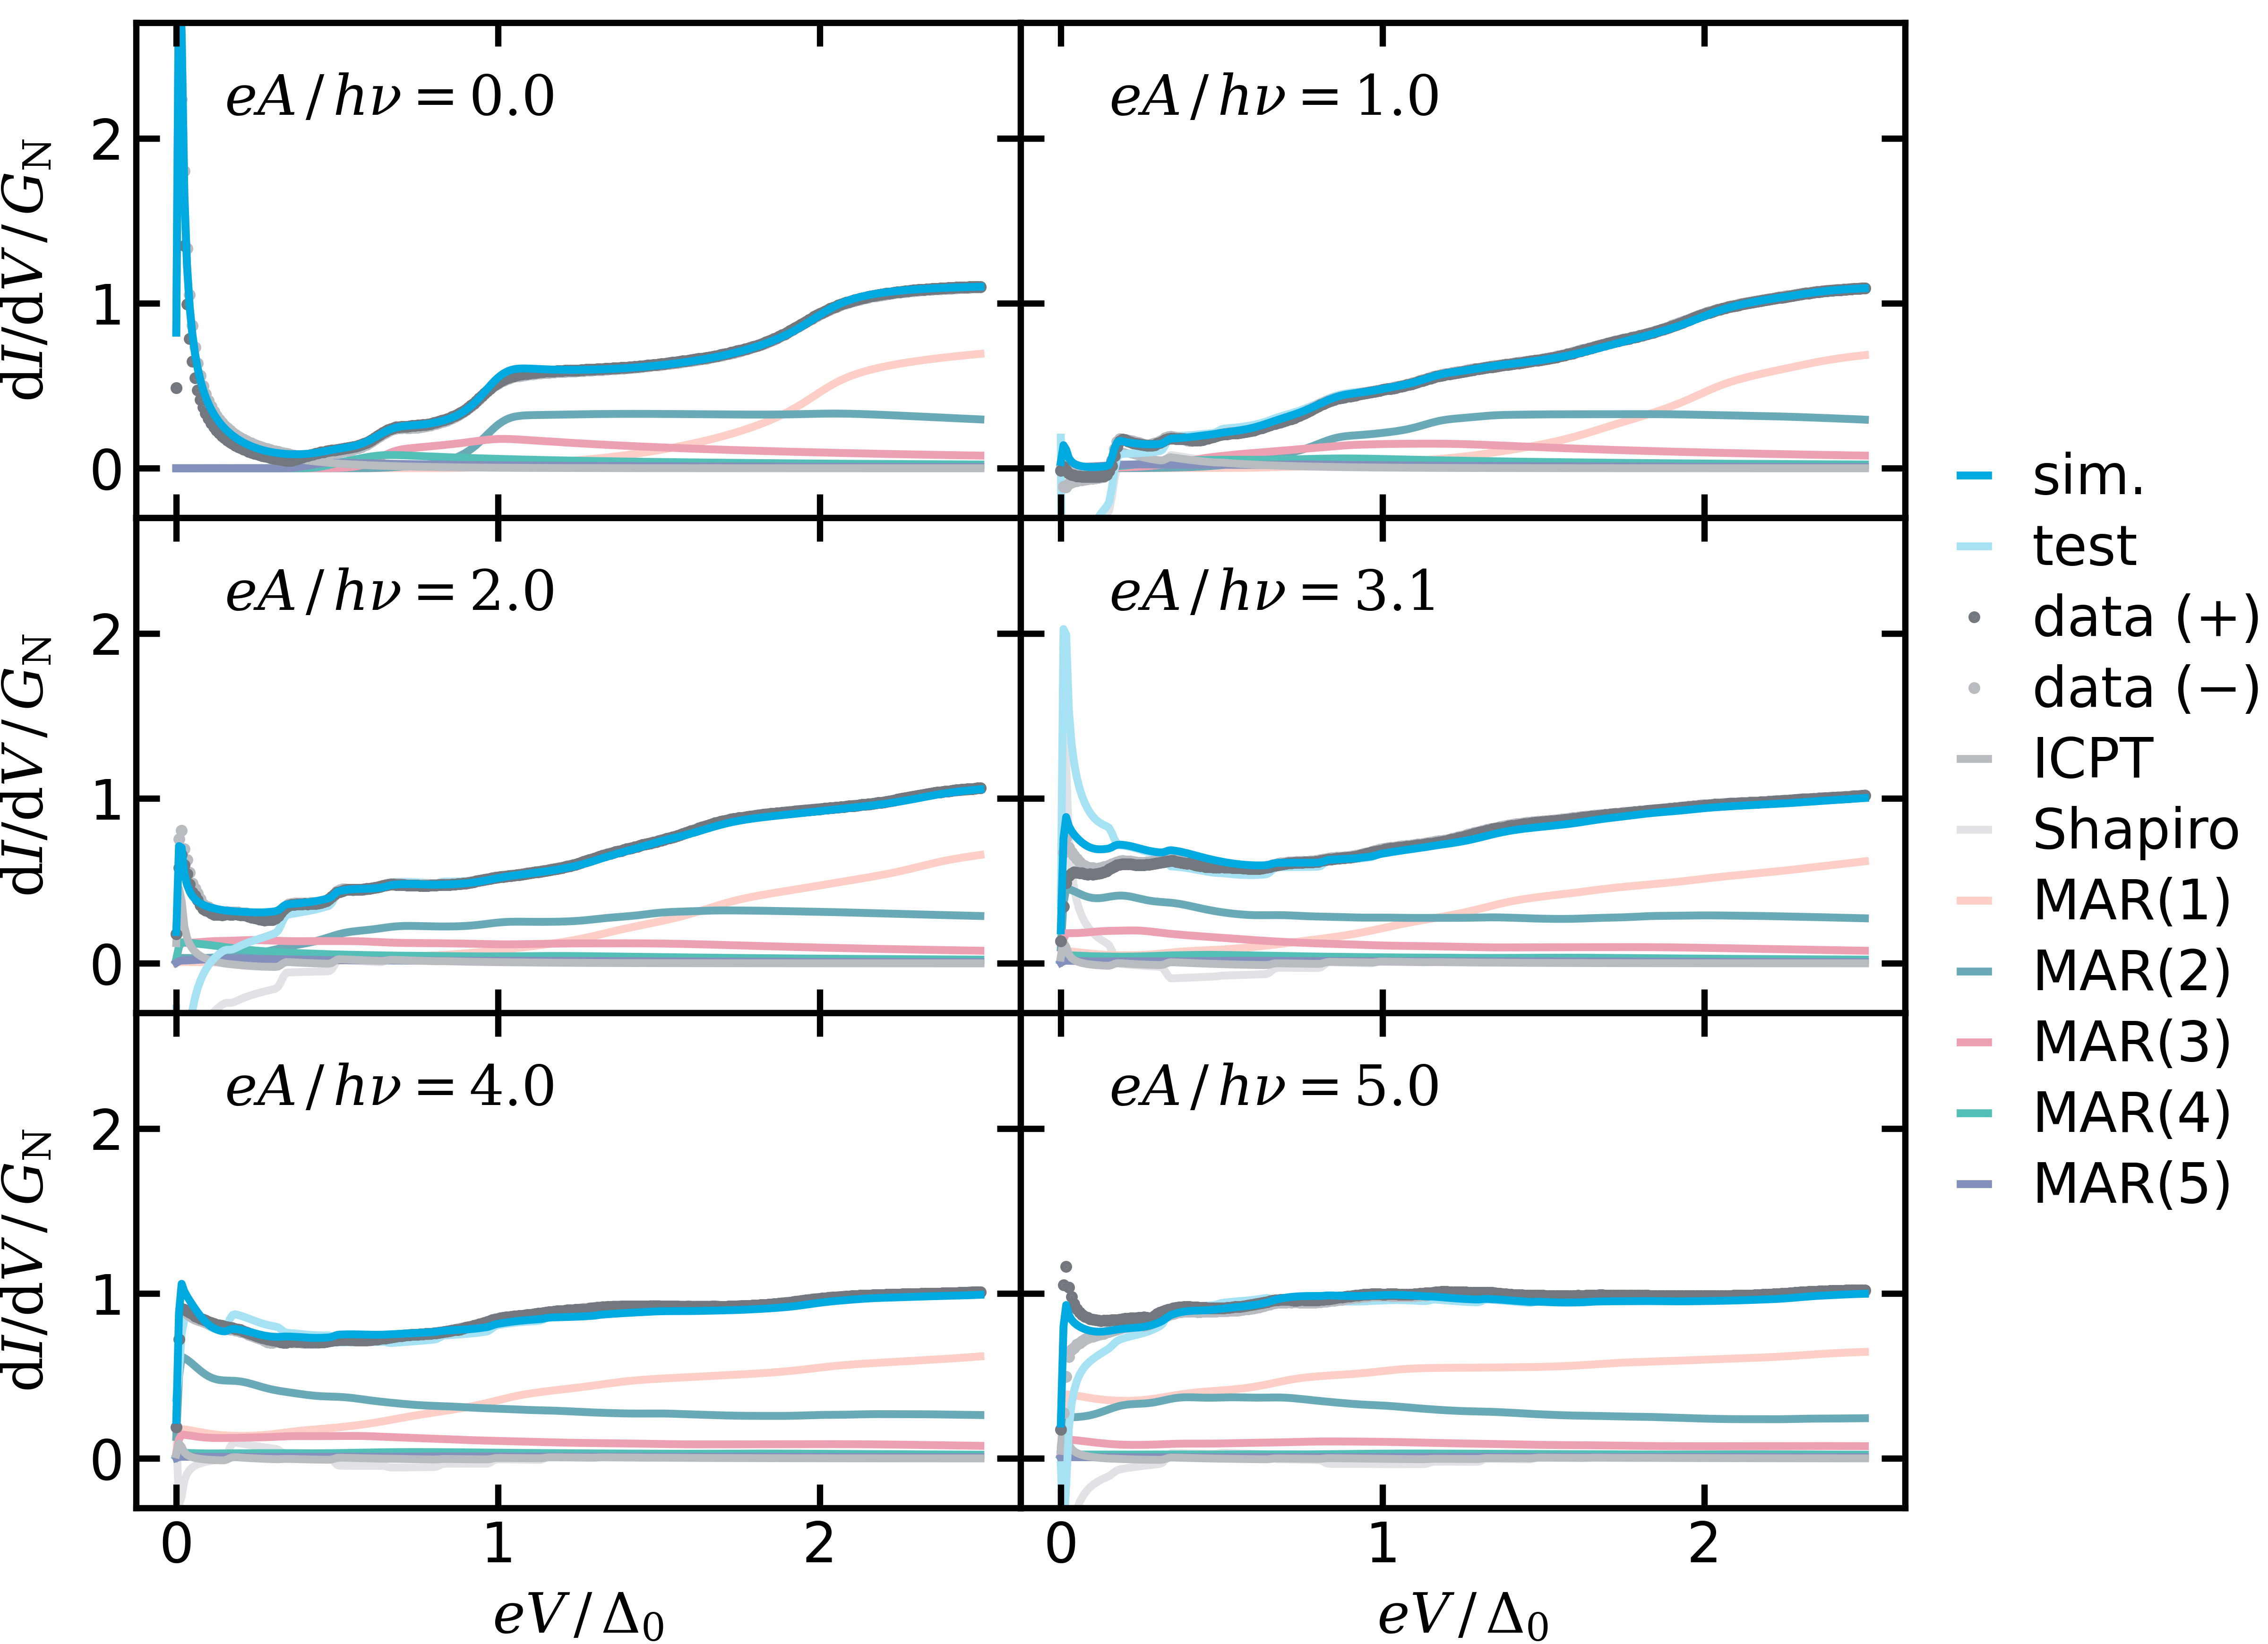

In [402]:
# I/V(V)
import superconductivity as sc

path = "1.8G0/15.0GHz_stripline"
data_sim = np.load(f"{path}/sim.npz")

Vbias0 = data_sim["Vbias0"]
Abias = data_sim["Abias"]

dGexp0 = data_sim["Iexp0"]
dGpamar0 = data_sim["Ipamar0"]
dGpamarm0 = data_sim["Ipamarm0"]
dGicpt0 = data_sim["Iicpt0"]
dGsp0 = data_sim["Isp0"]

dGexp0 = np.divide(dGexp0, Vbias0, where=Vbias0 != 0.0, out=np.zeros_like(dGexp0))
dGpamar0 = np.divide(dGpamar0, Vbias0, where=Vbias0 != 0.0, out=np.zeros_like(dGpamar0))
dGpamarm0 = np.divide(
    dGpamarm0, Vbias0, where=Vbias0 != 0.0, out=np.zeros_like(dGpamarm0)
)
dGicpt0 = np.divide(dGicpt0, Vbias0, where=Vbias0 != 0.0, out=np.zeros_like(dGicpt0))
dGsp0 = np.divide(dGsp0, Vbias0, where=Vbias0 != 0.0, out=np.zeros_like(dGsp0))

fig, axes = sc.get_figures(
    figsize=(4.0, 2.9),
    padding=(0.2, 0.2, 0.6, 0.0),
    nrows=3,
    ncols=2,
)

V0 = np.linspace(0, 2.5, 301)
V1 = np.linspace(0, 2.5, 301)

Ainterest = np.arange(6)
m = np.arange(5)

for i, abias in enumerate(Ainterest):
    index = np.argmin(np.abs(Abias - abias))
    mask = np.isfinite(dGexp0[index, :])
    dGexp_pos = sc.bin_y_over_x(
        upsample(dGexp0[index, mask]), upsample(Vbias0[mask]), V0
    )
    dGexp_neg = sc.bin_y_over_x(
        np.flip(upsample(dGexp0[index, mask])), upsample(Vbias0[mask]), V0
    )
    dGpamar = sc.bin_y_over_x(upsample(dGpamar0[index, :]), upsample(Vbias0), V1)
    dGicpt = sc.bin_y_over_x(upsample(dGicpt0[index, :]), upsample(Vbias0), V1)
    dGsp = sc.bin_y_over_x(upsample(dGsp0[index, :]), upsample(Vbias0), V1)
    dGpamarm = sc.bin_y_over_x(upsample(dGpamarm0[:, index, :]), upsample(Vbias0), V1)

    axes[i].plot(V1, dGpamar + dGicpt, "-", color=sc.seeblau100, label="sim.", zorder=1)
    axes[i].plot(V1, dGpamar + dGsp, "-", color=sc.seeblau35, label="test", zorder=-1)
    axes[i].plot(V0, dGexp_pos, ".", color=sc.seegrau100, label="data ($+$)", zorder=0)
    axes[i].plot(V0, dGexp_neg, ".", color=sc.seegrau35, label="data ($-$)", zorder=-1)
    axes[i].plot(
        V1,
        dGicpt,
        "-",
        color=sc.get_color(palette=color_strings[0], shade=3),
        label="ICPT",
        zorder=-2,
    )
    axes[i].plot(
        V1,
        dGsp,
        "-",
        color=sc.get_color(palette=color_strings[0], shade=4),
        label="Shapiro",
        zorder=-7,
    )
    for i_m in m:
        axes[i].plot(
            V1,
            dGpamarm[i_m, :],
            zorder=-5,
            color=sc.get_color(palette=color_strings[i_m + 2], shade=3),
            label=f"MAR({i_m+1})",
        )
    axes[i].text(
        0.1,
        0.9,
        f"$eA\\,/\\,h\\nu ={Abias[index]:.2}$",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
        size=7,
    )
    axes[i].set_ylim(-0.3, 2.7)

axes[3].legend(
    handlelength=0.5,
    loc="upper left",
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(1.025, 1.2),
)

sc.daumenkino_layout(
    fig,
    axes,
    title=f"atomic_contact/{path}/didv-cuts/current-cuts",
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
    # xticks=[0, 1, 2],
    # yticks=[0, 1, 2, 3],
)
plt.show()

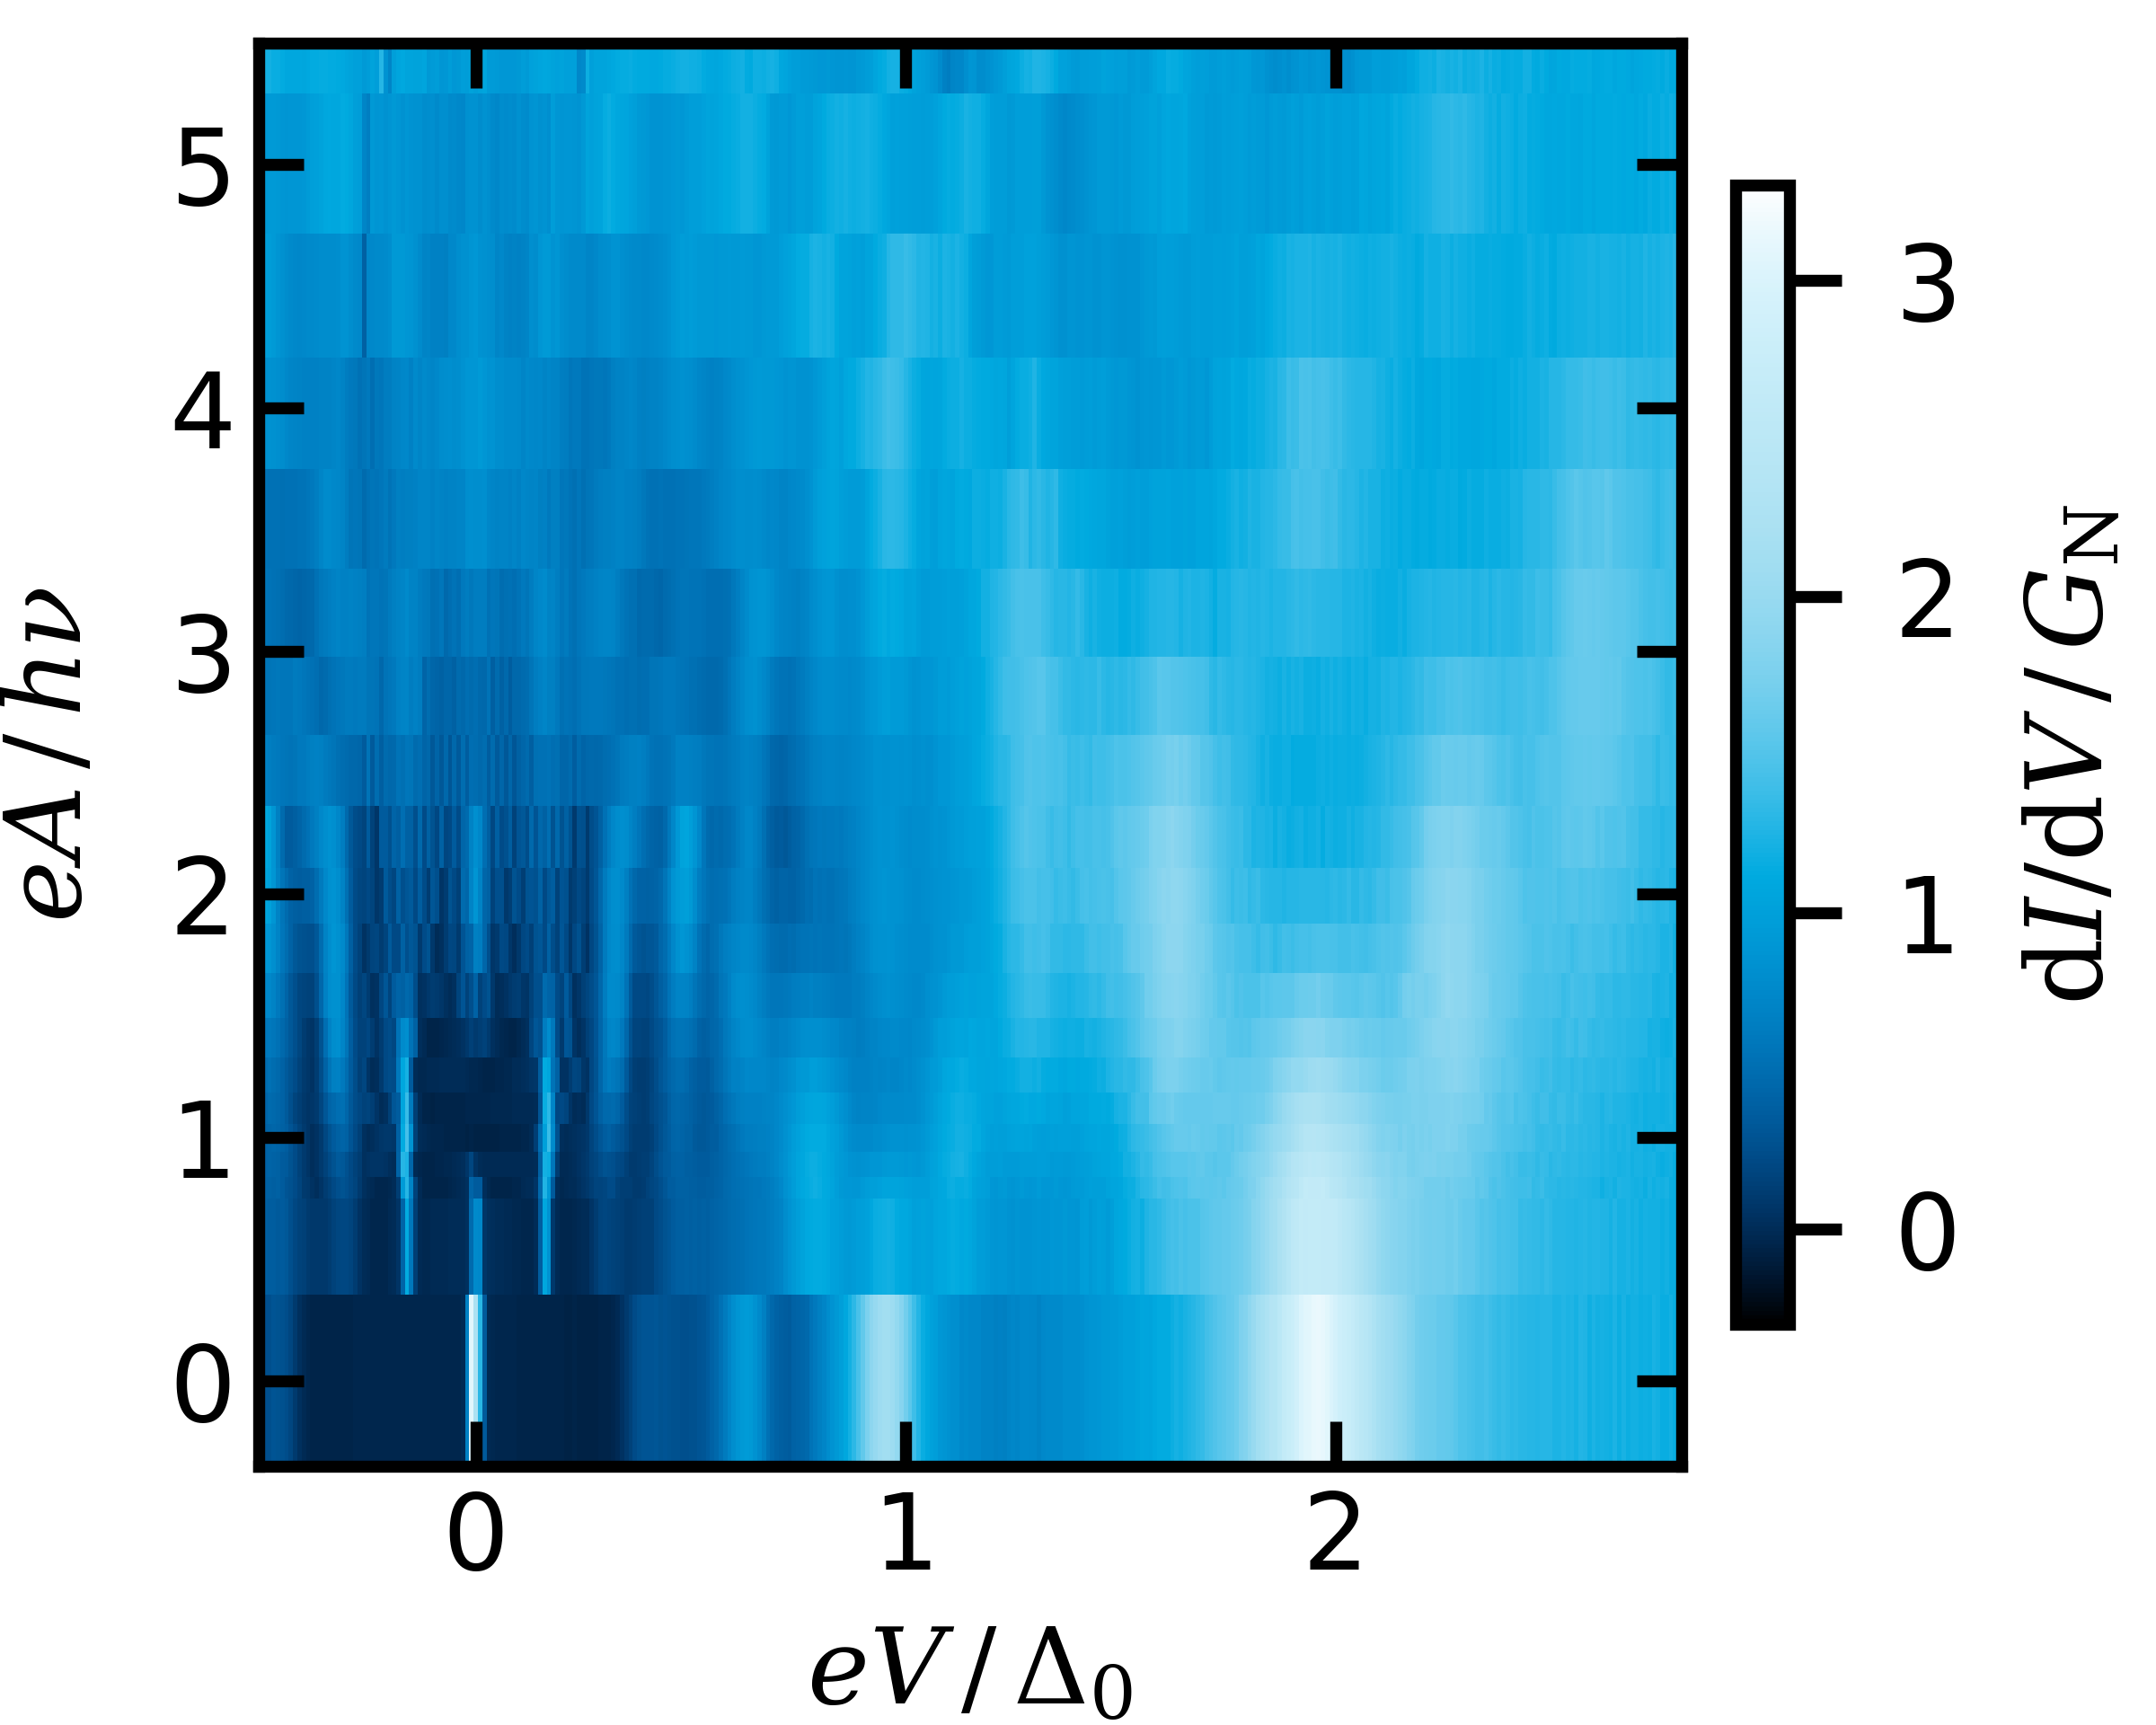

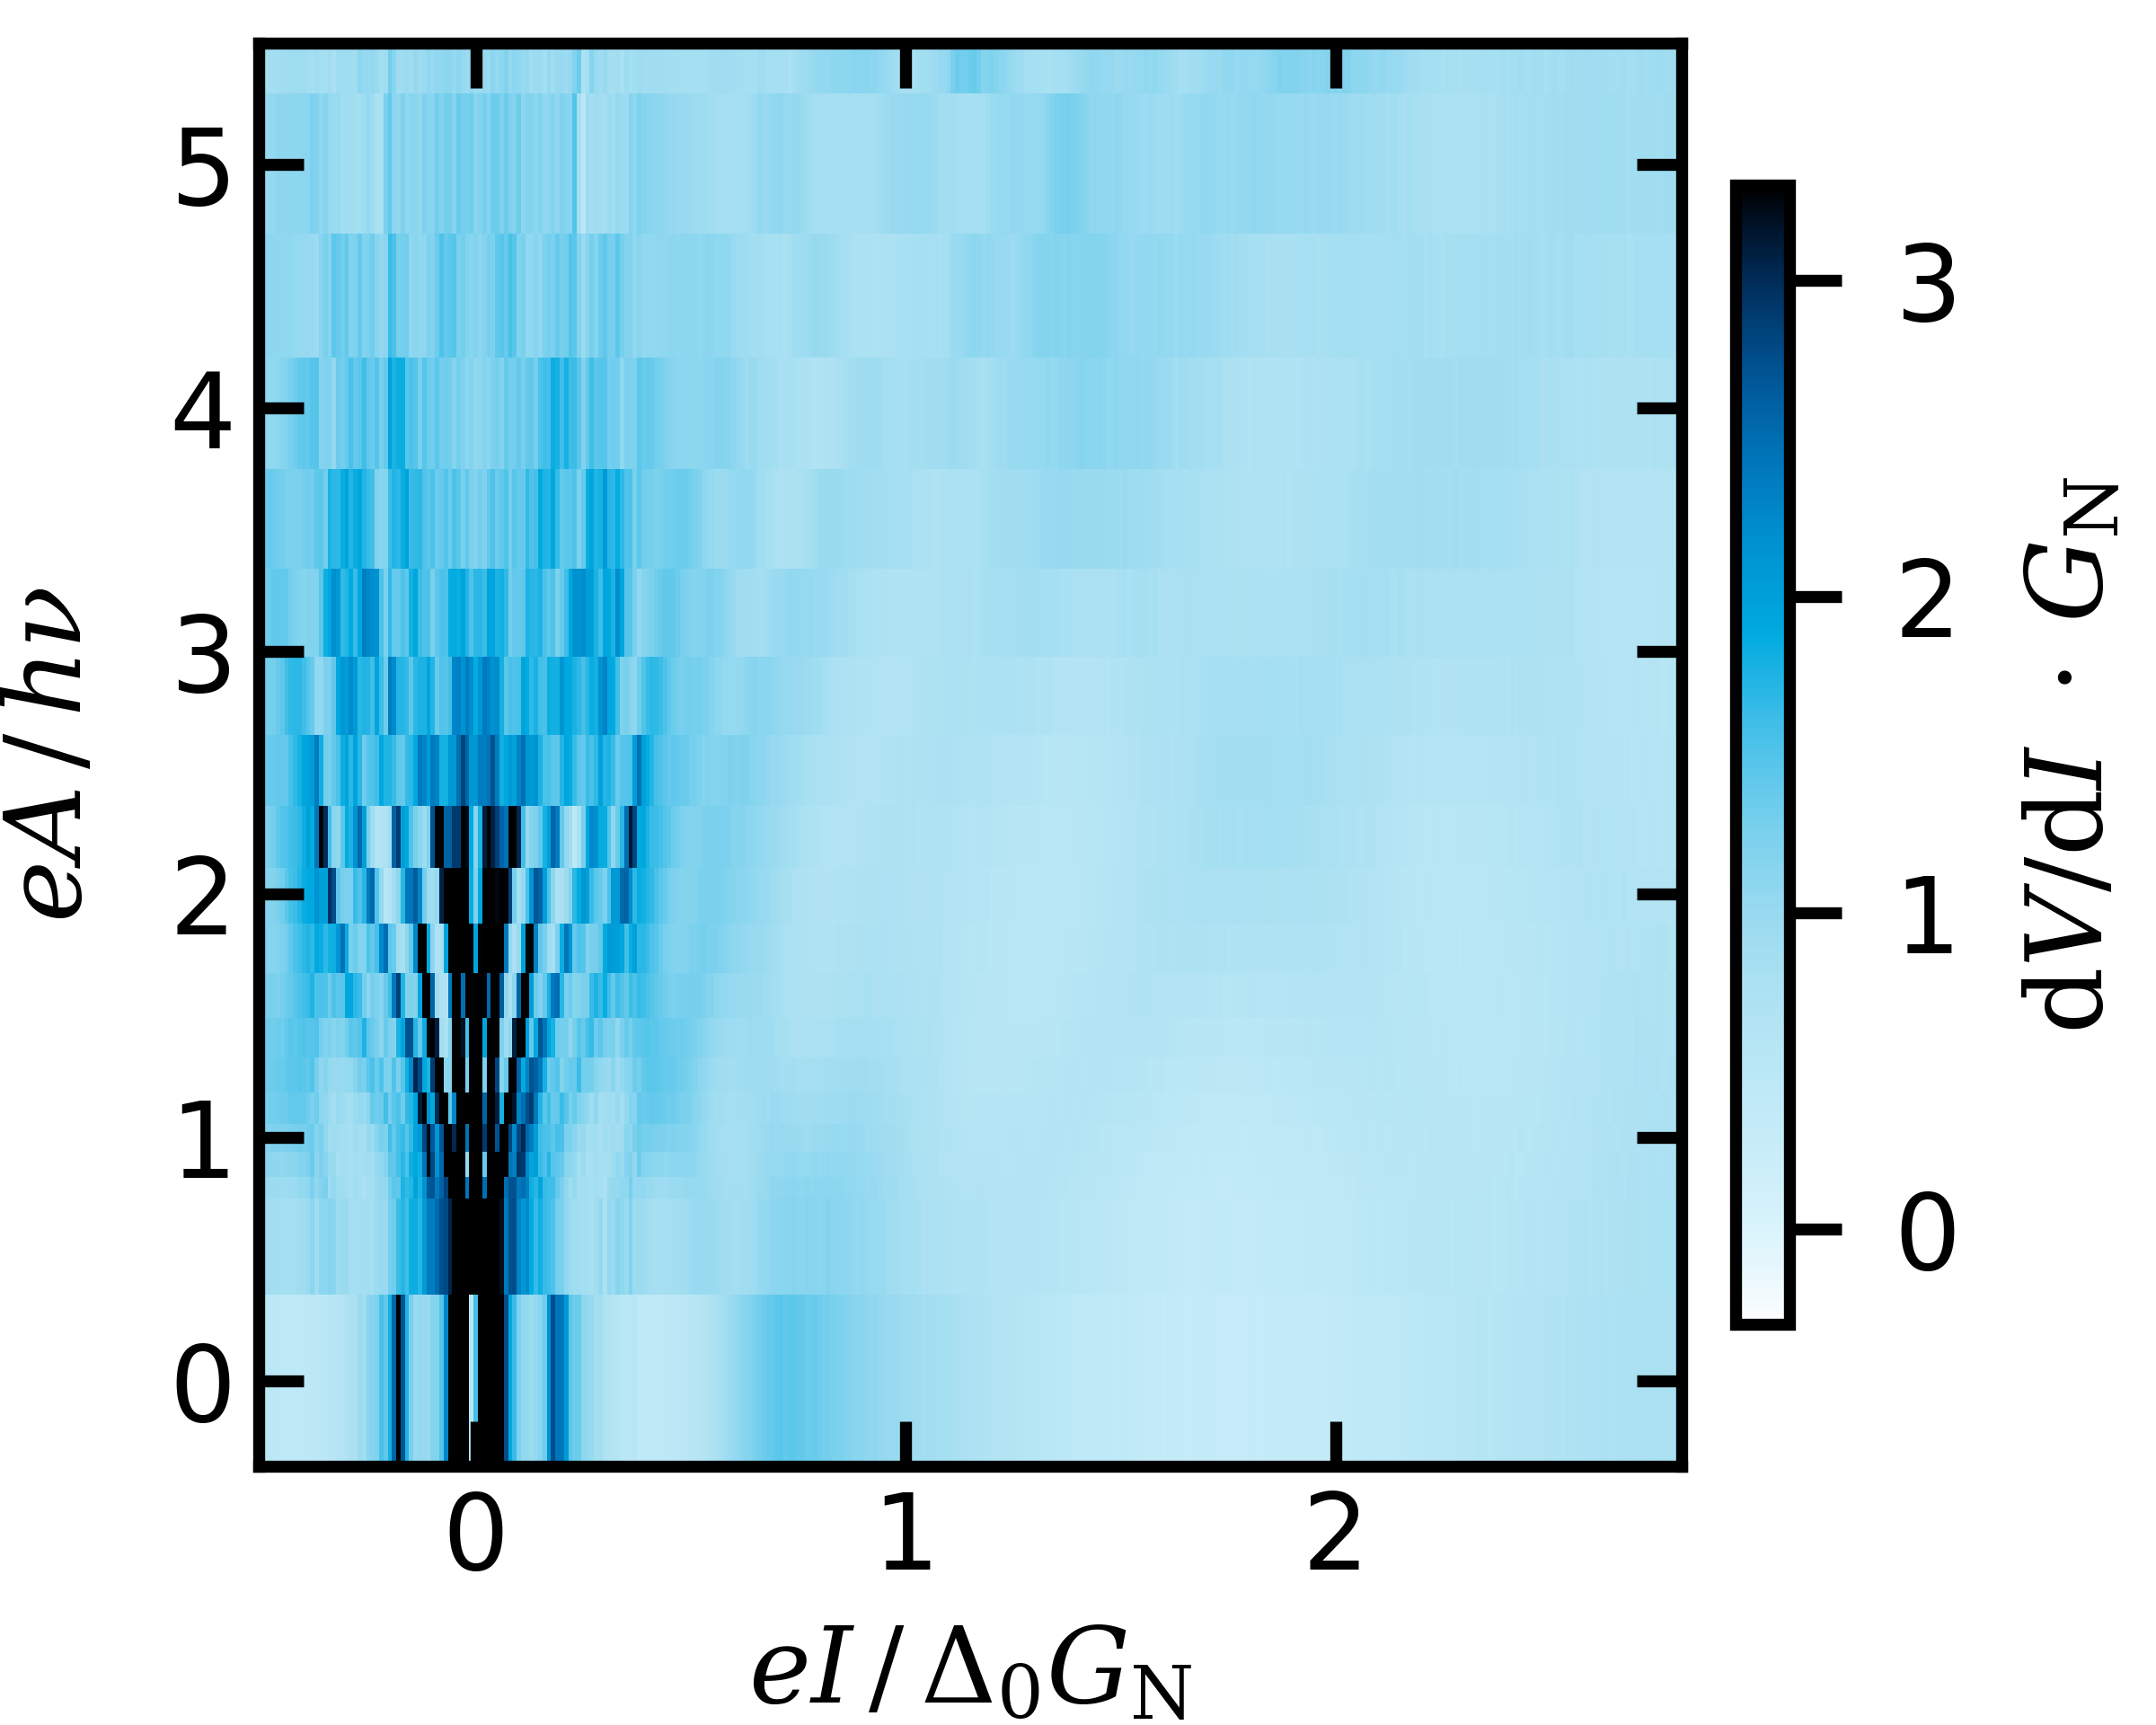

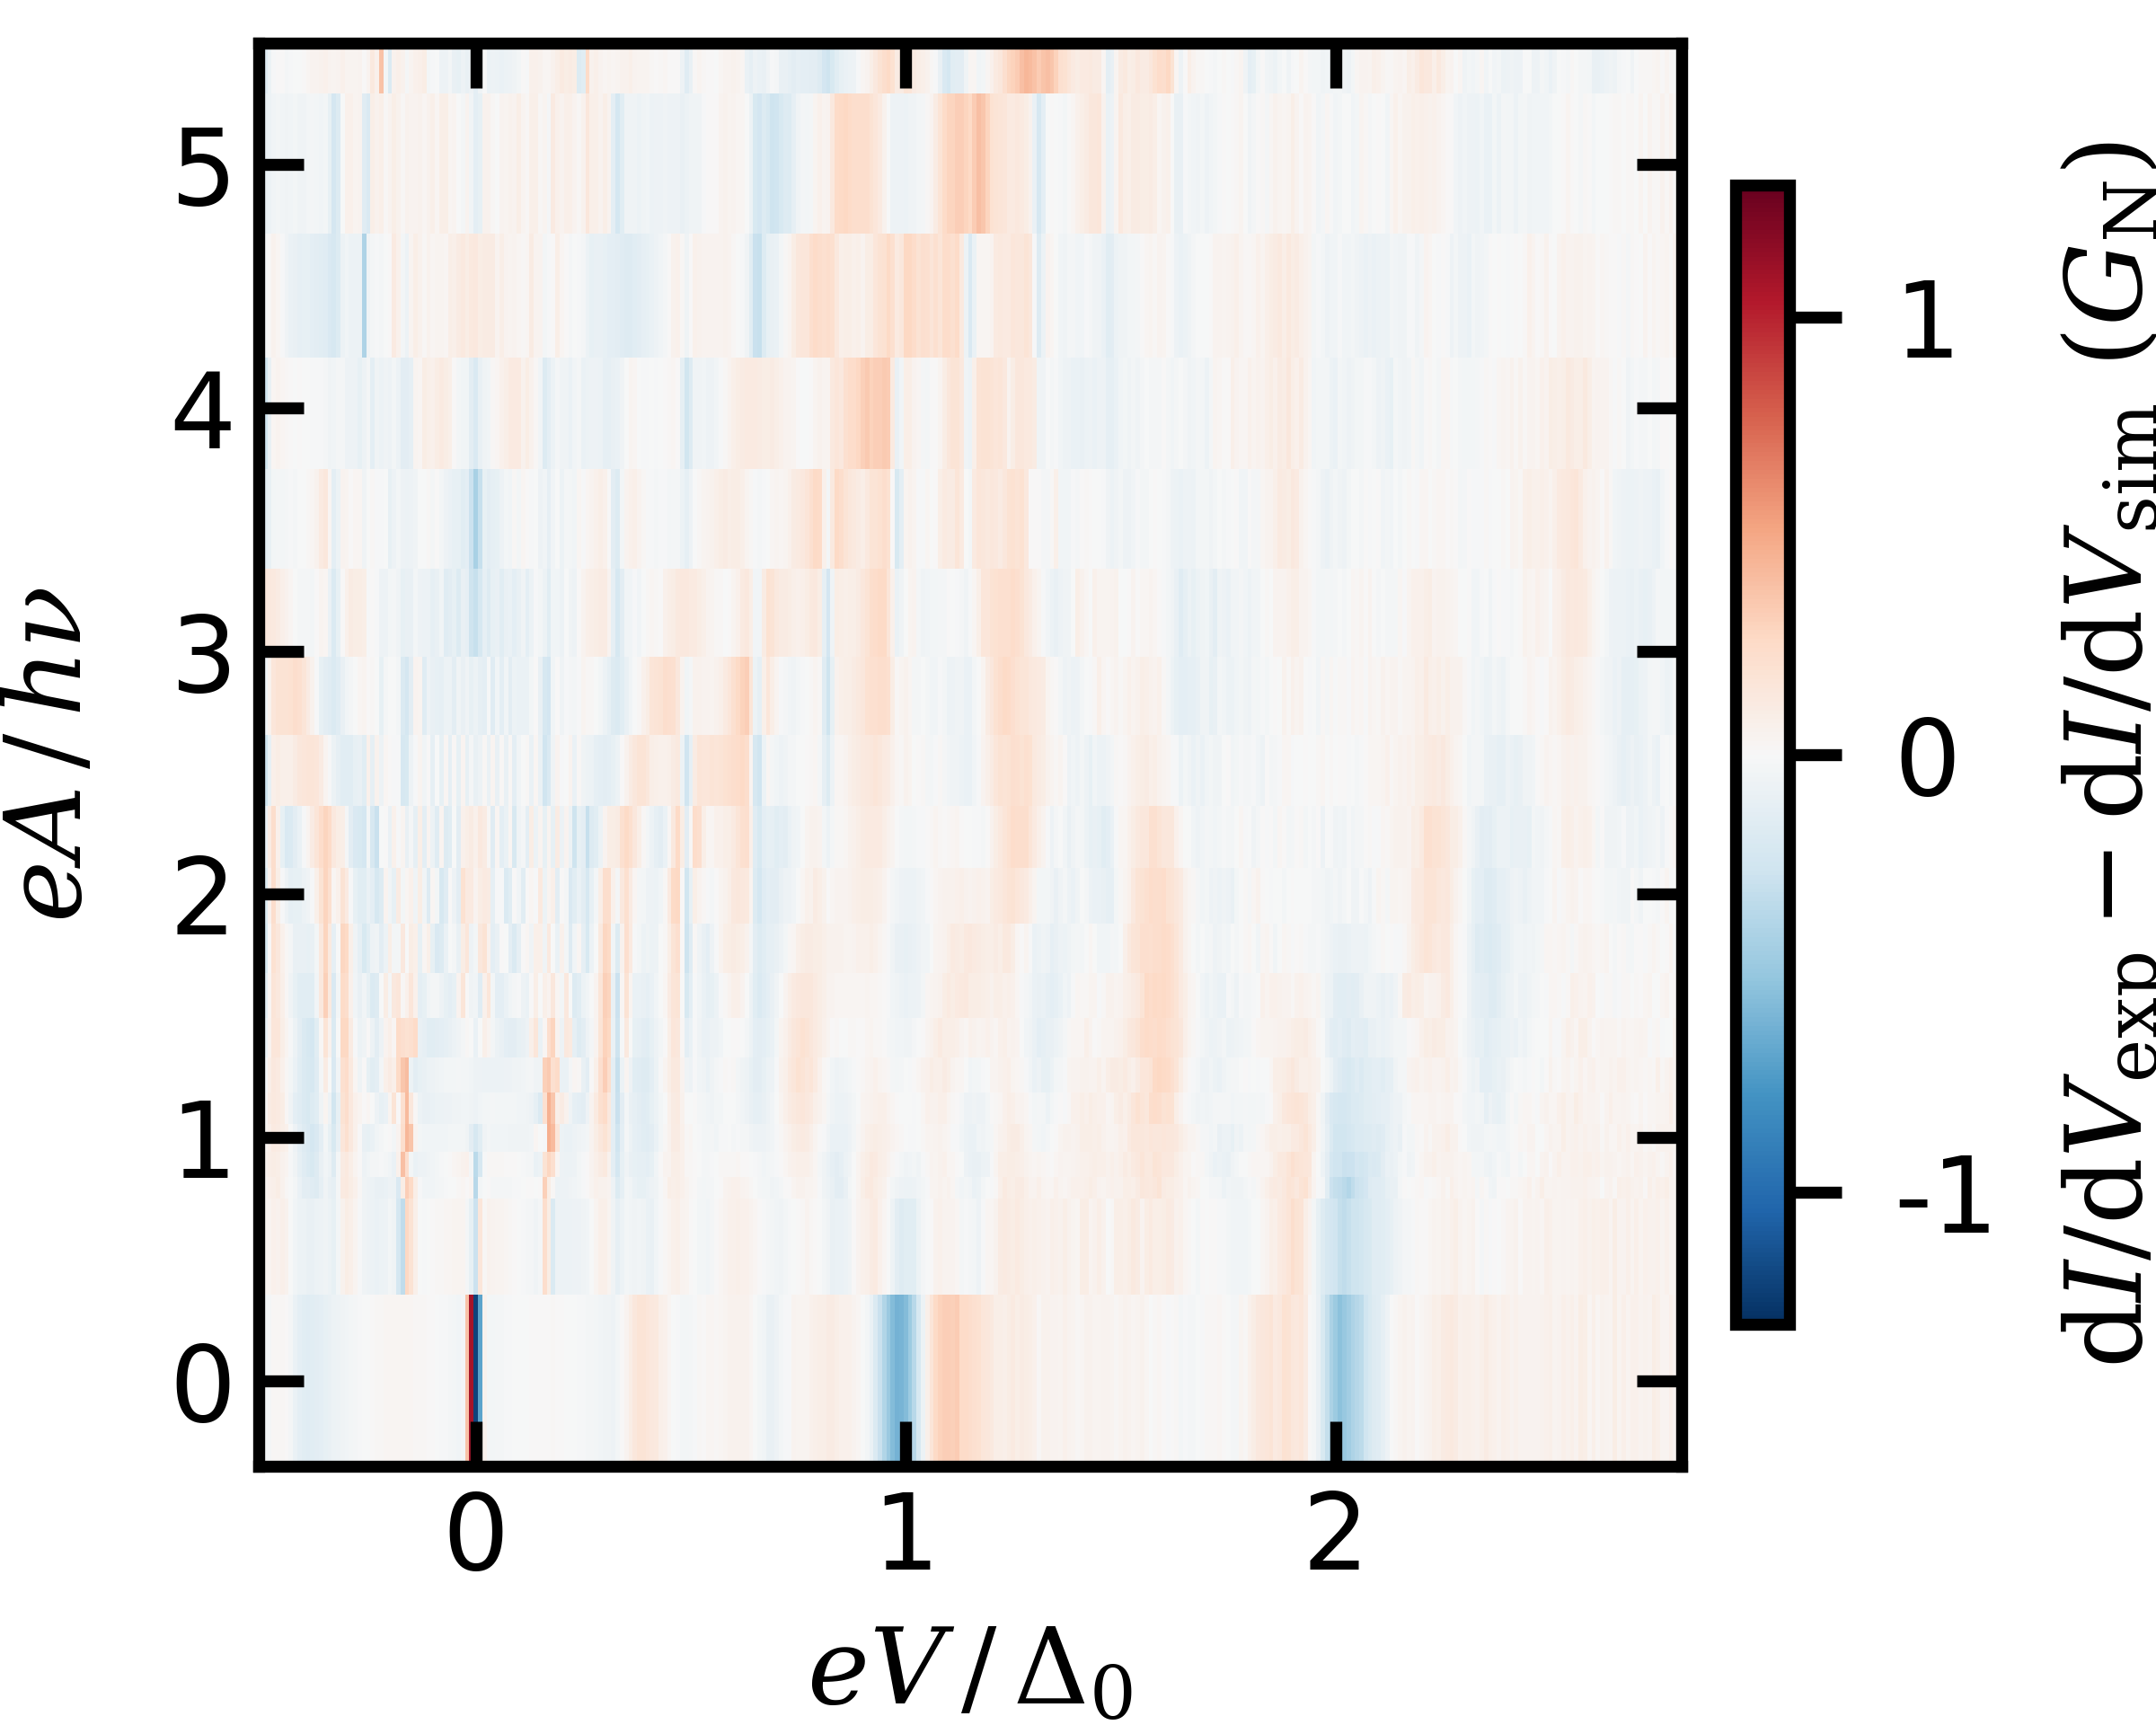

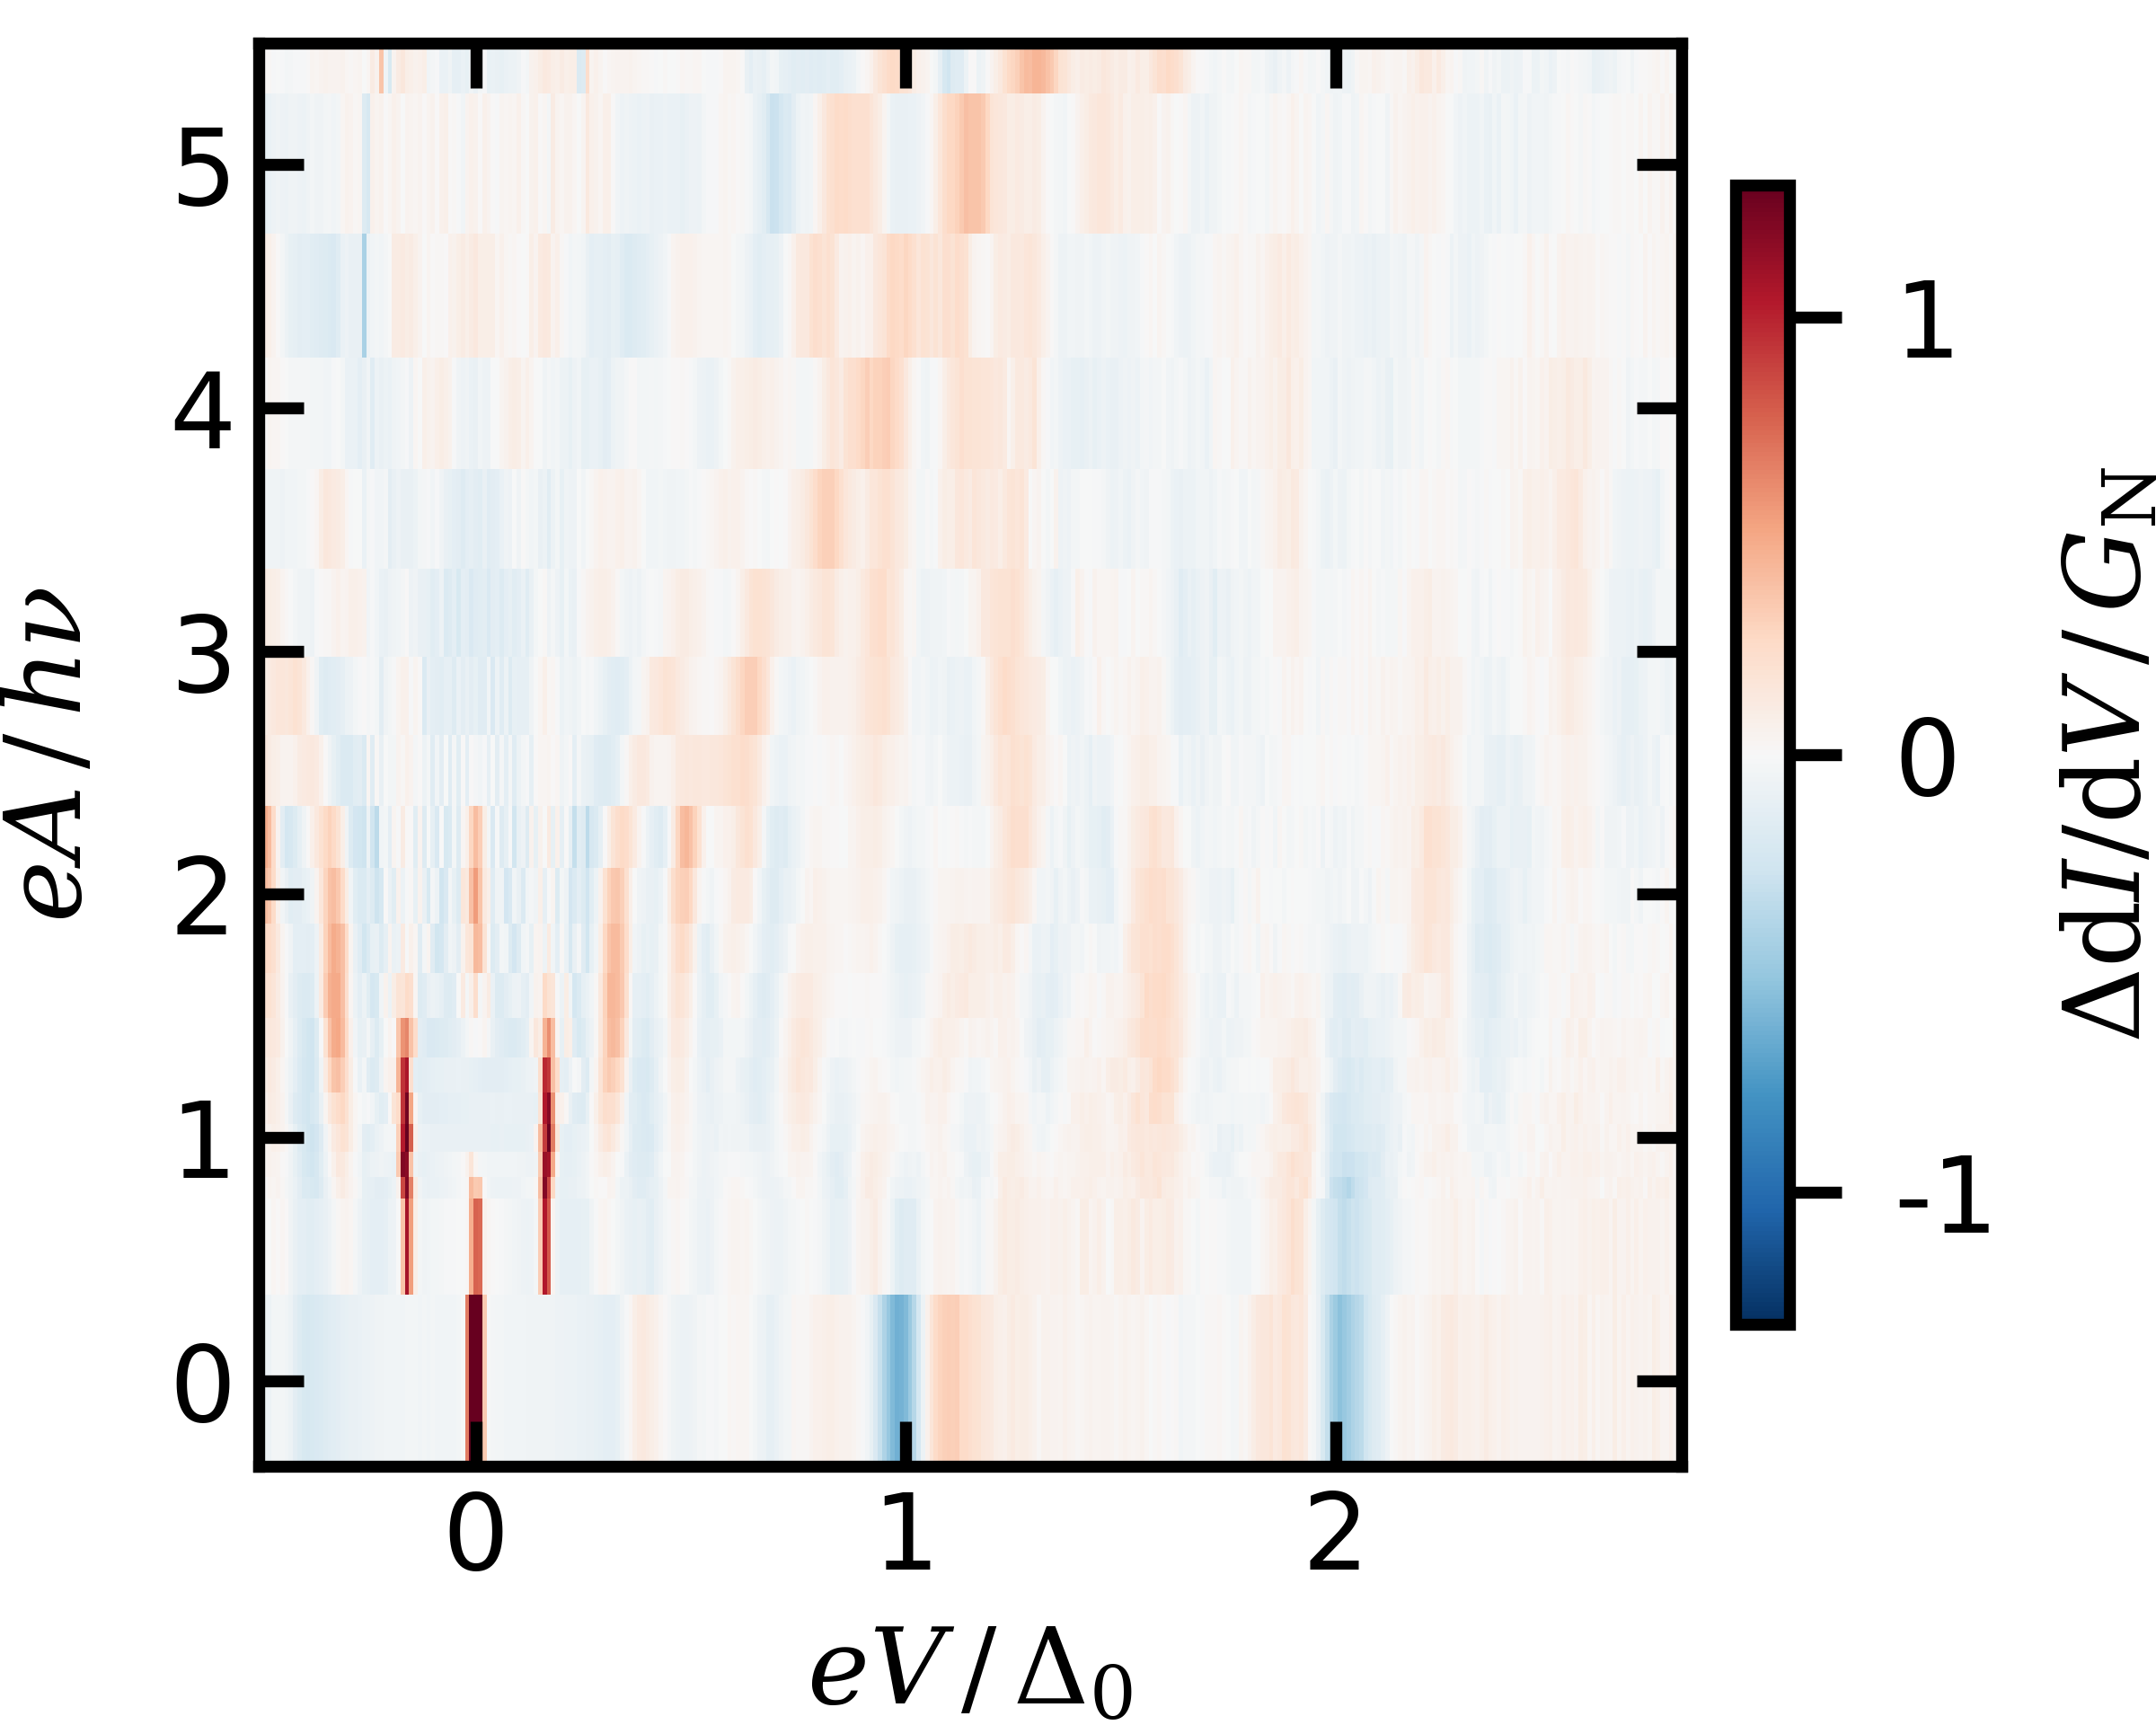

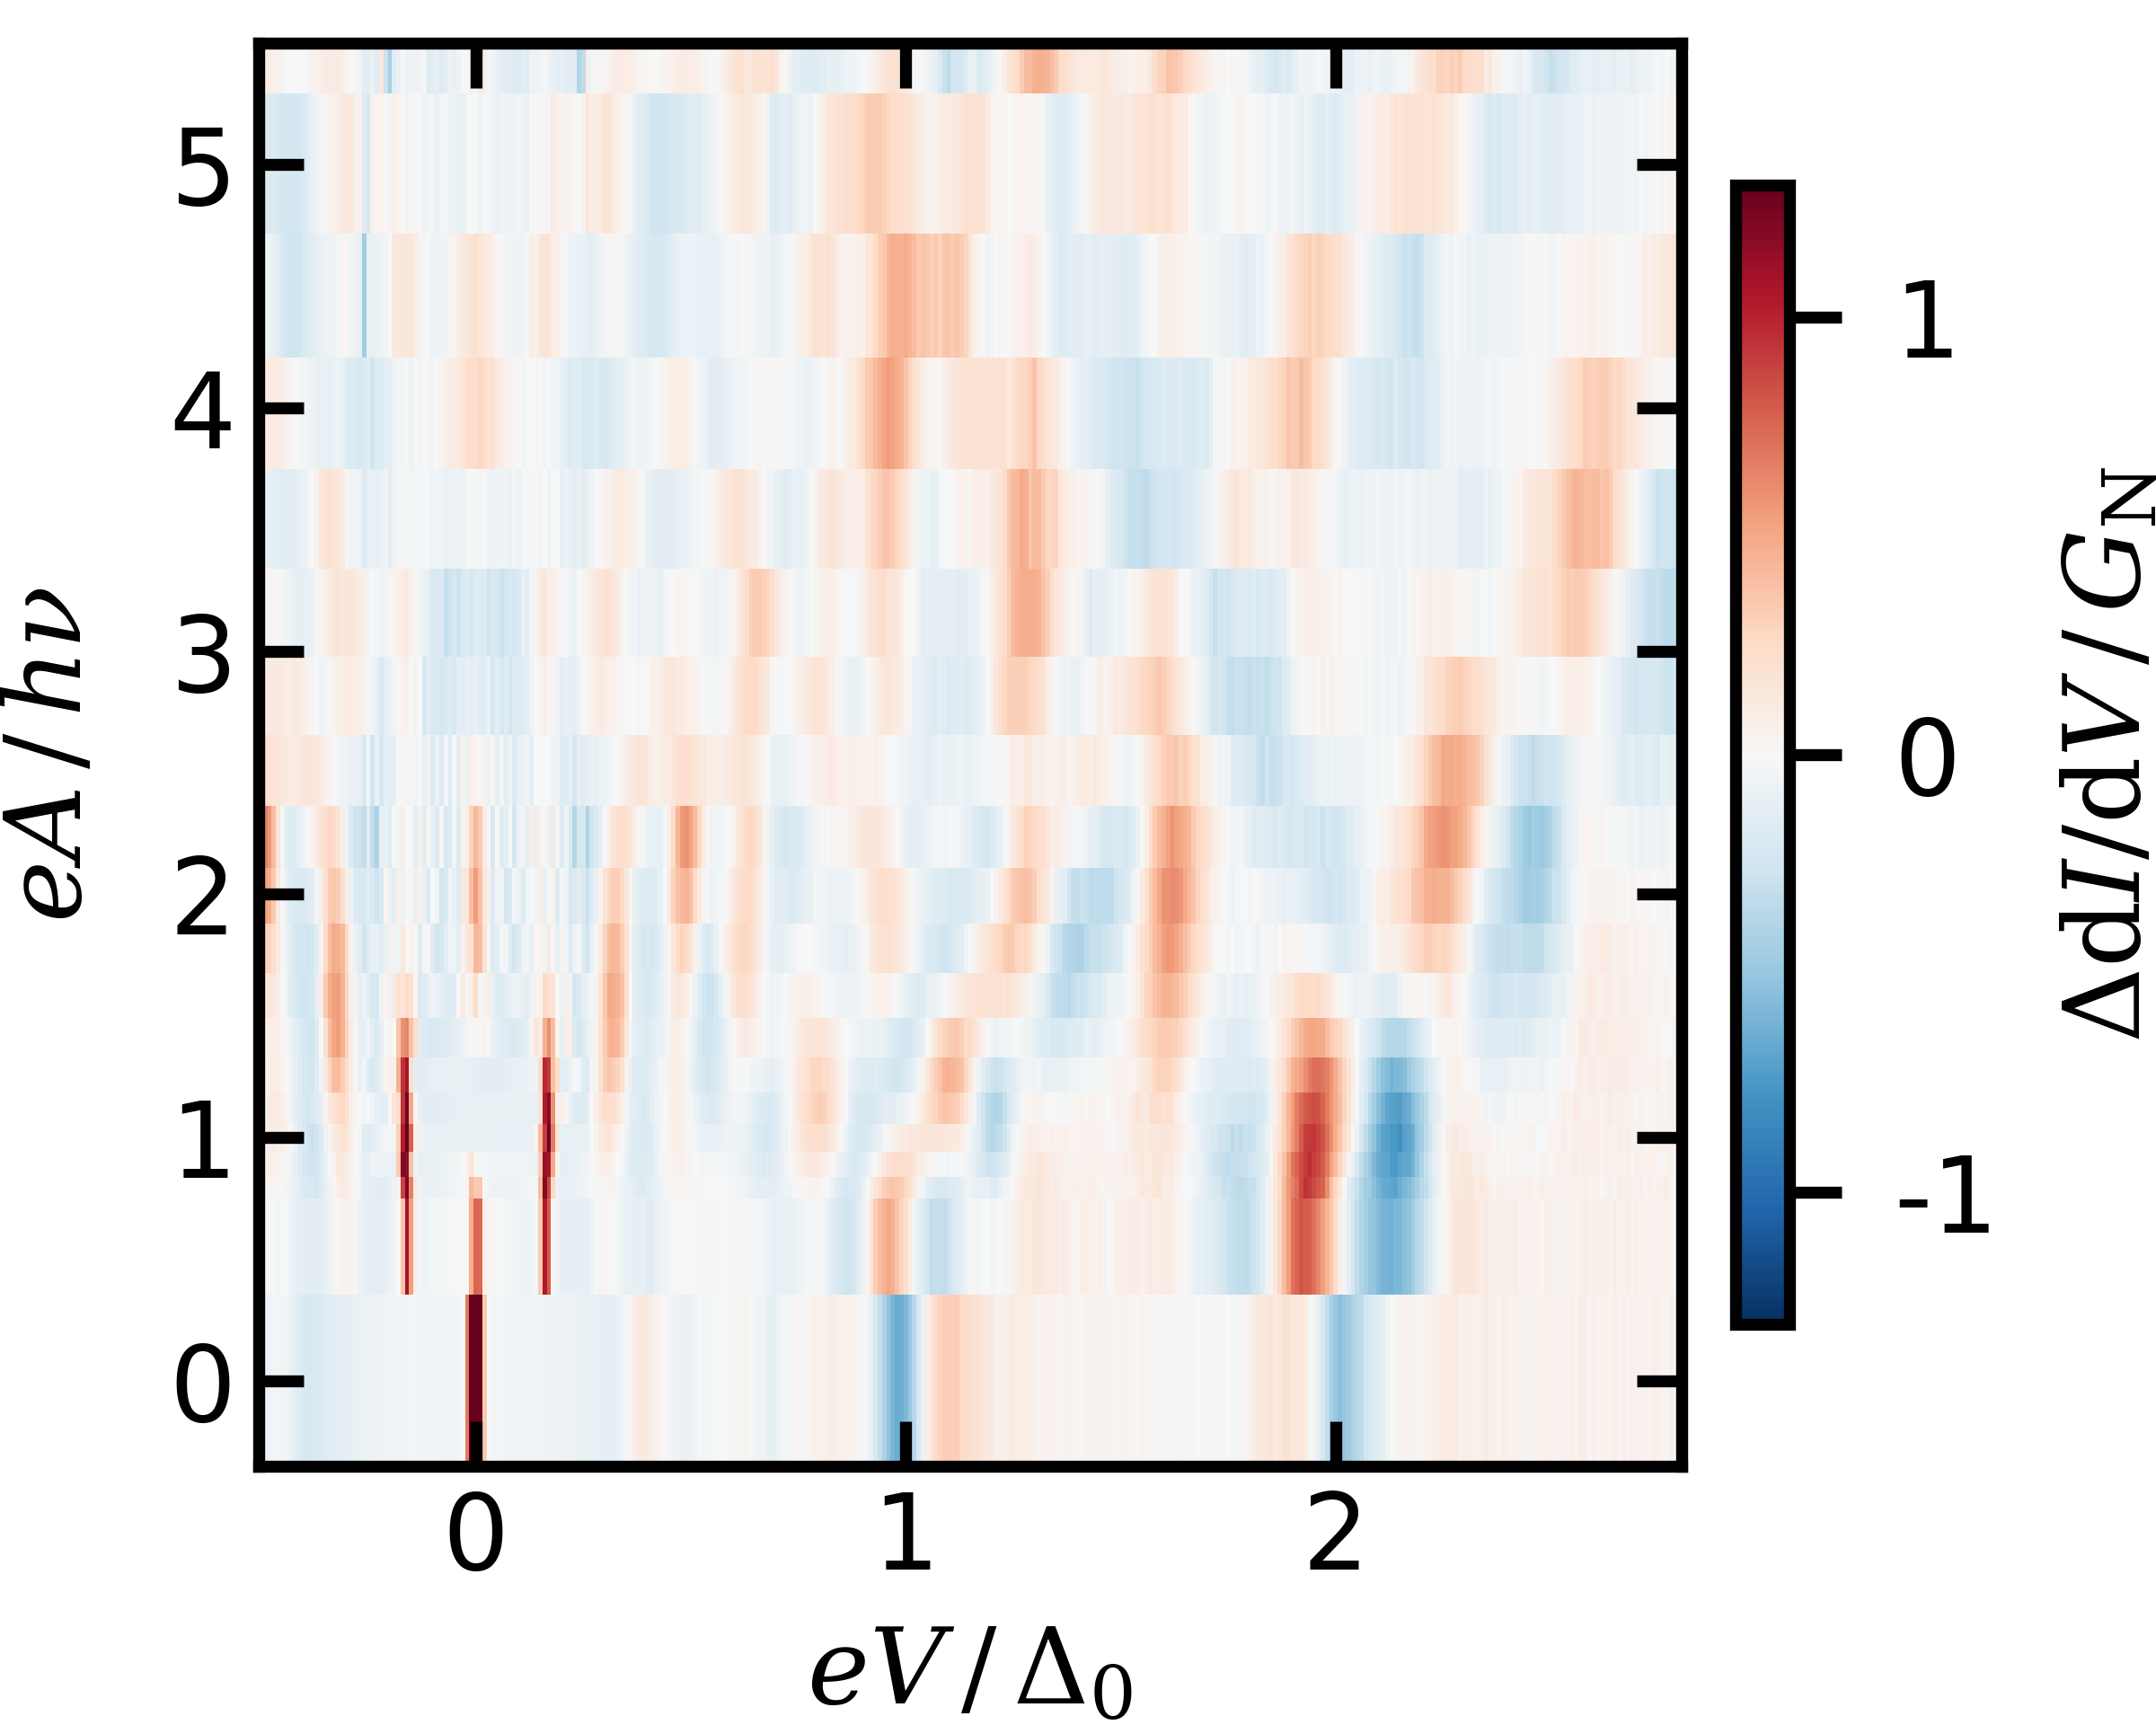

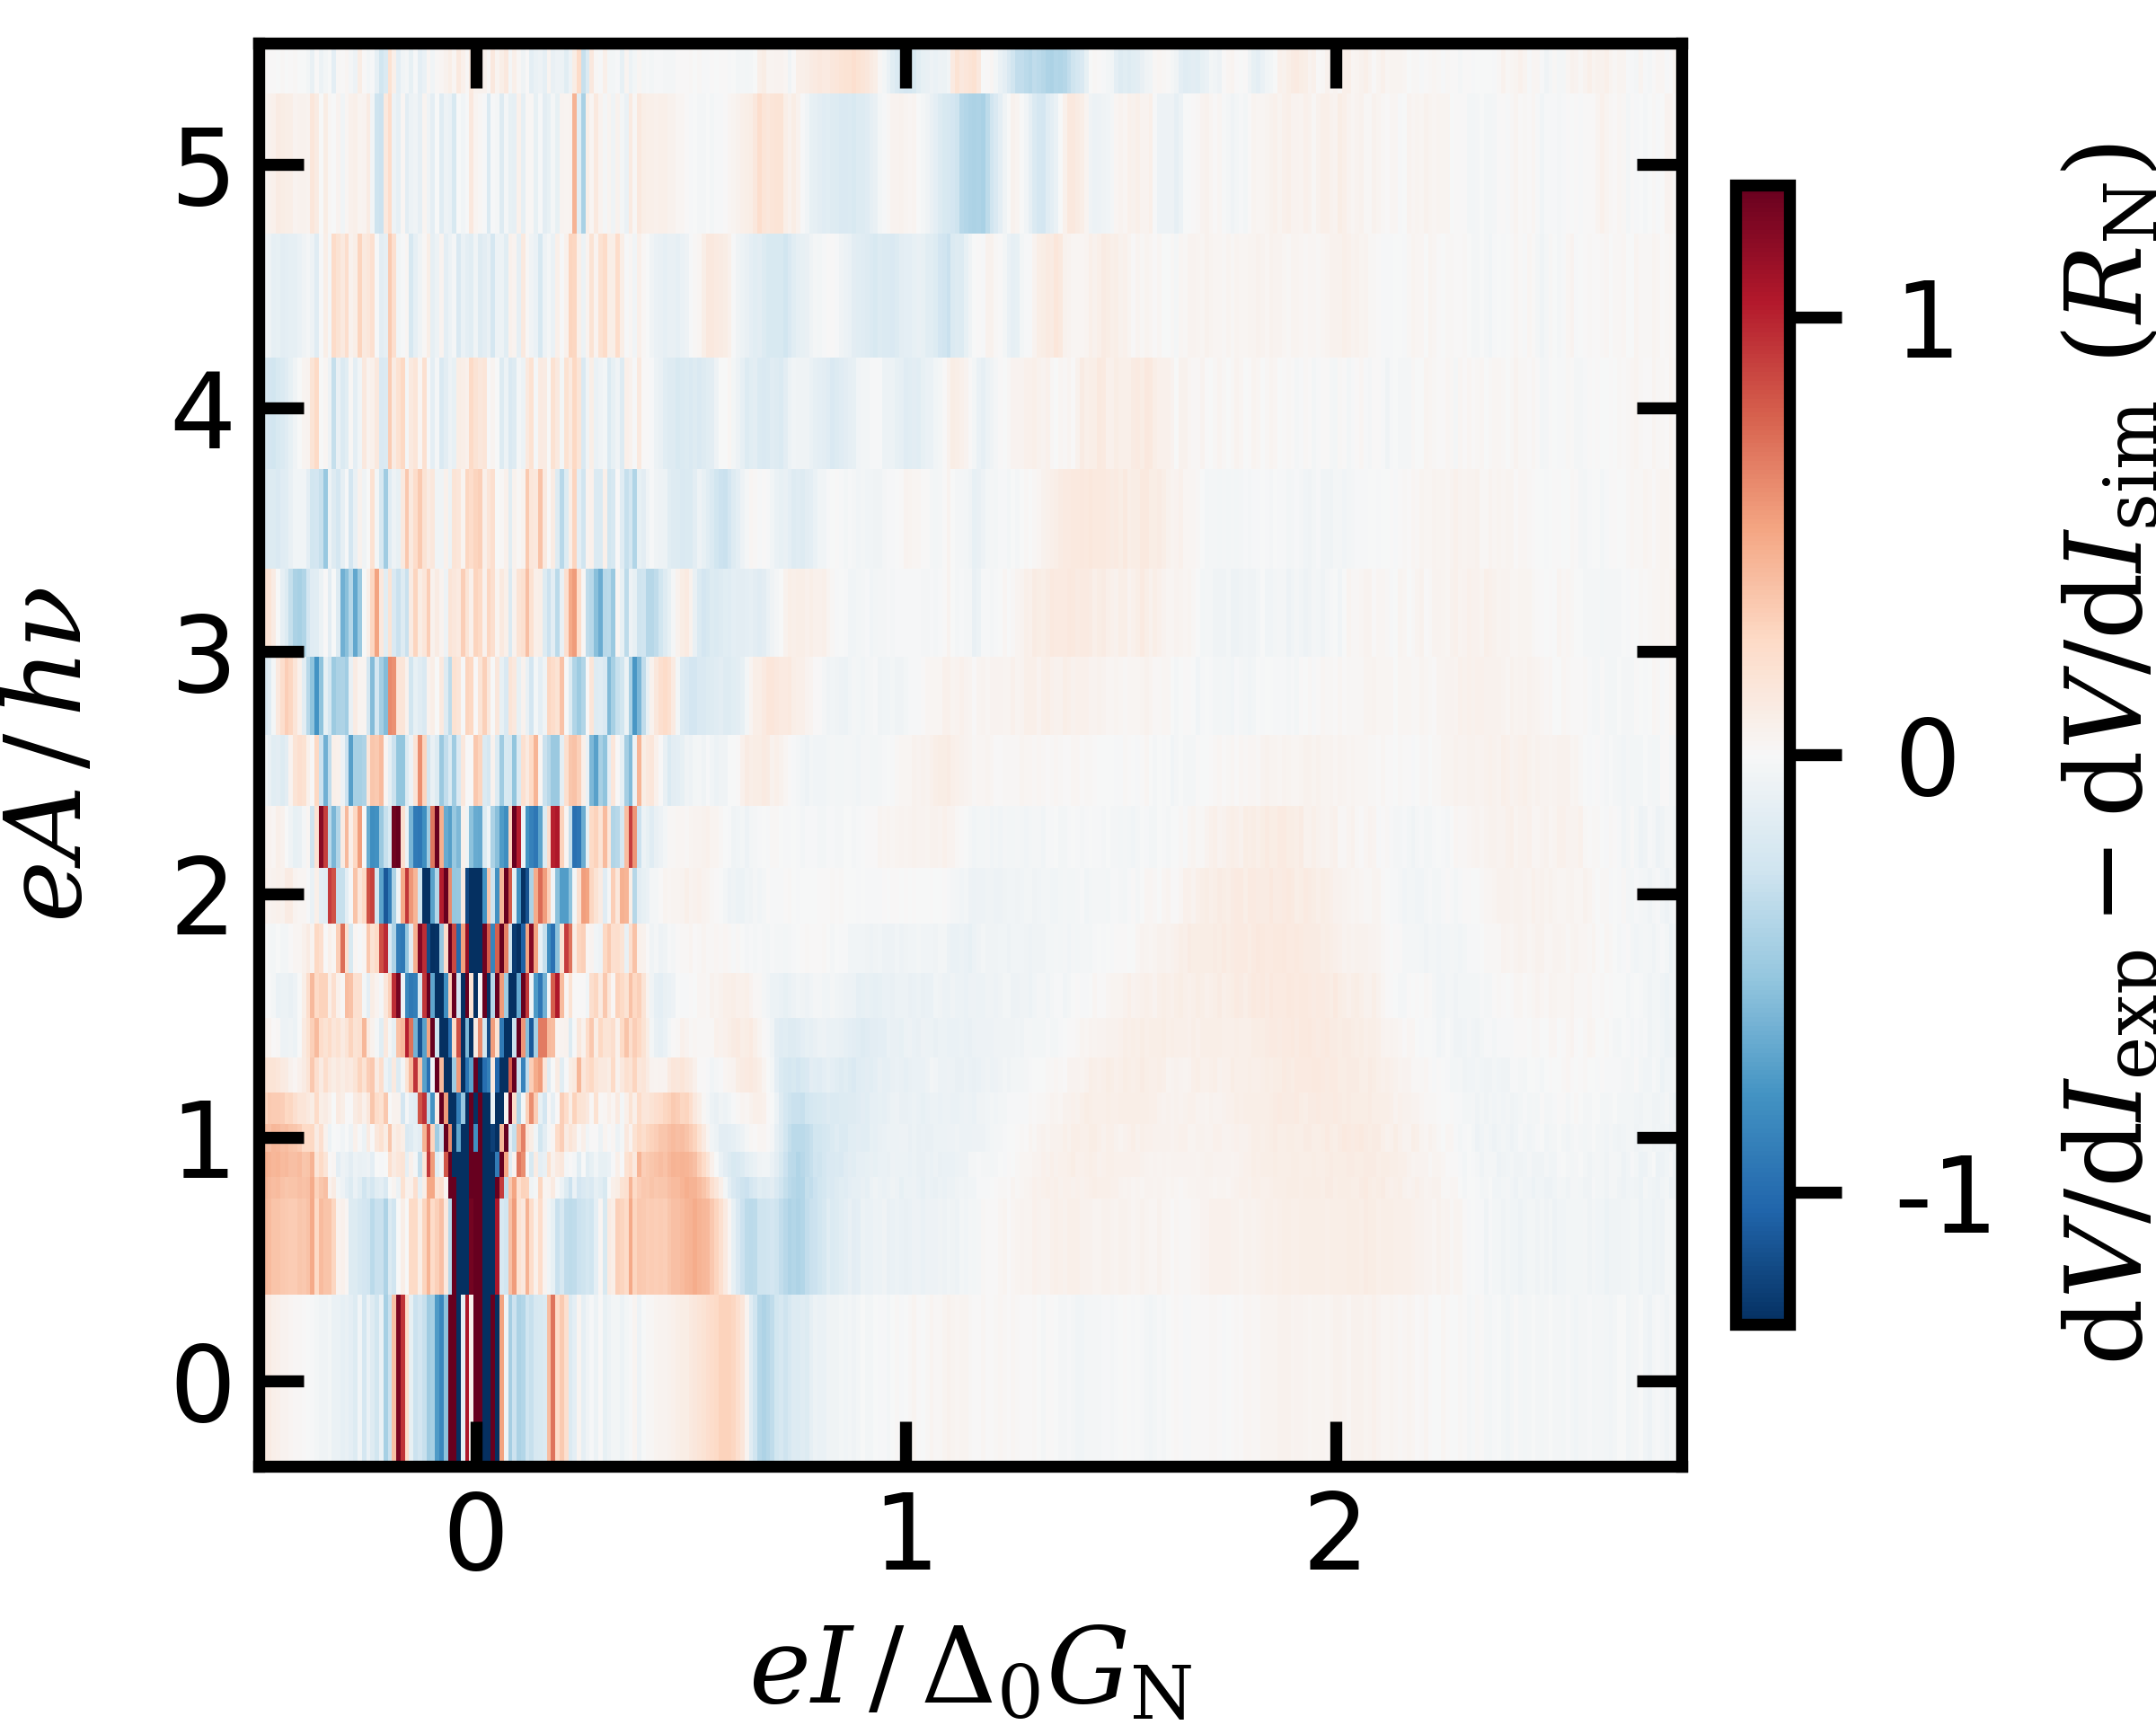

In [403]:
# scope

from superconductivity.style.thesislayout import save_figure

path = "1.8G0/15.0GHz_stripline"
base = f"atomic_contact/{path}/didv-img"
data_sim = np.load(f"{path}/sim.npz")

Vbias = data_sim["Vbias"]
Abias = data_sim["Abias"]

dGexp = data_sim["dGexp"]
dGsim = data_sim["dGsim"]
dGpamar = data_sim["dGpamar"]
dGfcspamar = data_sim["dGfcspamar"]
dRexp = data_sim["dRexp"]
dRsim = data_sim["dRsim"]

figsize = (2.0, 1.6)
padding = (0.2, 0.2, 0.4, 0.0)

# region dIdV
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=1, ncols=1)
img = axes[0].pcolormesh(
    Vbias,
    Abias,
    dGexp,
    cmap=sc.get_cmap(bad="grey", inverse=False),
    clim=(-0.3, 3.3),
    rasterized=True,
)

axes[0].set_ylim(None, 5.5),
sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$eA\\,/\\,h\\nu$",
)
right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.025, new_bottom, 0.025, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=[0, 1, 2, 3])
cbar.set_label("$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$", fontsize=7)
cbar.ax.tick_params(labelsize=7)

save_figure(fig, title=f"{base}/dGexp")
# endregion

# region dGdI exp
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=1, ncols=1)
img = axes[0].pcolormesh(
    Vbias,
    Abias,
    dRexp,
    cmap=sc.get_cmap(bad="grey", inverse=True),
    clim=(-0.3, 3.3),
    rasterized=True,
)

axes[0].set_ylim(None, 5.5),
sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eI\\,/\\,\\Delta_0 G_\\mathrm{N}$",
    ylabel="$eA\\,/\\,h\\nu$",
)
right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.025, new_bottom, 0.025, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=[0, 1, 2, 3])
cbar.set_label("$\\mathrm{d}V/\\mathrm{d}I\\ \\cdot\\,G_\\mathrm{N}$", fontsize=7)
cbar.ax.tick_params(labelsize=7)

save_figure(fig, title=f"{base}/dRexp")
# endregion

# region dIdV diff
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=1, ncols=1)
img = axes[0].pcolormesh(
    Vbias,
    Abias,
    dGexp - dGsim,
    # cmap=sc.get_cmap(bad="grey", inverse=False),
    cmap="RdBu_r",
    clim=(-1.3, 1.3),
    rasterized=True,
)

axes[0].set_ylim(None, 5.5),
sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$eA\\,/\\,h\\nu$",
)
right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.025, new_bottom, 0.025, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=(-1, 0, 1))
cbar.set_label(
    "$\\mathrm{d}I/\\mathrm{d}V _\\mathrm{exp} - \\mathrm{d}I/\\mathrm{d}V _\\mathrm{sim}\\ (G_\\mathrm{N})$",
    fontsize=7,
)
cbar.ax.tick_params(labelsize=7)

save_figure(fig, title=f"{base}/dGdiff")
# endregion

# region dIdV test pamar
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=1, ncols=1)
img = axes[0].pcolormesh(
    Vbias,
    Abias,
    dGexp - dGpamar,
    # cmap=sc.get_cmap(bad="grey", inverse=False),
    cmap="RdBu_r",
    clim=(-1.3, 1.3),
    rasterized=True,
)

axes[0].set_ylim(None, 5.5),
sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$eA\\,/\\,h\\nu$",
)
right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.025, new_bottom, 0.025, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=(-1, 0, 1))
cbar.set_label(
    "$\\Delta \\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
    fontsize=7,
)
cbar.ax.tick_params(labelsize=7)

save_figure(fig, title=f"{base}/dGtest")
# endregion

# region dIdV test pamar
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=1, ncols=1)
img = axes[0].pcolormesh(
    Vbias,
    Abias,
    dGexp - dGfcspamar,
    # cmap=sc.get_cmap(bad="grey", inverse=False),
    cmap="RdBu_r",
    clim=(-1.3, 1.3),
    rasterized=True,
)

axes[0].set_ylim(None, 5.5),
sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eV\\,/\\,\\Delta_0$",
    ylabel="$eA\\,/\\,h\\nu$",
)
right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.025, new_bottom, 0.025, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=(-1, 0, 1))
cbar.set_label(
    "$\\Delta \\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
    fontsize=7,
)
cbar.ax.tick_params(labelsize=7)

save_figure(fig, title=f"{base}/dGtest2")
# endregion

# region dVdI diff
fig, axes = sc.get_figures(figsize=figsize, padding=padding, nrows=1, ncols=1)
img = axes[0].pcolormesh(
    Vbias,
    Abias,
    dRexp - dRsim,
    # cmap=sc.get_cmap(bad="grey", inverse=False),
    cmap="RdBu_r",
    clim=(-1.3, 1.3),
    rasterized=True,
)

axes[0].set_ylim(None, 5.5),
sc.daumenkino_layout(
    fig,
    axes,
    xlabel="$eI\\,/\\,\\Delta_0 G_\\mathrm{N}$",
    ylabel="$eA\\,/\\,h\\nu$",
)
right_edge = max(ax.get_position().x1 for ax in axes)
top = max(ax.get_position().y1 for ax in axes)
bottom = min(ax.get_position().y0 for ax in axes)

height = top - bottom
shrink = 0.8
new_height = height * shrink
new_bottom = bottom + 0.5 * (height - new_height)

cax = fig.add_axes([right_edge + 0.025, new_bottom, 0.025, new_height])

cbar = fig.colorbar(img, cax=cax, ticks=(-1, 0, 1))
cbar.set_label(
    "$\\mathrm{d}V/\\mathrm{d}I _\\mathrm{exp} - \\mathrm{d}V/\\mathrm{d}I _\\mathrm{sim}\\ (R_\\mathrm{N})$",
    fontsize=7,
)
cbar.ax.tick_params(labelsize=7)

save_figure(fig, title=f"{base}/dRdiff")
# endregion

plt.show()